# Run this to enable loading from relative paths

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
  import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
  PKG = %pwd
  PKG = pathlib.Path(PKG)
  root_parent_level = 1
  root = PKG
  full_pkg = f"{root.name}"
  for _ in range(root_parent_level):
    root = root.parent
    full_pkg = f"{root.name}.{full_pkg}"
    MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
    MODULE_NAME = f"{root.name}"
    spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
  __package__ = full_pkg


# Save plots with no embeded fonts

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Common Imports

In [3]:
from .common.cache import loadCachedOrRunNSave as ld
from .common.definitions import BrainRegion
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import pathlib
import os

In [4]:
PVAL = 0.05
CONCAT_SAMPLING_MOVE = True

In [5]:
# Papermill parameters -- code/run_notebooks.py overrides these.
# Everything is off by default, so running the notebook writes nothing.
SAVE_FIGS = False           # write figures under results/
SAVE_DATA = False           # rewrite cached intermediate data under data/
PAPER_FIGURES_ONLY = False  # skip per-subject / per-session figures

In [7]:
fig_save_prefix = f"../results/2P/"
pathlib.Path(fig_save_prefix).mkdir(exist_ok=True)

# Define generic function to run our tests

In [8]:
from .twop.dimreduc import DimReduc
from .twop.statstest import StatsTest

defaultStatsTestFn = StatsTest.mannwhitneyu
defaultDimReducFn = DimReduc.max

cache_entry = f"{defaultDimReducFn('name')}_{defaultStatsTestFn('name',None)}"
if CONCAT_SAMPLING_MOVE:
  cache_entry += "_concat"
default_cache_dir = f"pkl/{cache_entry}"

print("Default Cache dir:", default_cache_dir)


Default Cache dir: pkl/max_MannWhitneyU_concat


# Run different conditions combinations

In [9]:
from .twop.dataload import loadSamplingUnnormalized

df_rt_unnormalized = loadSamplingUnnormalized(num_quantiles=3, time_before=0.1,
                                              time_after=0.1)

In [10]:
from .twop.dataload import loadSamplingNormalized

normed_sampling_df = loadSamplingNormalized(time_before=0.1, time_after=0.1)

# Run statistical tests on both real data and shuffled data

In [11]:
import pickle
class Dummy:
    pass

class MyUnpickler2(pickle._Unpickler):
    def find_class(self, module, name):
        try:
            return super().find_class(module, name)
        except ModuleNotFoundError as e:
            print(f"Didn't find Module: {module} - name: {name}")
            if module == "caiman.behavior.convert.matreader.states":
                if name == "States":
                    return Dummy
                elif name == "StartEnd":
                    return Dummy
        except AttributeError as e:
            print(f"Didn't find Module: {module} - name: {name}")
            raise e


In [12]:
from .twop.dataload import dataPath
from .twop.genrundata import (genRunDataInst, loadRunDataDict,
                                  saveRunDataDict)
from tqdm.auto import tqdm


import pickle
import pathlib

def genRandom(num_runs, df_src, fp_descrp):
    FP_PKL = str(dataPath(f"data_runs_{fp_descrp}.pkl"))
    if pathlib.Path(FP_PKL).exists():
        print("Loading old data from disk")
        run_data_dict = loadRunDataDict(FP_PKL)
        start = max(list(run_data_dict.keys())) if len(run_data_dict.keys()) \
                else -1
        start += 1
    else:
        print("Regenerting all data from scratch")
        run_data_dict = {}
        start = 0

    for run_idx in tqdm(range(start, num_runs+1)):
        if run_idx == 0:
            run_name = "Real"
            shuffle = False
        else:
            run_name = f"Rand{run_idx}"
            shuffle = True
        run_data_stats = genRunDataInst(df_src, # df_rt_movement_fixed
                                        shuffle_quantiles=shuffle,
                                        defaultDimReducFn=defaultDimReducFn,
                                        defaultStatsTestFn=defaultStatsTestFn,
                                        assign_name=run_name)
        run_data_dict[run_idx] = run_data_stats
        saveRunDataDict(run_data_dict, FP_PKL)
    return run_data_dict

In [13]:
run_data_unnormalized = genRandom(num_runs=1, df_src=df_rt_unnormalized, fp_descrp="Unnormalized")

Loading old data from disk


0it [00:00, ?it/s]

In [14]:
run_data_unnormalized[0].df_src.columns

Index(['Name', 'Date', 'SessionNum', 'TrialNumber', 'MaxTrial', 'MinSample',
       'calcStimulusTime', 'ChoiceCorrect', 'ChoiceLeft', 'EarlyWithdrawal',
       'PrevChoiceCorrect', 'PrevChoiceLeft', 'DV', 'DVstr', 'PrevDV',
       'PrevDVstr', 'Difficulty1', 'Difficulty2', 'Difficulty3', 'Difficulty4',
       'quantile_idx', 'ShortName', 'epoch', 'epoch_time', 'trace_start_idx',
       'trace_end_idx', 'traces_sets', 'sole_owner', 'acq_sampling_rate',
       'state_id', 'BrainRegion', 'Layer', 'Group'],
      dtype='object')

In [15]:
import pandas as pd
from .twop.dataload import loadFeedbackTraces

df_feedback = loadFeedbackTraces()
df_feedback["epoch"] = "Feedback"
# Bad hack
from .behavior.util.splitdata import splitStimulusTimeByQuantile
def assignQuantiles(df):
    df = df.copy()
    # Some files are saved twice due to cloud sync issues
    uniq_cols = ["Name", "Date", "SessionNum", "TrialNumber", "TrialStartSysTime"]
    # dups_idxs = df[uniq_cols].duplicated(keep=False).values
    # display(df[dups_idxs])
    df = df[~df[uniq_cols].duplicated(keep="first")]
    null_time = df.calcStimulusTime.isnull()
    df_null_time = df[null_time]
    df = df[~null_time]
    df = splitStimulusTimeByQuantile(df)
    df = pd.concat([q_df for q_idx, q_df in df] + [df_null_time])
    df = df.sort_values(by=["Name", "Date", "SessionNum", "TrialNumber", "epoch"])
    return df

df_feedback = assignQuantiles(df_feedback)
_cols = df_rt_unnormalized.columns.copy()
_cols = _cols.drop(['epochs_ranges', 'epochs_names'])
df_feedback = df_feedback[_cols]

  0%|          | 0/23 [00:00<?, ?it/s]

In [16]:
run_data_feedback = genRandom(num_runs=1, df_src=df_feedback, fp_descrp="Feedback_fixed")

Loading old data from disk


0it [00:00, ?it/s]

In [17]:
run_data_feedback[0].df_src

,Name,Date,SessionNum,TrialNumber,MaxTrial,MinSample,calcStimulusTime,ChoiceCorrect,ChoiceLeft,EarlyWithdrawal,...,trace_end_idx,traces_sets,sole_owner,acq_sampling_rate,state_id,SamplingType,BrainRegion,Layer,PrevOutcomeCount,Group
19229,GP4-23,2022-06-26,2,42,333,0.3,1.1627,1.0,1.0,0,...,83,"{'neuronal': {1: [7168.2236, 6967.162, 7056.62...",False,30.043,19,ReactionTime,15,L23,0,Real
19233,GP4-23,2022-06-26,2,43,333,0.3,0.8047,1.0,0.0,0,...,235,"{'neuronal': {1: [7168.2236, 6967.162, 7056.62...",False,30.043,19,ReactionTime,15,L23,1,Real
19237,GP4-23,2022-06-26,2,44,333,0.3,0.8356,1.0,0.0,0,...,338,"{'neuronal': {1: [7168.2236, 6967.162, 7056.62...",False,30.043,19,ReactionTime,15,L23,2,Real
19241,GP4-23,2022-06-26,2,45,333,0.3,0.7941,0.0,0.0,0,...,469,"{'neuronal': {1: [7168.2236, 6967.162, 7056.62...",False,30.043,25,ReactionTime,15,L23,3,Real
19245,GP4-23,2022-06-26,2,46,333,0.3,0.8260,1.0,0.0,0,...,632,"{'neuronal': {1: [7168.2236, 6967.162, 7056.62...",False,30.043,19,ReactionTime,15,L23,-1,Real
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9897,GP4-85,2022-07-05,1,318,327,0.3,0.6534,1.0,0.0,0,...,35082,"{'neuronal': {0: [600.8341, 548.72266, 567.048...",False,30.043,19,ReactionTime,6,L23,3,Real
9901,GP4-85,2022-07-05,1,319,327,0.3,0.8686,1.0,0.0,0,...,35178,"{'neuronal': {0: [600.8341, 548.72266, 567.048...",False,30.043,19,ReactionTime,6,L23,4,Real
9905,GP4-85,2022-07-05,1,320,327,0.3,0.9118,1.0,1.0,0,...,35287,"{'neuronal': {0: [600.8341, 548.72266, 567.048...",False,30.043,19,ReactionTime,6,L23,5,Real
9909,GP4-85,2022-07-05,1,321,327,0.3,0.7944,1.0,0.0,0,...,35343,"{'neuronal': {0: [600.8341, 548.72266, 567.048...",False,30.043,19,ReactionTime,6,L23,6,Real


# Save sgf. neurons to disk

In [18]:
from .twop.dataload import dataPath

sgf_all = run_data_unnormalized[0].shortlong_df.query(f'pval <= {PVAL} and DVstr.isnull()')
if SAVE_DATA:
    with open(dataPath("sgf_all.pkl"), "wb") as f:
        pickle.dump(sgf_all, f)
sgf_all

,trace_id,data_col,data_val_left,data_val_right,prior_data_col,prior_data_val,ShortName,dim_reduc_name,stat_test_name,left_mean,...,BrainRegion,Layer,Group,long_trace_id,left_mean_roc,right_mean_roc,left_median_roc,right_median_roc,statistic_roc,IsROCLeftTuend
4338,1,ChoiceLeft,True,False,None,NaN,GP4_23_S1_L50_D250_mm2,max,MannWhitneyU,5.636729,...,15,L23,Real,GP4_23_S1_L50_D250_mm2_1,3.059228,1.742934,1.838211,0.537988,0.676847,True
4339,2,ChoiceLeft,True,False,None,NaN,GP4_23_S1_L50_D250_mm2,max,MannWhitneyU,2.853587,...,15,L23,Real,GP4_23_S1_L50_D250_mm2_2,1.441019,2.438052,0.376516,1.152115,0.408320,False
4341,4,ChoiceLeft,True,False,None,NaN,GP4_23_S1_L50_D250_mm2,max,MannWhitneyU,1.160029,...,15,L23,Real,GP4_23_S1_L50_D250_mm2_4,0.538118,0.388174,0.309725,0.244734,0.582430,True
4344,12,ChoiceLeft,True,False,None,NaN,GP4_23_S1_L50_D250_mm2,max,MannWhitneyU,1.837721,...,15,L23,Real,GP4_23_S1_L50_D250_mm2_12,0.852148,1.047164,0.401155,0.533479,0.397263,False
4349,17,ChoiceLeft,True,False,None,NaN,GP4_23_S1_L50_D250_mm2,max,MannWhitneyU,1.513813,...,15,L23,Real,GP4_23_S1_L50_D250_mm2_17,0.739895,1.189286,0.355784,0.757591,0.402189,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14449,46,PrevChoiceCorrect,True,False,None,NaN,GP4_85_s10_L70_D250_ALM,max,MannWhitneyU,1.082674,...,6,L23,Real,GP4_85_s10_L70_D250_ALM_46,0.462193,0.208853,0.216210,0.134313,0.659091,True
14451,53,PrevChoiceCorrect,True,False,None,NaN,GP4_85_s10_L70_D250_ALM,max,MannWhitneyU,1.065751,...,6,L23,Real,GP4_85_s10_L70_D250_ALM_53,0.401103,0.652263,0.339345,0.434918,0.282529,False
14453,58,PrevChoiceCorrect,True,False,None,NaN,GP4_85_s10_L70_D250_ALM,max,MannWhitneyU,1.141320,...,6,L23,Real,GP4_85_s10_L70_D250_ALM_58,0.432175,0.317065,0.298357,0.263263,0.568397,True
14455,62,PrevChoiceCorrect,True,False,None,NaN,GP4_85_s10_L70_D250_ALM,max,MannWhitneyU,0.761462,...,6,L23,Real,GP4_85_s10_L70_D250_ALM_62,0.313703,0.200107,0.196079,0.119358,0.653813,True


# Sgf. Neurons Pie Charts

For: ChoiceLeft None
	LFC: 33.00% ±3.68%
	MFC: 18.06% ±3.04%
Sgf. neurons for Cur. Direction (ChoiceLeft) - % of all neurons
    MFC: 18.06% +/- 3.04% SEM  (13 sessions, 182/837 neurons)
    LFC: 33.00% +/- 3.68% SEM  (10 sessions, 199/609 neurons)
    Normality (Shapiro-Wilk): MFC p=0.905, LFC p=0.253 -> normal, t-test usable
    MFC vs LFC: t-test (Student) stat=-3.15, p=0.00478 (MannWhitneyU p=0.0143 for reference)


C:\Users\float\AppData\Local\Temp\ipykernel_21620\3523345188.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,
C:\Users\float\AppData\Local\Temp\ipykernel_21620\3523345188.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,


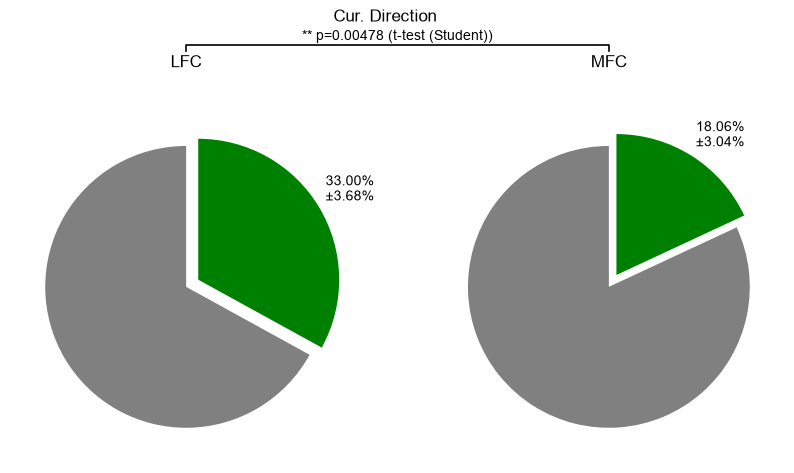

For: IsEasy ChoiceLeft
	LFC: 10.39% ±2.30%
	MFC: 7.44% ±1.35%
For: IsEasy None
	LFC: 7.60% ±1.75%
	MFC: 5.82% ±1.00%
For: PrevChoiceCorrect None
	LFC: 49.68% ±4.12%
	MFC: 55.08% ±3.66%


C:\Users\float\AppData\Local\Temp\ipykernel_21620\3523345188.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,
C:\Users\float\AppData\Local\Temp\ipykernel_21620\3523345188.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,
C:\Users\float\AppData\Local\Temp\ipykernel_21620\35233451

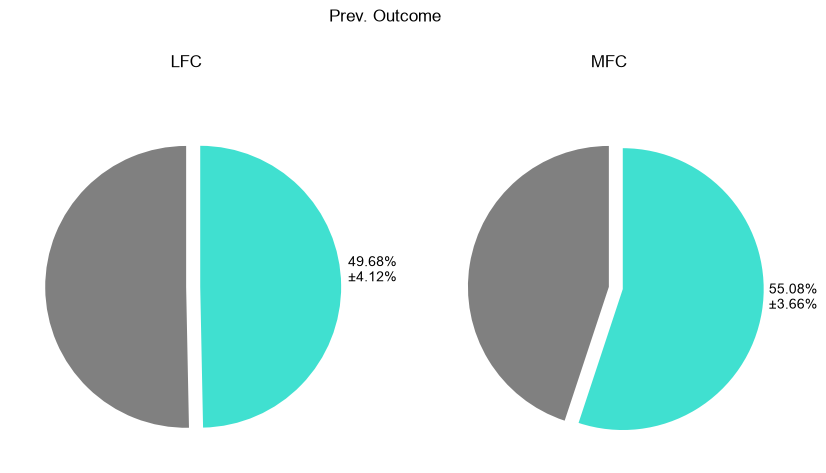

For: PrevChoiceLeft None
	LFC: 74.00% ±3.34%
	MFC: 73.27% ±2.63%


C:\Users\float\AppData\Local\Temp\ipykernel_21620\3523345188.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,
C:\Users\float\AppData\Local\Temp\ipykernel_21620\3523345188.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,


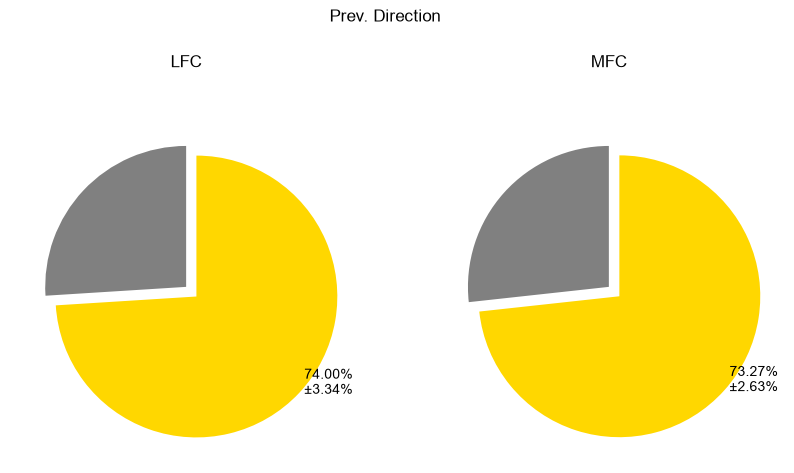

For: PrevIsEasy None
	LFC: 16.57% ±3.43%
	MFC: 12.27% ±2.51%


C:\Users\float\AppData\Local\Temp\ipykernel_21620\3523345188.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,
C:\Users\float\AppData\Local\Temp\ipykernel_21620\3523345188.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Union

from .twop import sgfneurons as sgn

def loopPlotPieChart(df, save_prefix=None, save_figs=False,
                     title_prefix="", show_selectivity=False,
                     filter_df=None):
    if show_selectivity:
        title_prefix = f"{title_prefix}split_"
    if filter_df is not None:
        title_prefix = f"{title_prefix}filtered_"
    df = df[df.DVstr.isnull()]
    assert "quantile_idx" not in df.columns

    for (data_col, prior_data_col), grp_df in df.groupby(["data_col",
                                                          "prior_data_col"],
                                                          dropna=False):
        if not isinstance(prior_data_col, str):
            assert np.isnan(prior_data_col)
            prior_data_col = None
        if prior_data_col is not None or data_col in ["IsEasy", "PrevIsEasy"]:
            plot = False
        else:
            plot = True
            fig, axs = plt.subplots(1, 2, figsize=(10, 5))
            axs = iter(axs)
            color = "g" if data_col == "ChoiceLeft" else (
                    "gold" if data_col == "PrevChoiceLeft" else
                    "turquoise" if data_col == "PrevChoiceCorrect" else
                    "purple" if data_col == "ChoiceCorrect" else
                    "orange")
        print("For:", data_col, prior_data_col)
        data_col_str = "Cur. Direction" if data_col == "ChoiceLeft" else \
                       "Prev. Direction" if data_col == "PrevChoiceLeft" else \
                       "Prev. Outcome" if data_col == "PrevChoiceCorrect" else \
                       "Cur. Outcome" if data_col == "ChoiceCorrect" else \
                       data_col

        def calcSessSGFMean(sess_df, check_ROC_left : Union[None, True, False]=None):
            if filter_df is not None:
                assert sess_df.ShortName.nunique() == 1, \
                    f"Expected only one session in sess_df, got {sess_df.ShortName.nunique()}"
                short_name = sess_df.ShortName.iloc[0]
                filter_sess_df = filter_df[filter_df.ShortName == short_name]
                len_before = len(sess_df)
                sess_df = sess_df[sess_df.trace_id.isin(filter_sess_df.trace_id)]
                assert len(sess_df) > 0, \
                    f"After filtering, sess_df is empty for {short_name} with {filter_df.columns = }"
                len_after = len(sess_df)
                # print(f"{short_name} - {len_before} -> {len_after} neurons after filtering")
            nerons_count = len(sess_df)
            sgf_idx = sess_df.pval <= PVAL
            if check_ROC_left is not None:
                sgf_idx &= sess_df.IsROCLeftTuend == check_ROC_left
            sgf_count = sgf_idx.sum()
            return 100 * sgf_count / nerons_count

        def getGroupMeanSEM(sub_df, check_ROC_left : Union[None, True, False]=None):
            mean_sess_sgf = sub_df.groupby("ShortName").apply(calcSessSGFMean,
                                                             check_ROC_left=check_ROC_left)
            sgf_mean, sgf_sem = mean_sess_sgf.mean(), mean_sess_sgf.sem()
            print(f"\t{br_str}: {sgf_mean:.2f}% ±{sgf_sem:.2f}%")
            return sgf_mean, sgf_sem

        for br, br_df in grp_df.groupby("BrainRegion"):
            br_str = str(BrainRegion(br)).split("_")[0]
            br_str = "MFC" if br_str == "M2" else "LFC"
            if show_selectivity:
                sgf_mean_left, sgf_sem_left = getGroupMeanSEM(br_df, check_ROC_left=True)
                sgf_mean_right, sgf_sem_right = getGroupMeanSEM(br_df, check_ROC_left=False)
                pie_x = [100-sgf_mean_left-sgf_mean_right, sgf_mean_left, sgf_mean_right]
                pie_labels = ["", f"{sgf_mean_left:.2f}%\n±{sgf_sem_left:.2f}%",
                              f"{sgf_mean_right:.2f}%\n±{sgf_sem_right:.2f}%"]
                explode = [0, 0.1, 0.1]
                clrs = ["gray", color, color]
                hatches = [None, None, "x"]
            else:
                sgf_mean, sgf_sem = getGroupMeanSEM(br_df)
                pie_x = [100-sgf_mean, sgf_mean]
                pie_labels = ["", f"{sgf_mean:.2f}%\n±{sgf_sem:.2f}%"]
                explode = [0, 0.1]
                clrs = ["gray", color]
                hatches = None
            if plot:
                ax = next(axs)
                wedges, texts = ax.pie(pie_x,
                                       labels=pie_labels,
                                       startangle=90,
                                       explode=explode,
                                       labeldistance=1.05,
                                       textprops={"va": "bottom", "ha": "left"},
                                       colors=clrs,
                                       hatch=hatches)
                if not show_selectivity:
                    ax.set_title(f"{br_str}", y=1.1)
                if show_selectivity:
                    ax.set_title(f"{br_str} - (x hatch: anti-selective for {data_col})",
                                 y=1.1)
                    # Put the exploded wedges together as one piece, not two
                    # separate exploded pieces
                    # https://stackoverflow.com/a/70578760/11996983
                    groups = [[0], [1, 2]]
                    radfraction = 0.1
                    for group in groups:
                        if len(group) == 1:
                            wedges[0].set_visible(False)
                            print(ax.get_xlim(), ax.get_ylim())
                            ax.set_xlim(0, 1.25)
                            ax.set_ylim(0, 1.25)
                            continue
                        ang = np.deg2rad((wedges[group[-1]].theta2 + wedges[group[0]].theta1) / 2)
                        for j in group:
                            center = radfraction * wedges[j].r * np.array([np.cos(ang), np.sin(ang)])
                            wedges[j].set_center(center)
                            texts[j].set_position(np.array(texts[j].get_position()) + center)

        if plot:
            prior_data_col_str = "" if prior_data_col is None else f" - {prior_data_col}"
            title = title_prefix.replace("_"," ")  + f"{data_col_str}{prior_data_col_str}"
            if filter_df is not None:
                title += " - Filtered on active neurons"
            fig.suptitle(title, y=1.05)
            # Significance bracket between the two pies' MFC / LFC titles, with
            # the stars, the p-value and the test that produced it. Only for the
            # Cur. Direction figure -- that single planned MFC-vs-LFC comparison
            # is the one sgn.regionComparison runs (see twop/sgfneurons.py) --
            # and only for the plain, unfiltered pies, whose percentages are
            # exactly the ones it tests. Drawn after the suptitle, which it
            # nudges up if the label would reach it.
            if (not show_selectivity and filter_df is None
                    and data_col == sgn.CHOICE_DATA_COL):
                sgf_comparison = sgn.regionComparison(df, pval=PVAL,
                                                      data_col=data_col)
                print(sgn.formatComparison(sgf_comparison))
                sgn.drawRegionSigBracket(fig, fig.axes, sgf_comparison)
            if save_figs:
                fig.savefig(f"{save_prefix}/sgf_tests/{title_prefix}{title}.svg",
                            bbox_inches='tight')
            plt.show()

loopPlotPieChart(run_data_unnormalized[0].shortlong_df, show_selectivity=False,
                 save_prefix=fig_save_prefix, save_figs=SAVE_FIGS)


In [20]:
from .twop import sgfneurons as sgn

# MFC vs LFC on the very percentages the pie charts above show (per-session
# % of sgf. neurons, mean +/- SEM over sessions -- sgn.perSessionSgfPrcnt
# mirrors loopPlotPieChart's calcSessSGFMean). The pie charts plot those means
# but run no test between the regions; this adds it.
# Normality is checked FIRST (Shapiro-Wilk per region, since the regions are
# independent samples of different sessions): both normal -> two-sample t-test,
# with Levene picking Student vs Welch, otherwise Mann-Whitney U. Both p-values
# stay in the table (ttest_pval / mwu_pval) next to the one the gate selected.
sgf_region_df = sgn.regionComparison(run_data_unnormalized[0].shortlong_df,
                                     pval=PVAL)
print(sgn.formatComparison(sgf_region_df))
display(sgf_region_df.round(4))

Sgf. neurons for Cur. Direction (ChoiceLeft) - % of all neurons
    MFC: 18.06% +/- 3.04% SEM  (13 sessions, 182/837 neurons)
    LFC: 33.00% +/- 3.68% SEM  (10 sessions, 199/609 neurons)
    Normality (Shapiro-Wilk): MFC p=0.905, LFC p=0.253 -> normal, t-test usable
    MFC vs LFC: t-test (Student) stat=-3.15, p=0.00478 (MannWhitneyU p=0.0143 for reference)


,data_col,label,MFC_n_sessions,MFC_mean,MFC_sem,MFC_n,MFC_total,LFC_n_sessions,LFC_mean,LFC_sem,...,MFC_shapiro_pval,LFC_shapiro_W,LFC_shapiro_pval,is_normal,levene_pval,test,statistic,pval,ttest_pval,mwu_pval
0,ChoiceLeft,Cur. Direction,13,18.0628,3.0415,182,837,10,33.0029,3.6807,...,0.9055,0.9058,0.2534,True,0.8571,t-test (Student),-3.1545,0.0048,0.0048,0.0143


# Sgf. between Prev. Correct vs Incorrect

In [21]:
from .twop.prevoutcomemod import loopSgfPrevOutcome

# NOT SEEDED: rng defaults to numpy's global stream, so the permutation
# p-values below move a little between runs. It should be seeded (pass
# rng=np.random.default_rng(0)); doing so shifts the published numbers, so
# that is a decision. See docs/repo-audit.md.
sgf_prev_outcome_diffs = loopSgfPrevOutcome(run_data_unnormalized[0].shortlong_df,
                                            trials_df=run_data_unnormalized[0].df_src,
                                            shuffle_iterations=1_000, pval=PVAL)

For: ChoiceLeft None


LFC:   0%|          | 0/10 [00:00<?, ?it/s]

LFC - GP4_23_s6_L50_D250_ALM:   0%|          | 0/14 [00:00<?, ?it/s]

LFC - GP4_23_s7_L50_D250_ALM:   0%|          | 0/39 [00:00<?, ?it/s]

LFC - GP4_23_s8_L50_D250_ALM:   0%|          | 0/44 [00:00<?, ?it/s]

...

MFC - GP4_80_S2_L51_D250_M2m:   0%|          | 0/32 [00:00<?, ?it/s]

MFC - GP4_80_S4_L50_D250_M2m:   0%|          | 0/30 [00:00<?, ?it/s]

MFC - GP4_85_S1_L70_D250_mm2:   0%|          | 0/37 [00:00<?, ?it/s]

MFC - GP4_85_s2_L100_D250_mm2:   0%|          | 0/43 [00:00<?, ?it/s]

MFC - GP4_85_s3_L70_D250_mm2:   0%|          | 0/56 [00:00<?, ?it/s]

	Cur. Direction - MFC & LFC: 13.20% ±2.63%


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\prevoutcomemod.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sgf_neurons_prcnt = df.groupby("ShortName").apply(modulatedPercentage,


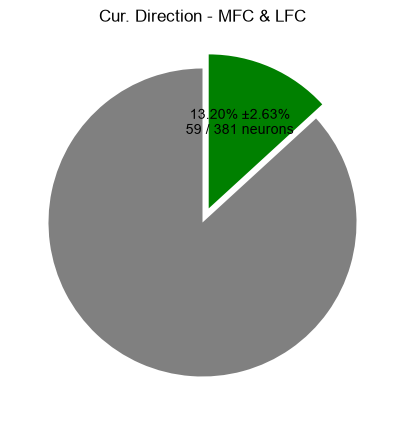

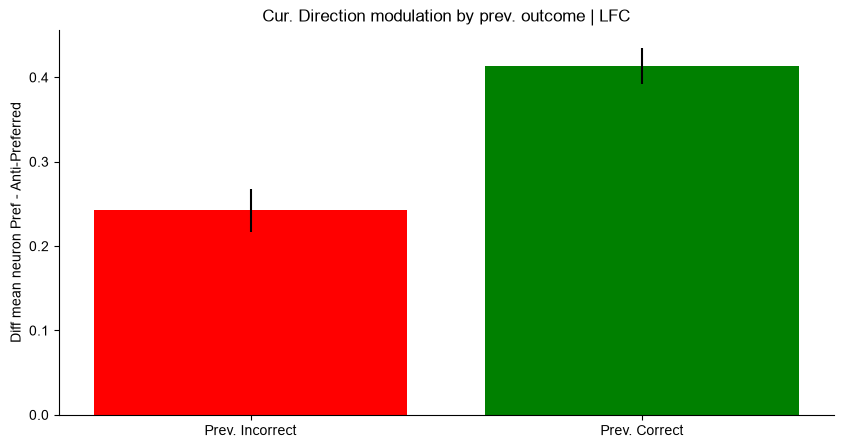

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\prevoutcomemod.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sgf_neurons_prcnt = df.groupby("ShortName").apply(modulatedPercentage,


	Cur. Direction - LFC: 10.44% ±2.99%


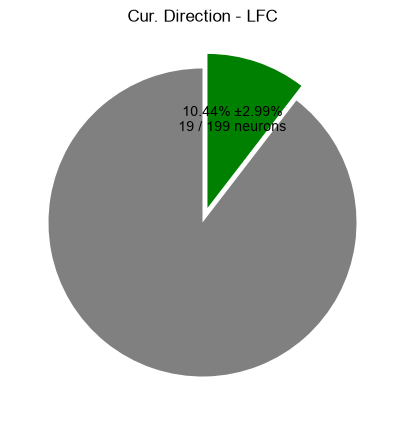

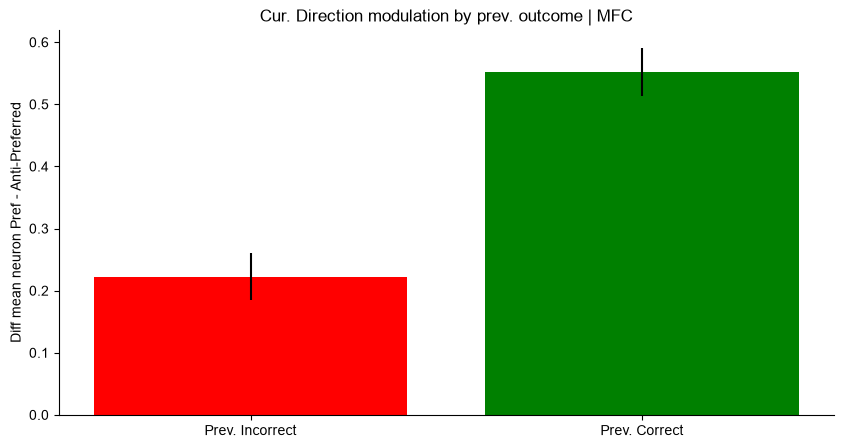

	Cur. Direction - MFC: 15.50% ±4.12%


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\prevoutcomemod.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sgf_neurons_prcnt = df.groupby("ShortName").apply(modulatedPercentage,


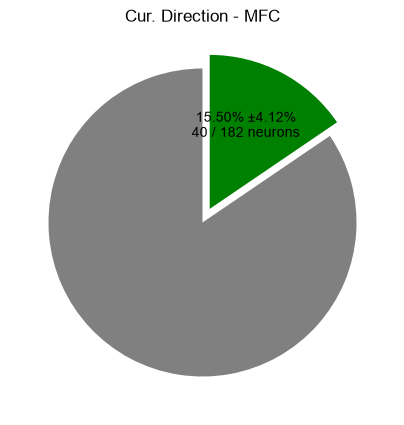

	Prev. Direction - MFC & LFC: 59.64% ±3.26%


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\prevoutcomemod.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sgf_neurons_prcnt = df.groupby("ShortName").apply(modulatedPercentage,


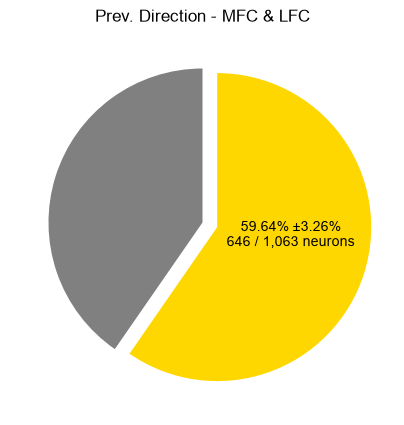

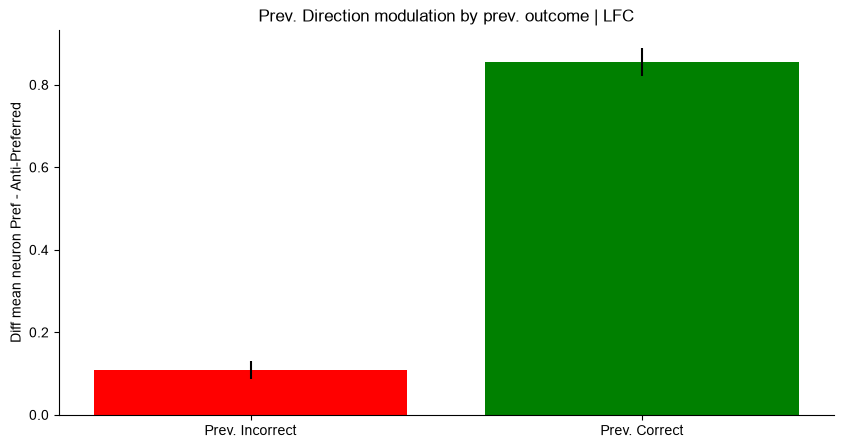

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\prevoutcomemod.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sgf_neurons_prcnt = df.groupby("ShortName").apply(modulatedPercentage,


	Prev. Direction - LFC: 55.47% ±5.77%


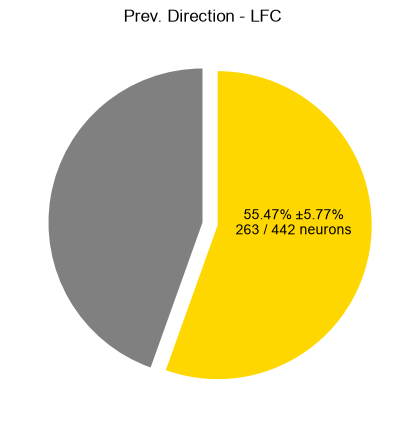

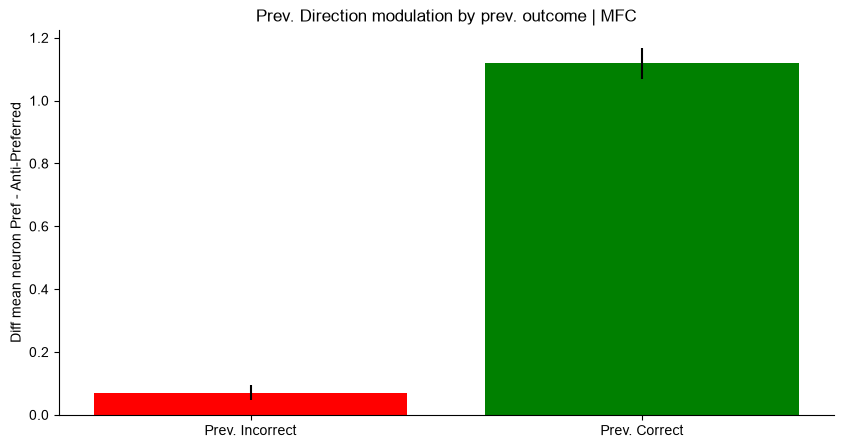

	Prev. Direction - MFC: 62.85% ±3.63%


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\prevoutcomemod.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sgf_neurons_prcnt = df.groupby("ShortName").apply(modulatedPercentage,


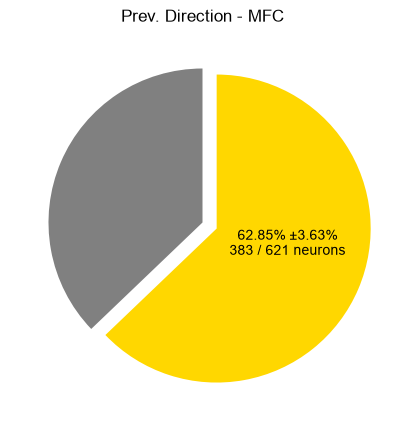

In [22]:
from .twop.prevoutcomemod import plotDiff

plotDiff(sgf_prev_outcome_diffs, pval=PVAL, save_prefix=fig_save_prefix,
         save_figs=SAVE_FIGS)

# Sequence Extracation

In [23]:
BINS_COUNT = 7

#### Assign quantiles if we don't have quantiles

In [24]:
from .behavior.util.splitdata import splitStimulusTimeByQuantile
import pandas as pd

def assignOriginalQuantile(df):
    df_li = []
    assert df.index.nunique() == len(df)
    display(df.head(10)[["Name", "SessionNum", "TrialNumber", "ChoiceLeft"]])
    for quantile_idx, quantile_df in splitStimulusTimeByQuantile(df):
        quantile_df = quantile_df.copy()
        quantile_df["quantile_idx"] = quantile_idx
        df_li.append(quantile_df)
    df = pd.concat(df_li)
    df = df.sort_index()
    display(df.head(10)[["Name", "SessionNum","TrialNumber", "ChoiceLeft", "quantile_idx"]])
    return df

In [25]:

normed_sampling_df = assignOriginalQuantile(normed_sampling_df)

,Name,SessionNum,TrialNumber,ChoiceLeft
0,GP4-23,2,42,1.0
1,GP4-23,2,43,0.0
2,GP4-23,2,44,0.0
3,GP4-23,2,45,0.0
4,GP4-23,2,46,0.0
5,GP4-23,2,47,1.0
6,GP4-23,2,48,1.0
7,GP4-23,2,49,1.0
8,GP4-23,2,50,0.0
9,GP4-23,2,51,0.0


  0%|          | 0/23 [00:00<?, ?it/s]

,Name,SessionNum,TrialNumber,ChoiceLeft,quantile_idx
0,GP4-23,2,42,1.0,3
1,GP4-23,2,43,0.0,2
2,GP4-23,2,44,0.0,2
3,GP4-23,2,45,0.0,1
4,GP4-23,2,46,0.0,2
5,GP4-23,2,47,1.0,3
6,GP4-23,2,48,1.0,2
7,GP4-23,2,49,1.0,1
8,GP4-23,2,50,0.0,2
9,GP4-23,2,51,0.0,1


In [26]:
# Same function as TwoPLoad's, now shared and tested in twop/shorth.py.
from .twop.shorth import shorth

In [27]:
# The ten functions that used to live here are shared with TwoPLoad and tested
# in twop/tracereliability.py.
from .twop.dataload import dataPath, loadMaxFiring
from .twop.tracereliability import (DecideNeurons, StdDistCollector,
                                    loopSessionsExampleNeurons)
import numpy as np
import pickle

# The four dicts below take ~20 minutes to build, so they are cached under
# data/2p/. Set this False to rebuild them (and re-save them below). The cached
# copies predate twop/tracereliability.py, so they carry neither ChoiceCorrect
# nor std_threshold; a rebuild adds both, which nothing downstream minds.
LOAD_FROM_PICKLE = True
if LOAD_FROM_PICKLE:
    print("Loading from pickle...")
    first_q_res_dict = loadMaxFiring("fast")
    second_q_res_dict = loadMaxFiring("typical")
    thrd_q_res_dict = loadMaxFiring("slow")
    all_res_normed_dict = loadMaxFiring("all")
else:
    np.seterr(all='raise')
    _decide_neurons = DecideNeurons(smooth_sigma=1)

    def _collect(df_query=""):
        collector = StdDistCollector(_decide_neurons)
        loopSessionsExampleNeurons(normed_sampling_df, random_fraction=1, seed=1,
                                   pdf_str="max_firing", df_query=df_query,
                                   processFn=collector.track, save_figs=False)
        return collector.res_dict

    all_res_normed_dict = _collect()
    first_q_res_dict = _collect("quantile_idx == 1")
    second_q_res_dict = _collect("quantile_idx == 2")
    thrd_q_res_dict = _collect("quantile_idx == 3")

    if SAVE_DATA:
        for _dict, save_fp in [(first_q_res_dict, dataPath("q1_res_dict.pkl")),
                               (second_q_res_dict, dataPath("q2_res_dict.pkl")),
                               (thrd_q_res_dict, dataPath("q3_res_dict.pkl")),
                               (all_res_normed_dict, dataPath("qall_res_dict.pkl"))]:
            with open(save_fp, 'wb') as f:
                pickle.dump(_dict, f)

Loading from pickle...


In [28]:
max_firing_all_df  = pd.DataFrame(all_res_normed_dict)
max_firing_q1_df  = pd.DataFrame(first_q_res_dict)
max_firing_q2_df  = pd.DataFrame(second_q_res_dict)
max_firing_q3_df  = pd.DataFrame(thrd_q_res_dict)

In [29]:
import pandas as pd
# Needed here and elsewhere. Both were moved verbatim into python files so that
# they can be reused (and unit-tested) outside of this notebook:
# maxFiringHist -> twop/movementneurons.py, extractIQR -> twop/seqdeviation.py
from .twop.movementneurons import maxFiringHist
from .twop.seqdeviation import extractIQR

## Plot neurons traces in fast vs slow trials

In [30]:
# One panel of this loop is published (Figure 4F), but the example's ID is
# not recorded -- so a paper-only run skips the loop rather than
# writing every neuron. Pin the ID to bring the panel back.
def _plotNeuronTraces(neuron_active_trials_row, acq_rate,
                      epochs_ranges, epochs_names, dscrp, ax):

    ax.set_xticks([rng[0] for rng in epochs_ranges[1:]])
    for rng in epochs_ranges[1:]:
        ax.axvline(rng[0], color='gray', linestyle='--', alpha=0.5)

    ax.set_xticklabels([name for name in epochs_names[1:]])
    for trace in neuron_active_trials_row.invalid_whole_trace:
        ax.plot(trace, c="gray", alpha=0.3, lw=0.5)
    for trace in neuron_active_trials_row.whole_trace:
        ax.plot(trace, c="g")
    ax.set_xlabel("Normalized Time (s)")
    len_active = len(neuron_active_trials_row.whole_trace)
    len_invalid = len(neuron_active_trials_row.invalid_whole_trace)
    prcnt_active = len_active/(len_active + len_invalid)*100
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_title(f"{dscrp} - {prcnt_active:.2g}% Active")
    return ax.get_ylim()

def _plotBRFastSlowNeurons(br_fast_df, br_slow_df, br_str, inf_df,
                           save_figs):
    # display(br_fast_df)
    count = 0
    for _, fast_row in br_fast_df.iterrows():
        trace_id = fast_row.trace_id
        slow_row = br_slow_df[br_slow_df.trace_id == trace_id]
        assert len(slow_row) == 1
        inf_sess_df = inf_df[inf_df.ShortName == fast_row.ShortName]
        acq_rate = inf_sess_df.acq_sampling_rate
        epochs_ranges = inf_sess_df.epochs_ranges.apply(tuple)
        epochs_names = inf_sess_df.epochs_names.apply(tuple)
        assert acq_rate.nunique() == 1
        assert epochs_ranges.nunique() == 1
        assert epochs_names.nunique() == 1
        acq_rate = acq_rate.iloc[0]
        slow_row = slow_row.iloc[0]
        count += 1
        if  not save_figs and count > 3:
            break
        fig, axs = plt.subplots(1, 2, figsize=(15, 5))
        y_lim1 = _plotNeuronTraces(fast_row, dscrp="Fast Trials", ax=axs[0],
                                   acq_rate=acq_rate,
                                   epochs_ranges=epochs_ranges.iloc[0],
                                   epochs_names=epochs_names.iloc[0],)
        y_lim2 = _plotNeuronTraces(slow_row, dscrp="Slow Trials", ax=axs[1],
                                   acq_rate=acq_rate,
                                   epochs_ranges=epochs_ranges.iloc[0],
                                   epochs_names=epochs_names.iloc[0])
        y_lim = (min(y_lim1[0], y_lim2[0]), max(y_lim1[1], y_lim2[1]))
        axs[0].set_ylim(y_lim)
        axs[1].set_ylim(y_lim)
        fig.suptitle(f"{br_str} - {trace_id}")
        if save_figs:
            save_fp = pathlib.Path(f"{fig_save_prefix}/FastSlowTraces/{br_str}",
                                   f"{trace_id}.svg")
            save_fp.parent.parent.mkdir(exist_ok=True)
            save_fp.parent.mkdir(exist_ok=True)
            fig.savefig(save_fp, bbox_inches='tight')
            plt.close()
        else:
            plt.show()


def loopFastSlowNeurons(fast_df, slow_df, inf_df, save_figs):
    for br, fast_df_br in fast_df.groupby("BrainRegion"):
        br_str = str(BrainRegion(br)).split("_")[0]
        br_str = br_str.replace("M2", "MFC").replace("ALM", "LFC")
        slow_df_br = slow_df[slow_df.BrainRegion == br]
        _plotBRFastSlowNeurons(fast_df_br, slow_df_br, br_str, inf_df=inf_df,
                               save_figs=save_figs)


loopFastSlowNeurons(max_firing_q1_df, max_firing_q3_df, inf_df=normed_sampling_df,
                    save_figs=(SAVE_FIGS and not PAPER_FIGURES_ONLY))

## Overlap between Active Impulsive neurons and Dliberate neuronce

ALM @10% - Overlap Total=79.06±3.40% - Fast-Slow=2.58±1.09% - Slow-Fast=15.98±2.45%
Saving to: ..\results\2P\FastSlowVenn\valid_10%_ALM.svg


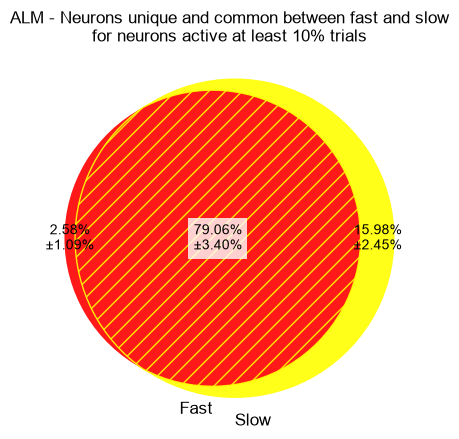

M2 @10% - Overlap Total=77.82±1.96% - Fast-Slow=3.31±0.88% - Slow-Fast=16.09±1.68%
Saving to: ..\results\2P\FastSlowVenn\valid_10%_M2.svg


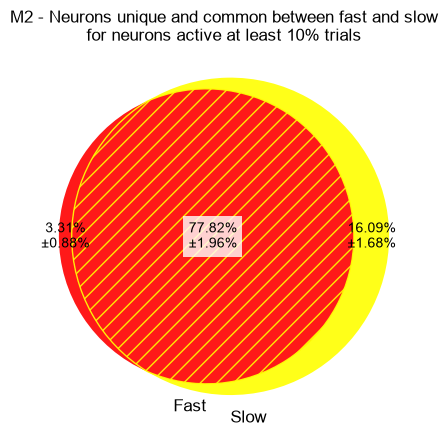

In [31]:
from .twop.fastslowvenn import loopBRPlotVennOverlap

venn_overlaps = loopBRPlotVennOverlap(max_firing_all_df, max_firing_q1_df, max_firing_q3_df,
                                      min_prcnt_valid=10, save_figs=SAVE_FIGS,
                                      fig_save_prefix=fig_save_prefix)

## You can skip the rest of this section if you just wanted to run the code in preferred-vs-anti-preferred

### Active trials helper functions

In [32]:
# Moved into twop/movementneurons.py (and unit-tested there). Kept as a thin
# wrapper so that the PVAL global stays this notebook's single p-value knob.
from .twop.movementneurons import getSgfNeurons as _getSgfNeurons

def getSgfNeurons(stats_df, data_col="ChoiceLeft", prior_data_col=np.nan):
    return _getSgfNeurons(stats_df, pval=PVAL, data_col=data_col,
                          prior_data_col=prior_data_col)

### CDF for active trials per quantiles

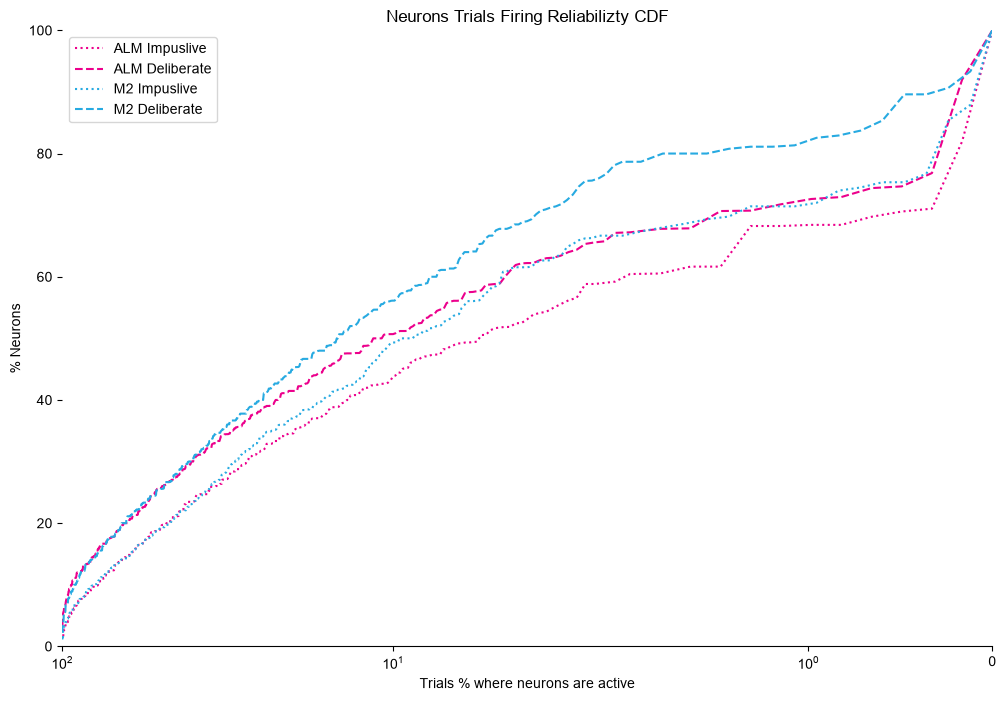

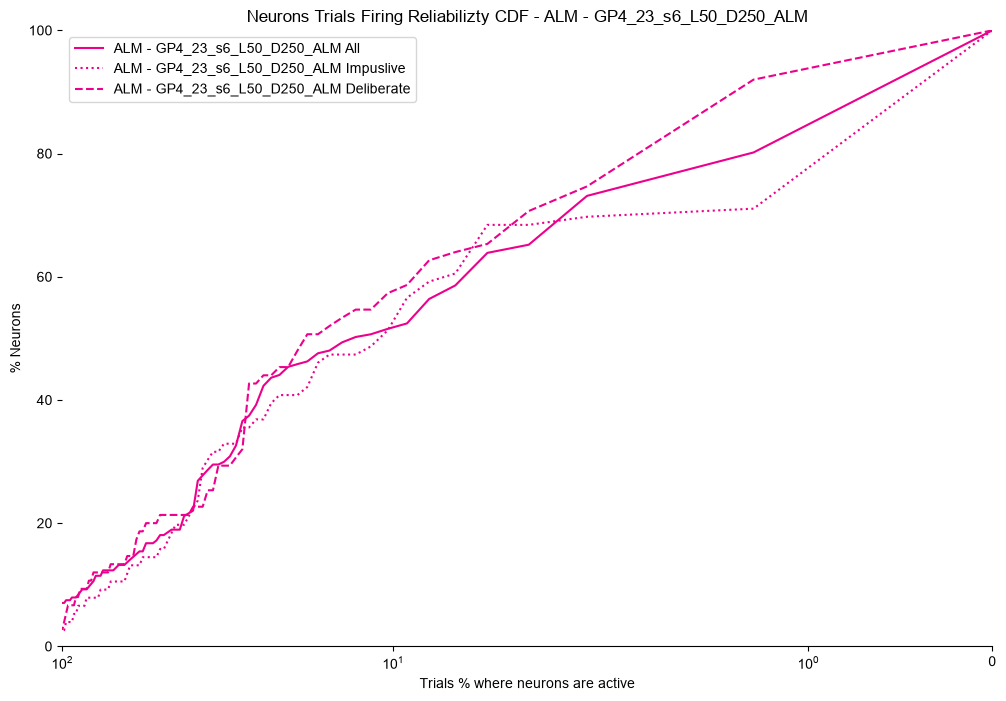

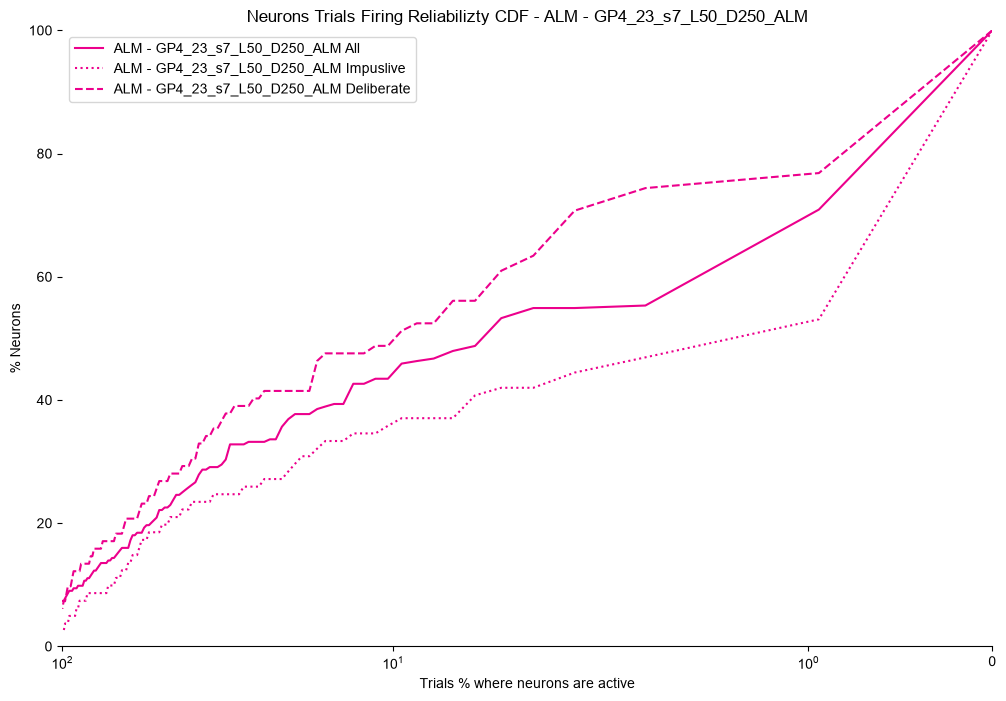

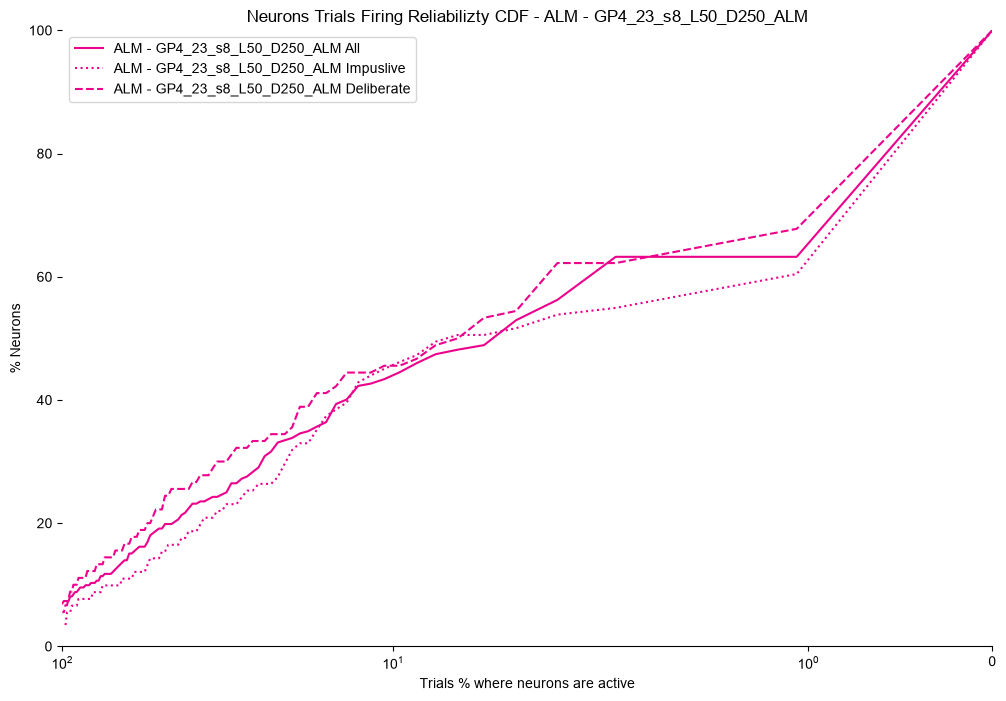

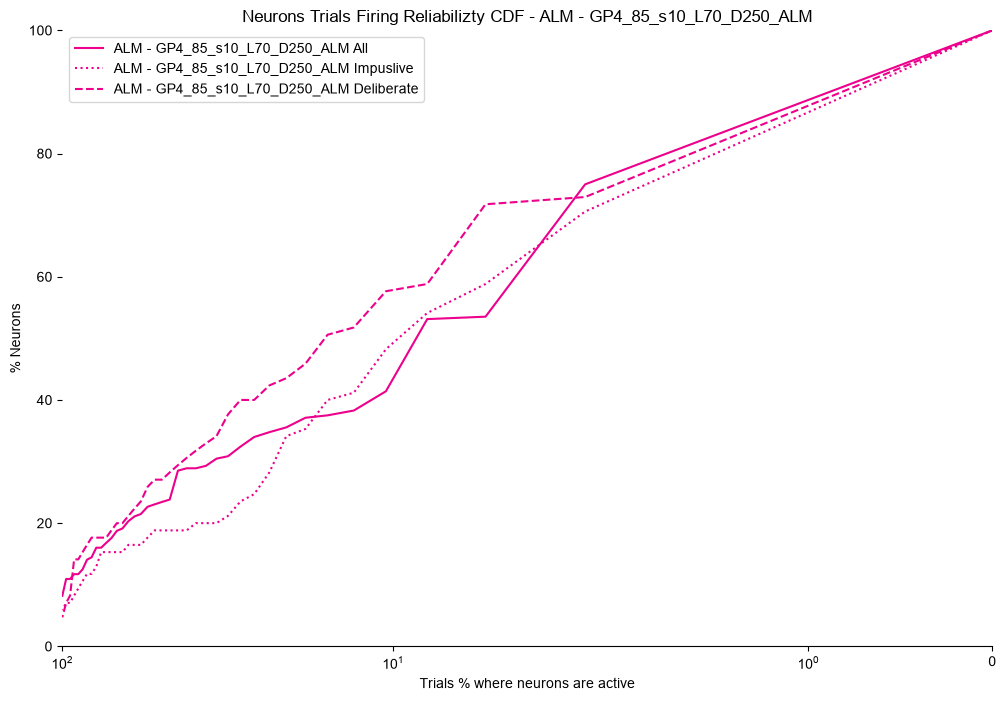

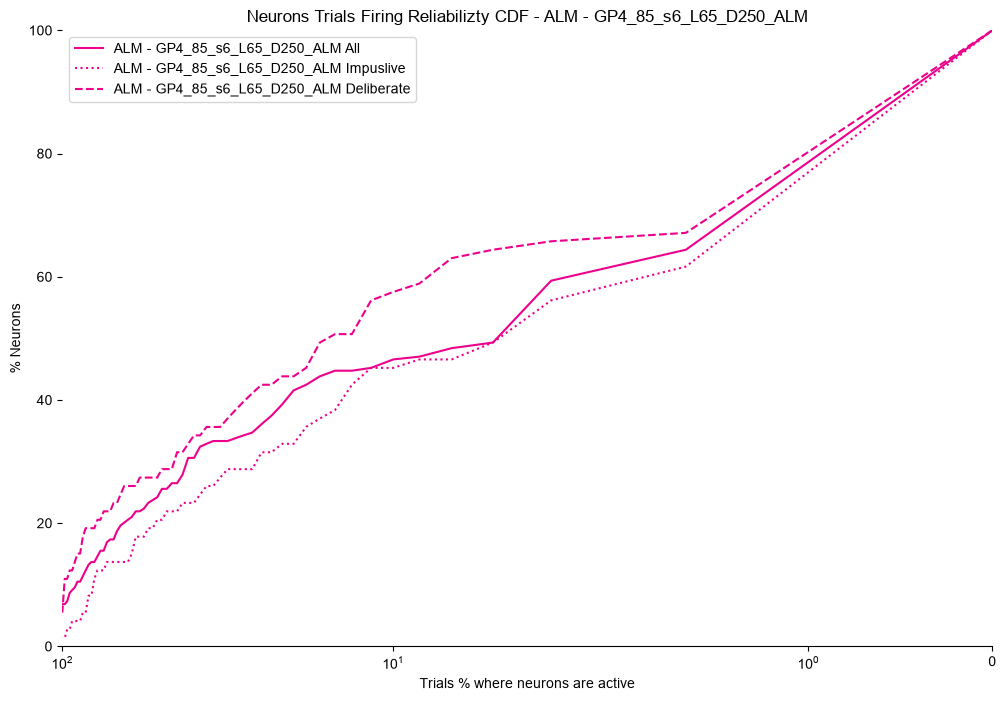

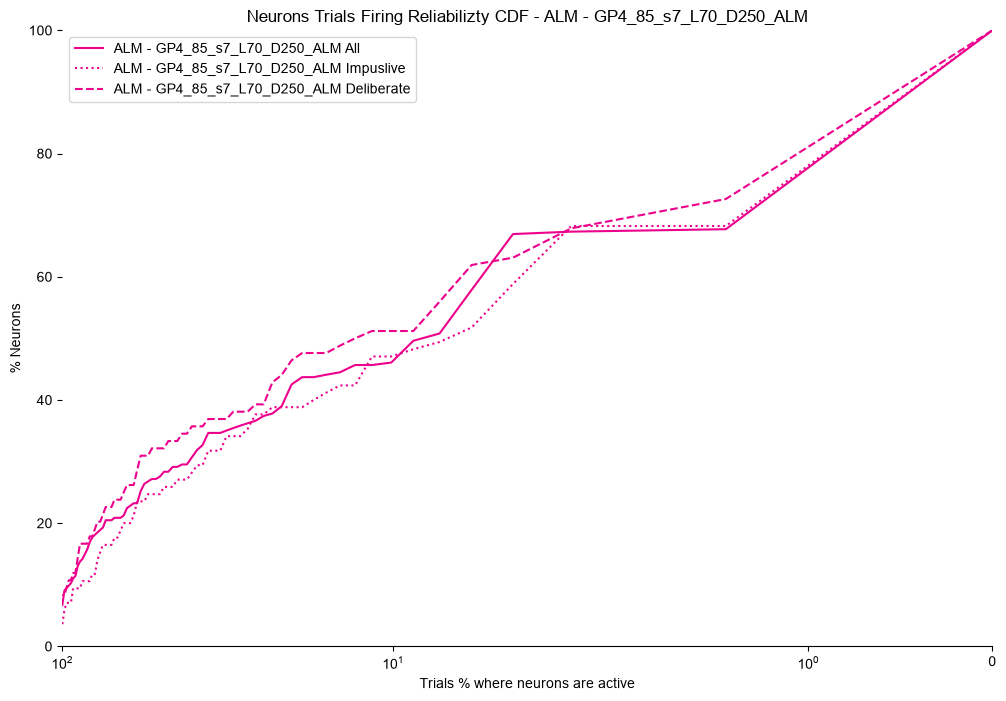

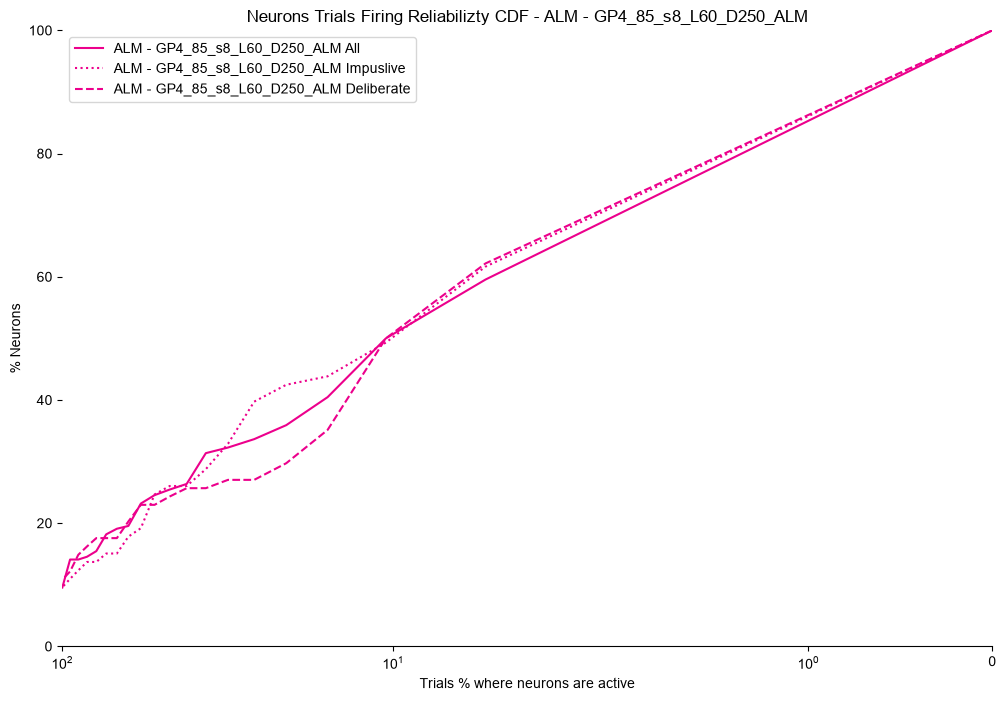

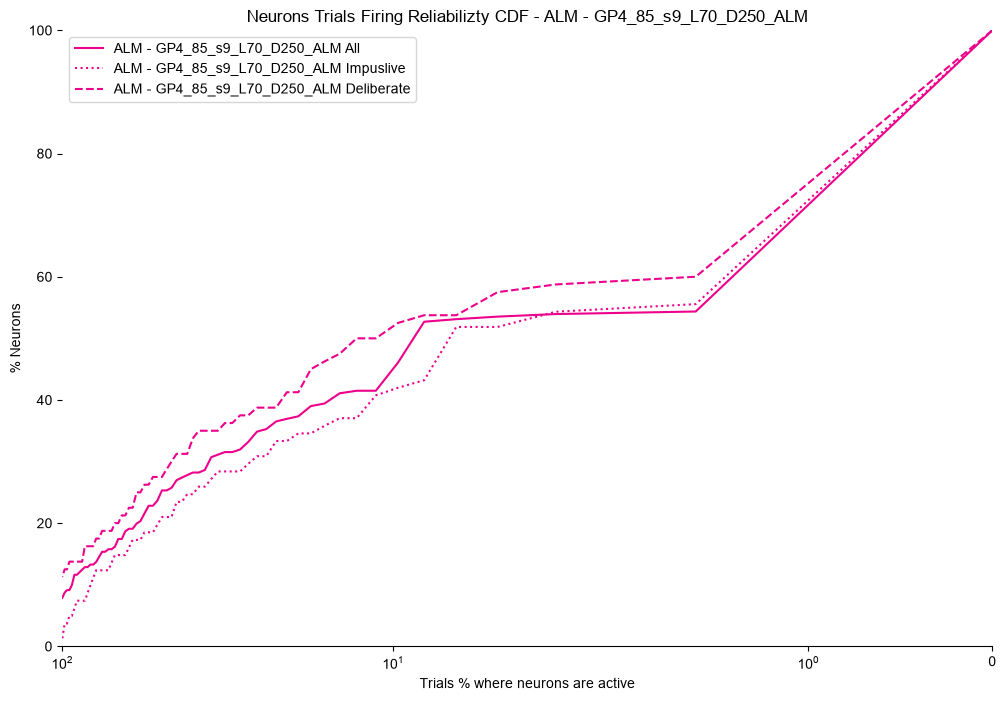

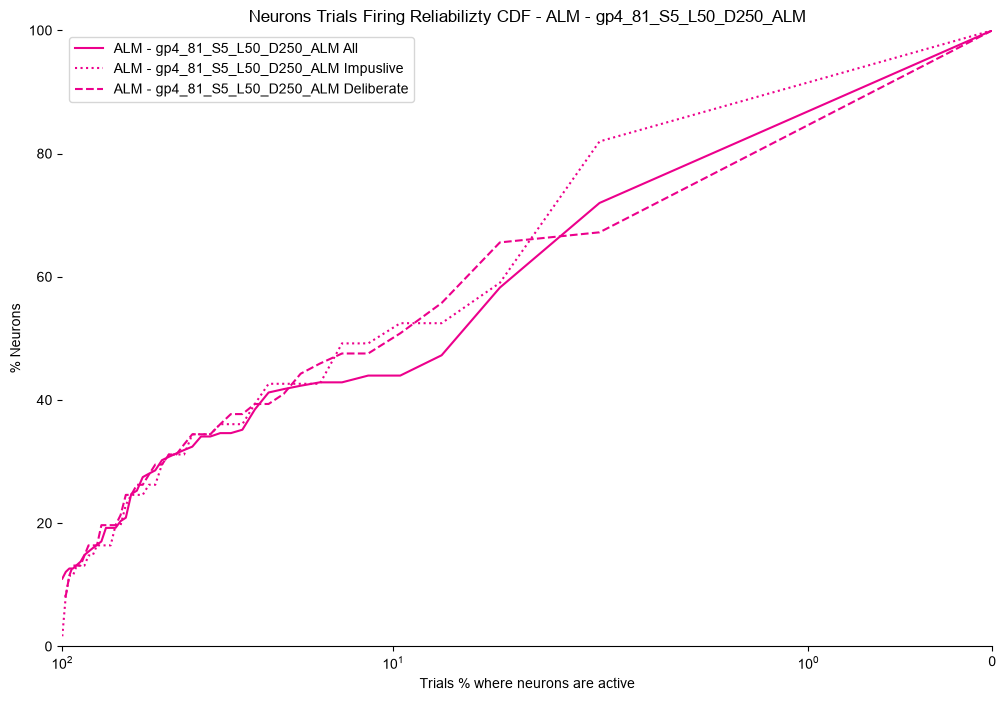

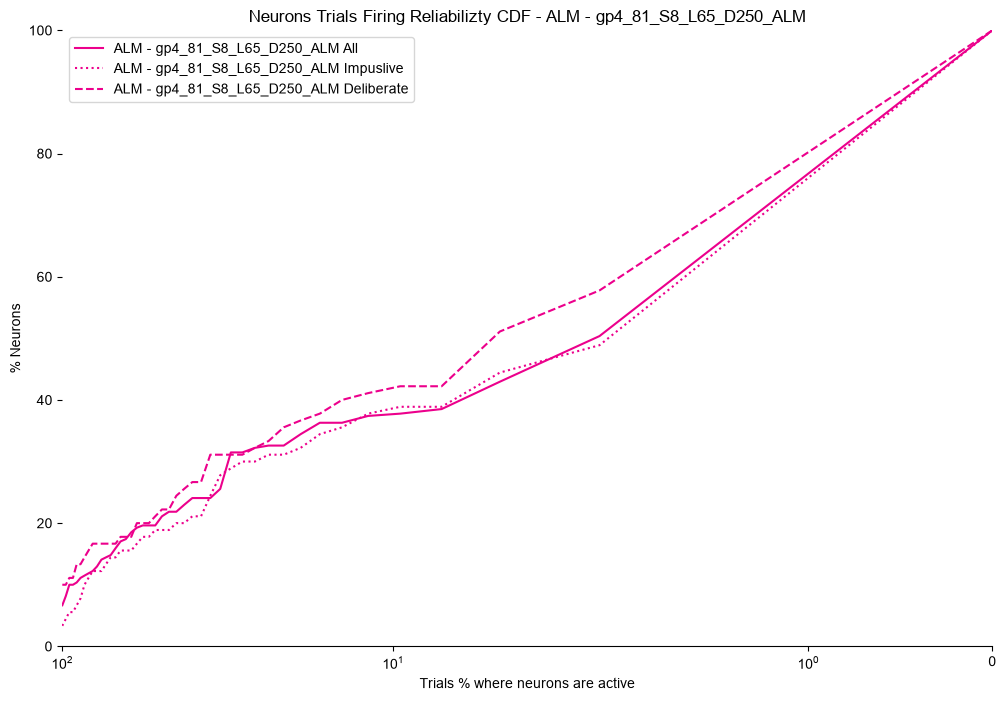

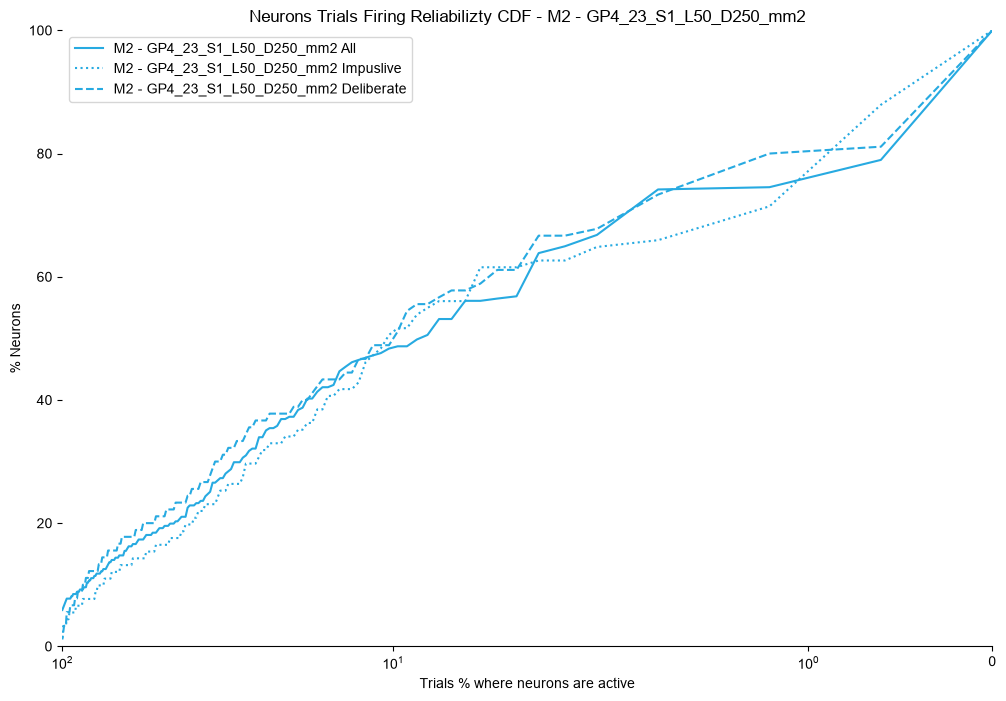

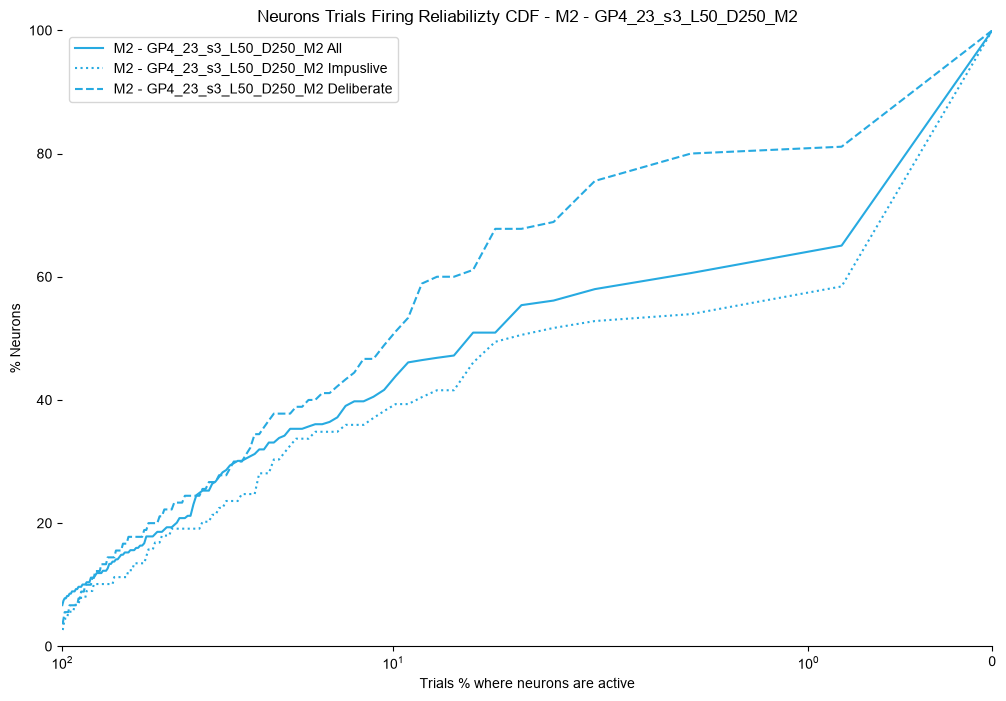

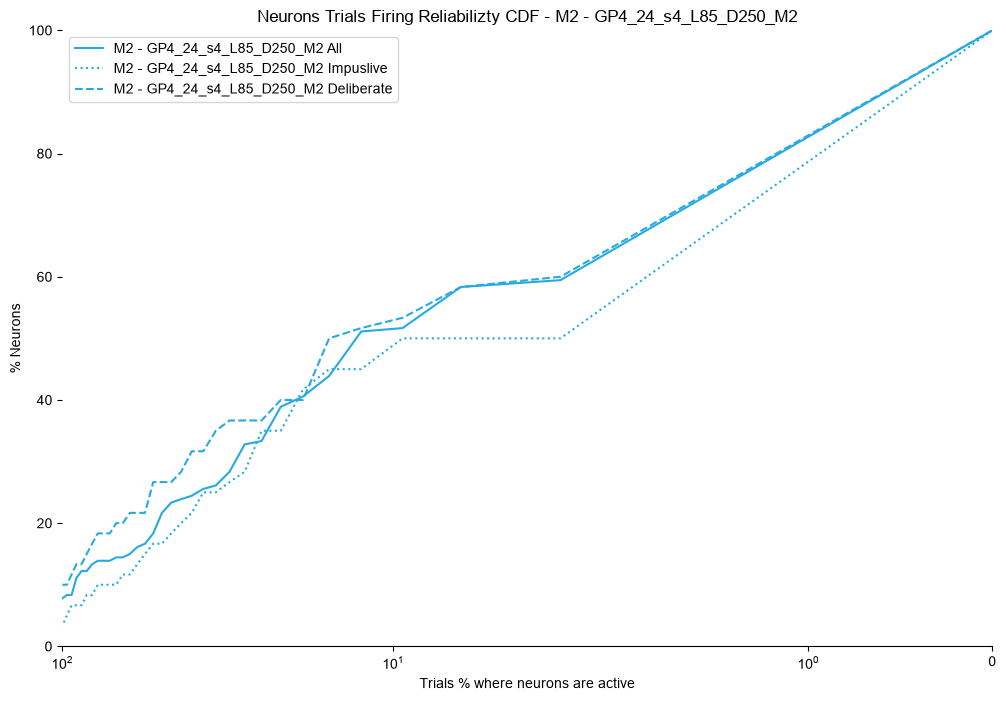

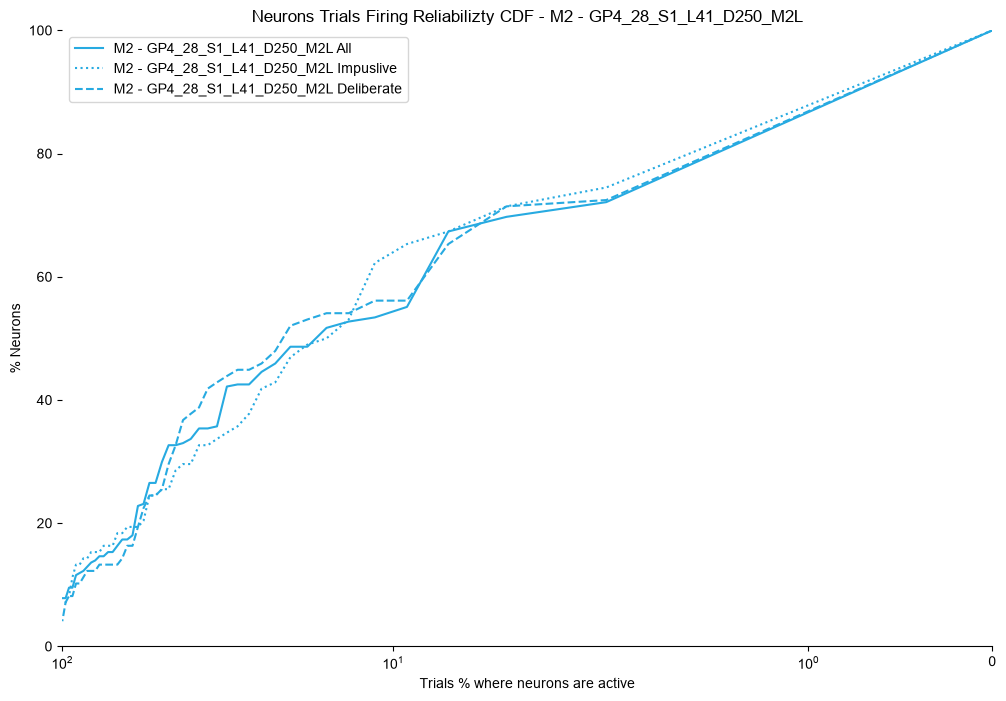

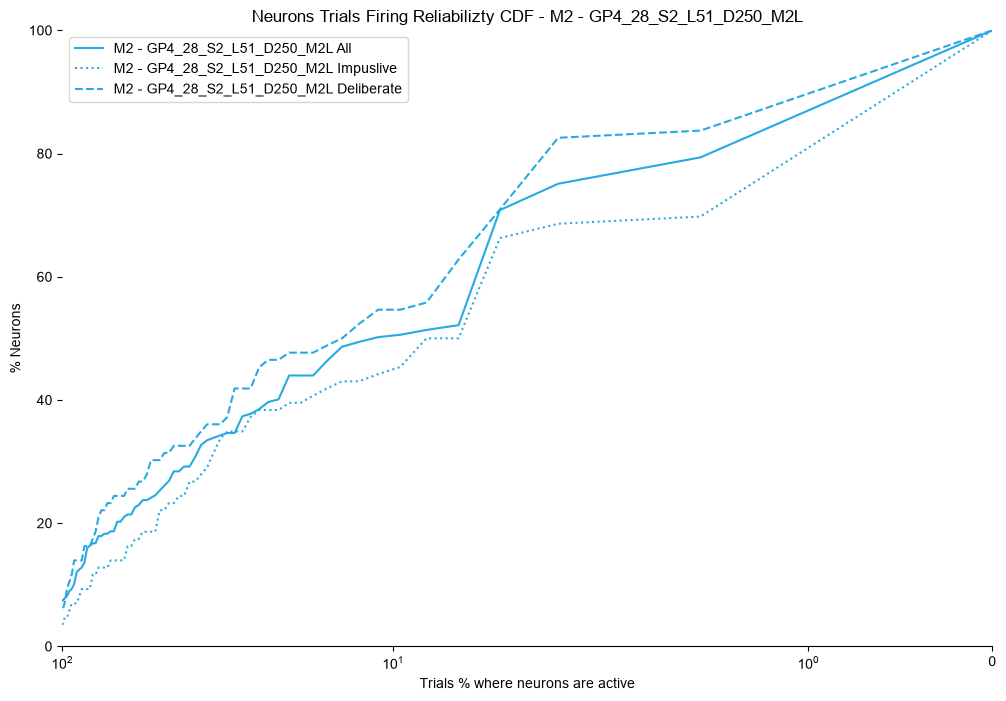

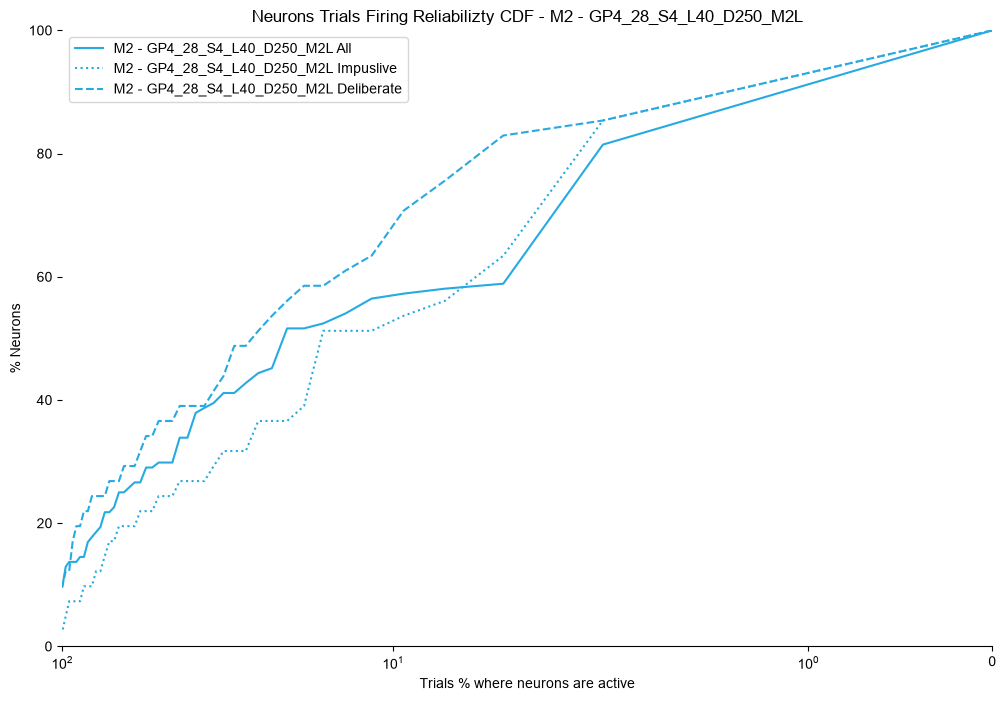

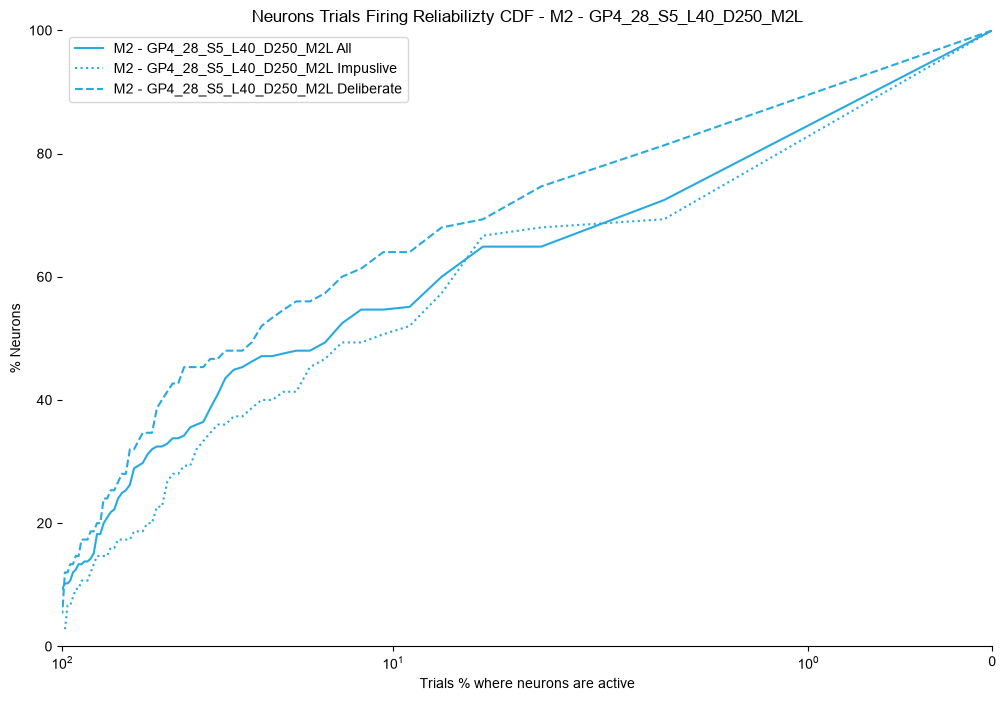

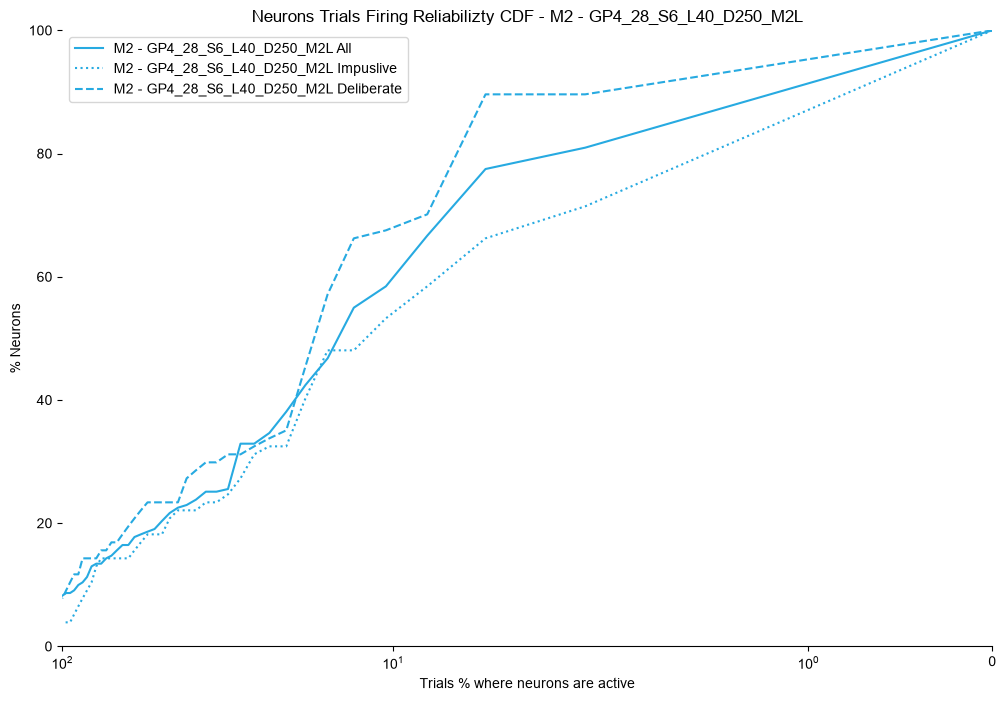

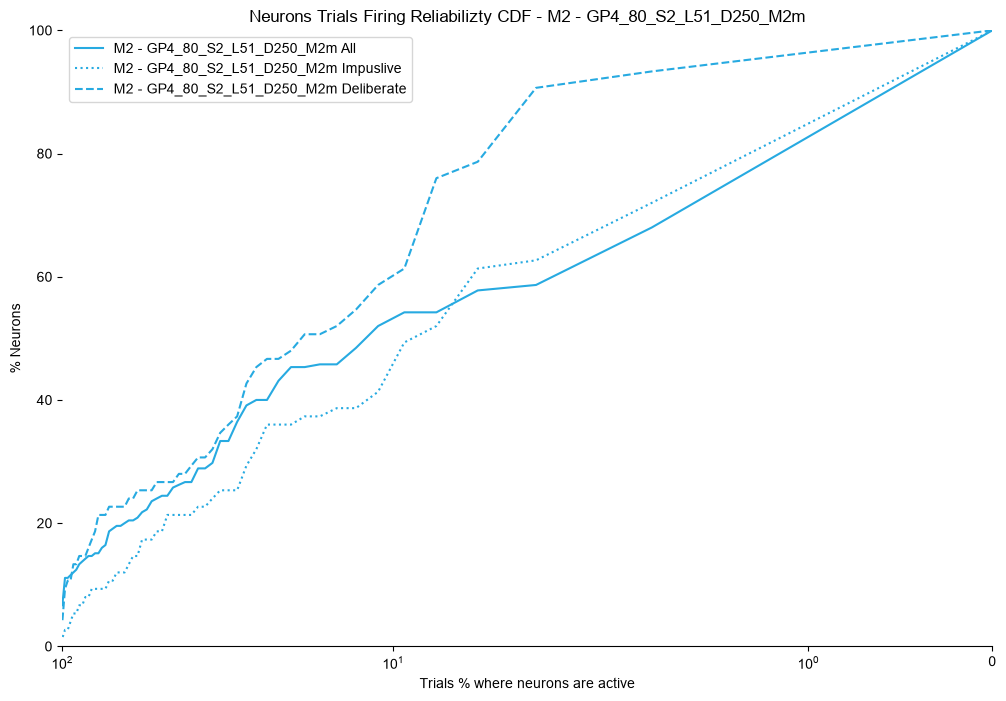

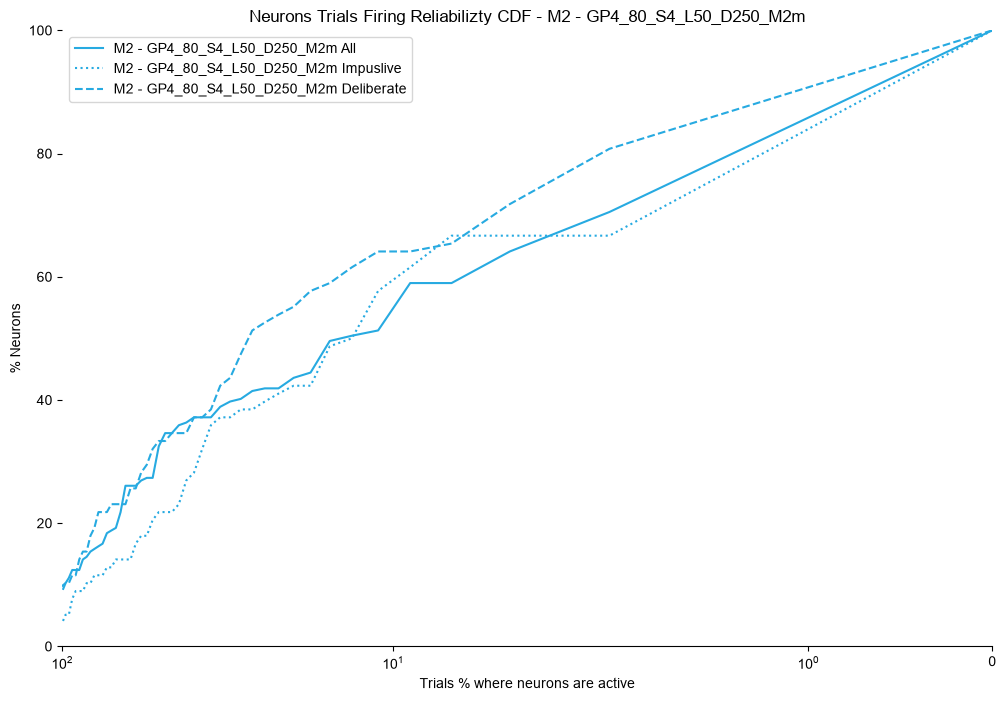

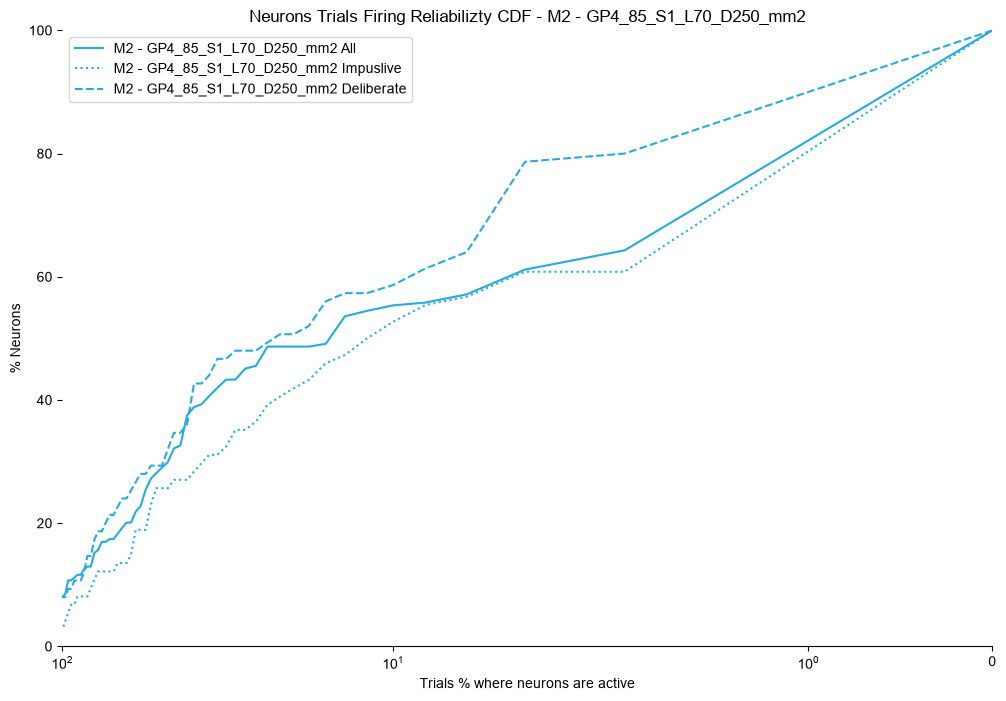

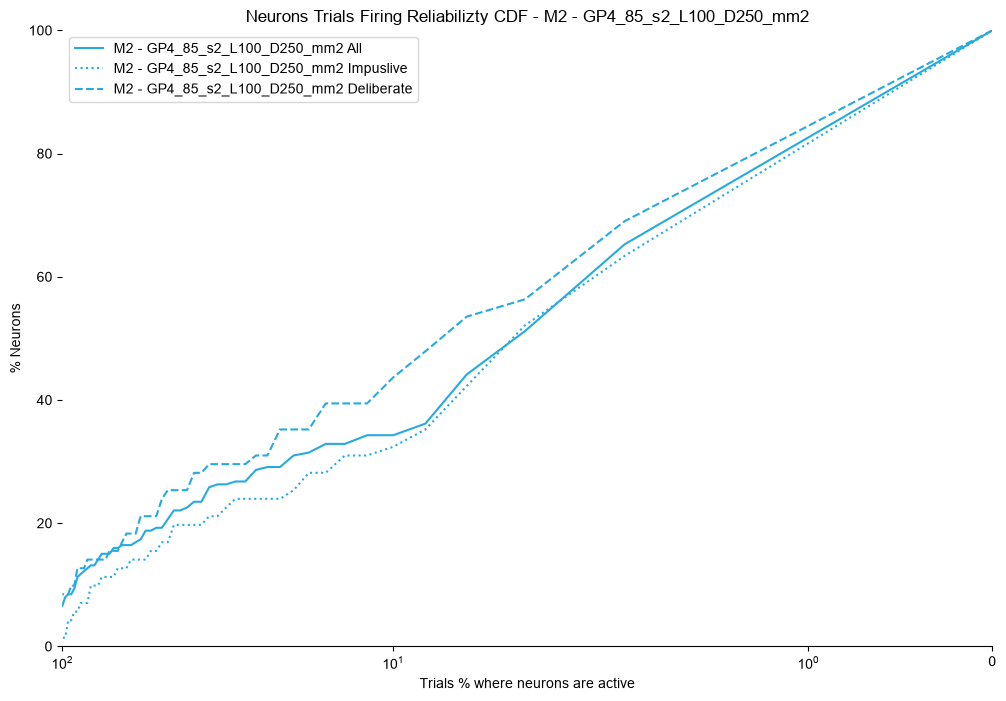

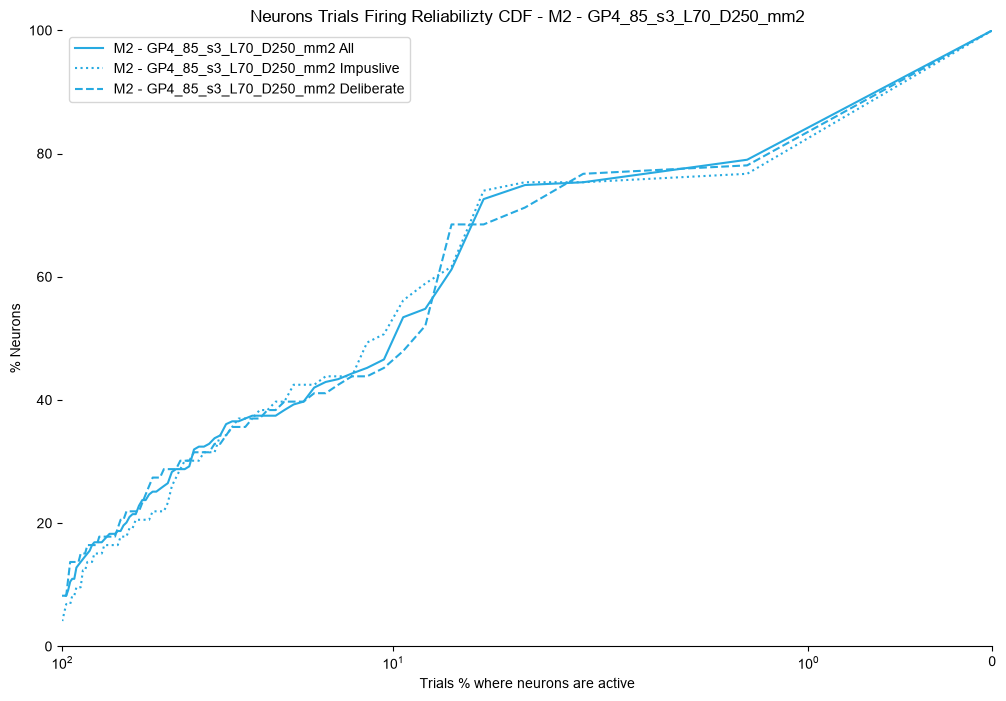

In [33]:
from .twop.activetrialscdf import plotActiveDistCDF

plotActiveDistCDF(max_firing_all_df, save_figs=SAVE_FIGS, by_sess=False,
                  fig_save_prefix=fig_save_prefix)
plotActiveDistCDF(max_firing_all_df, save_figs=SAVE_FIGS and not PAPER_FIGURES_ONLY, by_sess=True,
                  fig_save_prefix=fig_save_prefix)

### Active trials distribution over sampling

In [34]:
from .twop.tracereliability import setupEpochAxes

from .common.clr import BrainRegion as BRClr

def plotActiveDistSgfPropotion(df, sgf_neurons_ids, save_figs, save_extra_token=""):
    # ex_trace = next(iter(normed_sampling_df.iloc[0].traces_sets["neuronal"].values()))
    # max_x = len(ex_trace) - 1#/30
    epoch_ranges = normed_sampling_df.iloc[0].epochs_ranges

    fig, ax  = plt.subplots(1, figsize=(12, 8))
    for br, br_df in df.groupby("BrainRegion"):
        br = BrainRegion(br)
        br_str = str(br).split("_")[0]
        br_clr = BRClr[BrainRegion(br)]
        br_sgf_df = br_df[br_df.trace_id.isin(sgf_neurons_ids)]

        max_firing_hist_all, bins_all = maxFiringHist(br_df, num_bins=10, epoch_ranges=epoch_ranges)
        max_firing_hist_sgf, bins_sgf = maxFiringHist(br_sgf_df, num_bins=10, epoch_ranges=epoch_ranges)
        assert (bins_all == bins_sgf).all()
        # display(max_firing_hist_all)
        total = len(max_firing_hist_all)
        def prcnt(ser):
            return 100*len(ser)/total

        counts = []
        for _df, ls in [(max_firing_hist_all, "--",),
                        (max_firing_hist_sgf, "-",)]:
            _df = _df.groupby(["bin_val_left", "bin_val_right"],
                              as_index=False).agg({"fire_pos":[prcnt, "mean"]})
            _df = _df.sort_values("bin_val_left")
            counts.append(_df.fire_pos.prcnt)


        propotion = 100*counts[1]/counts[0]
        # print(br_str, "Count Sgf:", counts[1].tolist())
        # print(br_str, "Count All:", counts[0].tolist())
        # print(br_str, "Propotion:", propotion.tolist())
        ax.stairs(propotion, bins_all, ls=ls, baseline=None,
                  color=br_clr, label=f"{br_str} Sgf./All %")
        print(br_str, "All neurons:", total, "- Sgf:", len(br_sgf_df))


    ax.set_title(f"Propotion of sgf. neurons/all neurons per bin")# and Neurons Sgf @Peak Value for\n{stats_df_dscrp}")
    setupEpochAxes([ax], normed_sampling_df.iloc[0])
    ax.set_ylabel(f"Propotion %")
    for _ax in [ax]:
        _ax.set_xlabel("Normalized Time (s)")
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper center")
    if save_figs:
        plt.savefig(f"{fig_save_prefix}/active_propotion_sgf{save_extra_token}.pdf")
    plt.show()

plotActiveDistSgfPropotion(max_firing_all_df,  getSgfNeurons(run_data_unnormalized[0].shortlong_df),
                           save_extra_token=f"_at_{0}_prcnt_active", save_figs=False)

ALM All neurons: 609 - Sgf: 199
M2 All neurons: 837 - Sgf: 182


### Sequence characterization

In [35]:
def _combDfsSortToRef(df_ref, df_impulsive, df_deliberate, prcnt_valid,
                      ref_name):
    df_ref = df_ref[df_ref.prcnt_valid >= prcnt_valid]
    df_impulsive = df_impulsive[df_impulsive.prcnt_valid >= prcnt_valid]
    df_deliberate = df_deliberate[df_deliberate.prcnt_valid >= prcnt_valid]
    if not len(df_ref) or not len(df_impulsive) or not len(df_deliberate):
        return False, (df_ref, df_impulsive, df_deliberate)
    df_ref = extractIQR(df_ref)
    df_impulsive = extractIQR(df_impulsive)
    df_deliberate = extractIQR(df_deliberate)

    # Merge on trace_id in both, sorting will happen according to all as its
    # the first df we pass, and its sorted already by firing order
    df = pd.merge(df_ref, df_impulsive,  how='inner', on="trace_id", suffixes=(f"_{ref_name}", "_impulsive"))
    df_deliberate = df_deliberate.rename(columns={col:f"{col}_deliberate"
                                                  for col in df_deliberate.columns if col != "trace_id"})
    # suffixes has no effect here as all the columns names already differ
    df = pd.merge(df, df_deliberate, how='inner', on="trace_id", #suffixes=("", "_deliberate")
                  )
    return True, df


In [36]:
from .twop.tracereliability import setupEpochAxes

from .common.clr import BrainRegion as BRClr
from .common.definitions import BrainRegion

def _plotResults(df, col_postfix, clr, org_len, title, seq_dscrp,
                 prcnt_valid_str, ax):
    # display(br_df)
    bxp_dicts_li = []
    for y_idx, (_, row) in enumerate(df.iterrows()):
        bxp_dicts_li.append({kw:row[f"{kw}{col_postfix}"]
                             for kw in ["med", "q1", "q3", "whislo", "whishi"
                             ]})
        DISABLE_WHISKERS = True
        if DISABLE_WHISKERS:
            bxp_dicts_li[-1]["whislo"] = bxp_dicts_li[-1]["whishi"] = np.nan
    ax.bxp(bxp_dicts_li, vert=False, showfliers=False,
            boxprops=dict(#facecolor=clr,
                          color=clr),
            capprops=dict(color=clr),
            whiskerprops=dict(color=clr),
            # flierprops=dict(color=c, markeredgecolor=c),
            medianprops=dict(color='k', linewidth=2.5),)
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.set_yticks([])

    setupEpochAxes([ax], normed_sampling_df.iloc[0])
    ax.set_title(f"{title} - {seq_dscrp} Trials\n"
                 f"Neurons with count of active trials > {prcnt_valid_str}% of Total Trials = "
                 f"{100*len(df)/org_len:.4g}% ({len(df):,}/{org_len:,}) of Neurons")
    ax.set_xlabel("Normalized time (s)")
    ax.spines[["right", "left", "top"]].set_visible(False)

def _processCondition(df_typical, df_impulsive, df_deliberate, prcnt_valid, title,
                      clr, axs, normed_sampling_df):
    org_len = len(df_typical)
    is_good_merge, df = _combDfsSortToRef(df_typical, df_impulsive, df_deliberate,
                                          prcnt_valid, ref_name="typical")
    seq_dscrps = "Typical", "Impulsive", "Deliberate"
    if not is_good_merge:
        for sub_dfdf, title, ax in zip(df, seq_dscrps, axs):
            if not len(sub_df):
                ax.set_title(f"{title} - {title} Trials - No Neurons")
        return

    for seq_dscrp, col_postfix, ax in zip(seq_dscrps,
                                          ("_typical", "_impulsive", "_deliberate"),
                                          axs):
        _plotResults(df=df, col_postfix=col_postfix, clr=clr, title=title,
                     seq_dscrp=seq_dscrp, org_len=org_len,
                     prcnt_valid_str=prcnt_valid, ax=ax)


def seqIQR(df_typical, df_impulsive, df_deliberate, prcnt_valid, save_figs,
           by_sess=False):
    # display(df)
    if not by_sess:
        fig, axs = plt.subplots(2, 3, figsize=(45, 25))
        axs = iter(axs)
    for br, br_typical_df in df_typical.groupby("BrainRegion"):
        br = BrainRegion(br)
        br_str = str(br).split("_")[0]
        br_clr = BRClr[BrainRegion(br)]
        br_impulsive_df = df_impulsive[df_impulsive.BrainRegion == br]
        br_deliberate_df = df_deliberate[df_deliberate.BrainRegion == br]
        if not by_sess:
            ax = next(axs)
            _processCondition(br_typical_df, br_impulsive_df, br_deliberate_df,
                              prcnt_valid, br_str, br_clr, ax,
                              normed_sampling_df)
        else:
            for sess, sess_typical_df in br_typical_df.groupby("ShortName"):
                sess_impulsive_df = br_impulsive_df[br_impulsive_df.ShortName == sess]
                sess_deliberate_df = br_deliberate_df[br_deliberate_df.ShortName == sess]
                title = f"{br_str} - {sess}"
                fig, axs = plt.subplots(1, 3, figsize=(45, 12))
                _processCondition(sess_typical_df, sess_impulsive_df, sess_deliberate_df,
                                  prcnt_valid, title,
                                  br_clr, axs, normed_sampling_df)
                fig.tight_layout()
                if save_figs:
                    plt.savefig(f"{fig_save_prefix}/Sequence/sessions/"
                                f"seq_{br_str}_{sess}_{prcnt_valid}_prcnt_active.svg")
                    plt.close()
                    print(f"Done with prcnt_valid > {prcnt_valid} - {br_str} - {sess}")
                else:
                    plt.show()
    if not by_sess:
        fig.tight_layout()
        if save_figs:
            plt.savefig(f"{fig_save_prefix}/Sequence/seq_{prcnt_valid}_prcnt_active.svg")
        plt.show()


### Monte Carlo Simulation / Permutation testing of the sequence

In [37]:
from .common.clr import BrainRegion as BRClr
from scipy import stats
import statistics as stdlib_statistics


def _calcPenality(org_order, new_order):
    # display(org_order - new_order)
    # print("Org order:", org_order)
    # print("New order:", new_order)
    penality = np.abs((org_order - new_order)).sum() / len(org_order)
    # print("penality:", penality)
    return penality


class Penality:
    def __init__(self, other) -> None:
        self._count = 0
        self._other = other

    def _calcPenality(self, org_order, new_order):
        if self._count == 0:
            assert (org_order == new_order).all()
            penalty = _calcPenality(org_order, self._other)
        else:
            penalty = _calcPenality(org_order, new_order)
        self._count += 1
        # if self._count < 3:
        #     display(org_order - new_order)
        #     print("Org order:", org_order)
        #     print("New order:", new_order)
        return penalty


class _Data:
    def __init__(self, my_data):
        self.my_data = my_data

class CalcPenalityMonteCarlo:
    def __init__(self, org_order):
        self._org_order = org_order
        self._count = 0
        self._samples = []
    def __call__(self, new_order):
        self._count += 1
        if self._count % 6000 == 10 and self._count < 10_000:
            self._samples.append(new_order)
        # max_len = len(self._org_order)
        # if self._count > 10_000:
        #     print(self._count,
        #         "len new_order:", len(new_order))
        #     max_len = len(new_order)
        #return np.abs((self.org_order[:max_len] - new_order[:max_len])).sum()
        # if self._count < 5:
        #     print(self._count, "- self._org_order:", self._org_order)
        #     print(self._count, "- New order:", new_order)

        penalities = []
        for new_o in new_order:
            penality =  _calcPenality(self._org_order.my_data, new_o.my_data)
            penalities.append(penality)
        # if self._count < 5:
        #     print(self._count, "- Penality:", penality)
        return np.array(penalities)


def _prevDiff(df, ref_col, other_col, normalize, use_monte_carlo,
             partial_perm_prcnt=None):
    df = df.copy()
    df[f"{ref_col}_rank"] = df[ref_col].rank(method="dense").values
    df[f"{other_col}_rank"] = df[other_col].rank(method="dense").values
    # display(df)
    x, y = df[f"{ref_col}_rank"].values, df[f"{other_col}_rank"].values
    N_RESAMPLES = 100_000
    if use_monte_carlo:
        penalityCalcMonteCarlo = CalcPenalityMonteCarlo(_Data(x))
        print("--penalityCalc:", penalityCalcMonteCarlo((_Data(y),)))
        hist_res = np.histogram(y, bins=15, density=True)
        rvs_hist = stats.rv_histogram(hist_res, density=False)
        def createRun(size):
            # assert size == 1, f"size = {size} != 1"
            # return rvs_hist.rvs(size=(size, len(y)))
            # print("Size of run:", size)
            return np.array([_Data(rvs_hist.rvs(size=len(y))) for _ in range(size[0])])
        print("Creating run")
        stats_res = stats.monte_carlo_test((_Data(y), ), createRun,
                                           penalityCalcMonteCarlo,
                                           n_resamples=N_RESAMPLES,
                                           #method="approximate"
                                           vectorized=False,)
        assert len(stats_res.pvalue) == 1
        stats_res.pvalue = stats_res.pvalue[0]
        stats_res.statistic = stats_res.statistic[0]
        # print("Null distribution:", stats_res.null_distribution.shape)
        stats_res.null_distribution = stats_res.null_distribution[:, 0]
    elif partial_perm_prcnt is None:
        # print("--penalityCalc:", _calcPenality(x, y))
        # This is a hacky way. We rely on the implentation detail that the first
        # call calculates the original score and the following one runs the
        # permutations. So we force the first call to return the value against
        # y then continue normally with shuffling x, i.e the reference order.
        penalty = Penality(y)
        # NOT SEEDED: no rng= is passed, so every run draws different permutations
        # and this panel is not reproducible run to run. It should be seeded; seeding
        # would shift the published p-values, so that is a decision, not a cleanup.
        # See docs/repo-audit.md, "The permutation panels are unseeded".
        stats_res = stats.permutation_test((x, x), penalty._calcPenality,
                                           n_resamples=N_RESAMPLES,
                                           vectorized=False,
                                           permutation_type="pairings")
    else:
        from scipy.special import perm
        assert 0 < partial_perm_prcnt < 100
        penality = _calcPenality(x, y)
        raise NotImplementedError("Partial permutation not implemented")

    mean = np.mean(stats_res.null_distribution)
    std = np.std(stats_res.null_distribution)
    norm_dist = stdlib_statistics.NormalDist(mu=mean, sigma=std)
    lower_sgf_val = norm_dist.inv_cdf(.025)
    lower_v_sgf_val = norm_dist.inv_cdf(.01)

    if normalize:
        lower_sgf_zscore = norm_dist.zscore(lower_sgf_val)
        lower_v_sgf_zscore = norm_dist.zscore(lower_v_sgf_val)
        print("Mean:", mean, "- std:", std, "Cdf mean:", norm_dist.zscore(mean),
              "Lower sgf:", lower_sgf_val, "Lower sgf zscore:", lower_sgf_zscore,
              "Lower v sgf:", lower_v_sgf_val, "Lower v sgf zscore:", lower_v_sgf_zscore)
        stats_res.null_distribution = norm_dist.zscore(stats_res.null_distribution)
        stats_res.statistic = norm_dist.zscore(stats_res.statistic)
        # stats_res.pvalue = norm_dist.cdf(stats_res.statistic)

    return stats_res, (lower_sgf_zscore if normalize else lower_sgf_val), (
                       lower_v_sgf_zscore if normalize else lower_v_sgf_val)

def _seqOrder(df_typical, df_impulsive, df_deliberate, prcnt_valid, normalized,
              monte_carlo, title, clr, save_figs):
    is_good_merge, df = _combDfsSortToRef(df_typical, df_impulsive, df_deliberate,
                                          prcnt_valid, ref_name="typical")
    #seq_dscrps = "All", "Impulsive", "Deliberate"
    if not is_good_merge:
        return

    ref_col = "med_typical"
    stats_res_impulsive, low_sgf_val_impulsive, low_v_sgf_val_impulsive = \
                 _prevDiff(df, ref_col, "med_impulsive", normalized, monte_carlo)
    stats_res_deliberate, low_sgf_val_deliberate, low_v_sgf_val_deliberate = \
                _prevDiff(df, ref_col, "med_deliberate", normalized, monte_carlo)
    stats_res_typical, low_sgf_val_typical, low_v_sgf_val_typical = \
                   _prevDiff(df, ref_col, "med_typical", normalized, monte_carlo)
    print("stats_res_impulsive.pvalue:", stats_res_impulsive.pvalue)
    print("stats_res_deliberate.pvalue:", stats_res_deliberate.pvalue)
    PLOT = True
    PLOT_PROGRESSION = False
    if PLOT or save_figs:
        if PLOT_PROGRESSION:
            fig, (ax_total, ax_prog) = plt.subplots(2, 1)
        else:
            fig, ax_total = plt.subplots()
        ax_total.hist([#stats_res_impulsive.null_distribution,
                       #stats_res_deliberate.null_distribution,
                       stats_res_typical.null_distribution,
                       ],
        bins=100 if monte_carlo else 25,
        histtype='step',
        label=(#f"Impulsive ({len(stats_res_impulsive.null_distribution):,} Permutations)",
               #f"Deliberate ({len(stats_res_deliberate.null_distribution):,} Permutations)",
                f"Typical ({len(stats_res_typical.null_distribution):,} Permutations)"
               ),
        color=[#"r", "y",
               "orange"],
        density=True
        )
        ax_total.axvline(stats_res_impulsive.statistic, color='r', linestyle='--',
                label=f"Impulsive - rank penality={stats_res_impulsive.statistic:.4g} - pval={stats_res_impulsive.pvalue:.4f}")
        ax_total.axvline(stats_res_deliberate.statistic, color='y', linestyle='--',
                label=f"Deliberate - rank penality={stats_res_deliberate.statistic:.4g} - pval={stats_res_deliberate.pvalue:.4f}")
        ax_total.axvline(stats_res_typical.statistic, color='orange', linestyle='--',
                   label=f"Typical - rank penality={stats_res_typical.statistic:.4g} - pval={stats_res_typical.pvalue:.4f}")
        ax_total.set_xlabel('Rank mismatch penality - statistic value')
        ax_total.set_ylabel('Denisty')
        test_str = "Monte Carlo" if monte_carlo else "Permutation"
        normed_str = " Z-Scored - " if normalized else ""
        ax_total.set_title(f"Sequence Rank {test_str} Test - {title} - {normed_str}#Cells: {len(df)}\n"
                    f"Min. percent of active trials per condition: {prcnt_valid}%", color=clr, fontsize="small")
        ax_total.legend(fontsize="x-small")
        # Despine
        [ax_total.spines[_dir].set_visible(False) for _dir in ["right", "left", "top"]]

        if PLOT_PROGRESSION:
            INCREMENTS = 5


        if save_figs:
            print("saving...")
            plt.savefig(f"{fig_save_prefix}/Sequence/"
                        f"seq_rank_{title}_{test_str}_{normed_str}_"
                        f"{prcnt_valid}_prcnt_active.svg")
            plt.close()
        else:
            plt.show()

    return dict(impulsive_stat=stats_res_impulsive.statistic,
                impulsive_sgf=low_sgf_val_impulsive,
                impulsive_v_sgf=low_v_sgf_val_impulsive,
                deliberate_stat=stats_res_deliberate.statistic,
                deliberate_sgf=low_sgf_val_deliberate,
                deliberate_v_sgf=low_v_sgf_val_deliberate,
                typical_stat=stats_res_typical.statistic,
                typical_sgf=low_sgf_val_typical,
                typical_v_sgf=low_v_sgf_val_typical,)


def seqOrder(df_typical, df_impulsive, df_deliberate, prcnt_valid,
             normalized, monte_carlo, save_figs, by_sess=False):
    # if not by_sess:
    #     fig, axs = plt.subplots(2, 1, figsize=(15, 25))
    #     axs = iter(axs)
    df_penalities = []

    for br, br_typical_df in df_typical.groupby("BrainRegion"):
        br = BrainRegion(br)
        br_str = str(br).split("_")[0]
        br_clr = BRClr[BrainRegion(br)]
        br_impulsive_df = df_impulsive[df_impulsive.BrainRegion == br]
        br_deliberate_df = df_deliberate[df_deliberate.BrainRegion == br]
        br_penalities = []
        if not by_sess:
            # ax = next(axs)
            penality = _seqOrder(br_typical_df, br_impulsive_df, br_deliberate_df,
                                 prcnt_valid, normalized=normalized, monte_carlo=monte_carlo,
                                 title=br_str, clr=br_clr, save_figs=save_figs,
                                 )
            print(br_str, "penality:", penality)
            br_penalities.append(penality)
        else:
            for sess, sess_typical_df in br_typical_df.groupby("ShortName"):
                title = f"{br_str} - {sess}"
                # fig, ax = plt.subplots(figsize=(15, 12))
                sess_impulsive_df = br_impulsive_df[br_impulsive_df.ShortName == sess]
                sess_deliberate_df = br_deliberate_df[br_deliberate_df.ShortName == sess]
                penality = _seqOrder(sess_typical_df, sess_impulsive_df, sess_deliberate_df,
                                     prcnt_valid, normalized=normalized, monte_carlo=monte_carlo,
                                     title=title, clr=br_clr, save_figs=save_figs,
                                     )
                print(br_str, sess, "penality:", penality)
                penality["ShortName"] = sess
                br_penalities.append(penality)

        df_penality = pd.DataFrame(br_penalities)
        df_penality["BrainRegion"] = br_str
        df_penalities.append(df_penality)

    df_res = pd.concat(df_penalities)
    df_res["normalized"] = normalized
    df_res["test_name"] = "Monte Carlo" if monte_carlo else "Permutation"
    df_res["prcnt_valid"] = prcnt_valid
    if not by_sess:
        # if save_figs:
        #     plt.savefig(f"{fig_save_prefix}/Sequence/seq_{prcnt_valid}_prcnt_active.svg")
        # plt.show()
        pass
    return df_res


def loopPrctnValidSeqOrder(df_typical, df_impulsive, df_deliberate, normalized,
                           monte_carlo, save_figs, by_sess=False):
    for PRCNT_VALID in [10]:
        df_res = seqOrder(df_typical, df_impulsive, df_deliberate,
                          normalized=normalized, monte_carlo=monte_carlo,
                          prcnt_valid=PRCNT_VALID, save_figs=save_figs,
                          by_sess=by_sess)
        return df_res

df_stats_res = loopPrctnValidSeqOrder(#max_firing_all_df,
                                      max_firing_q2_df,
                                      max_firing_q1_df, max_firing_q3_df,
                                      normalized=True, monte_carlo=False,
                                      by_sess=True,
                                      save_figs=False)

Mean: 10.556552173913044 - std: 1.004282097896308 Cdf mean: 0.0 Lower sgf: 8.588195431717951 Lower sgf zscore: -1.9599639845400545 Lower v sgf: 8.220242650534692 Lower v sgf zscore: -2.326347874040841


Mean: 10.554187391304346 - std: 1.0018499819628581 Cdf mean: 0.0 Lower sgf: 8.590597508745041 Lower sgf zscore: -1.9599639845400538 Lower v sgf: 8.223535815657197 Lower v sgf zscore: -2.3263478740408403


Mean: 10.55275043478261 - std: 1.001214952089755 Cdf mean: 0.0 Lower sgf: 8.590405187903695 Lower sgf zscore: -1.959963984540053 Lower v sgf: 8.223576159530705 Lower v sgf zscore: -2.3263478740408416
stats_res_impulsive.pvalue: 1.999980000199998e-05
stats_res_deliberate.pvalue: 1.999980000199998e-05


ALM GP4_23_s6_L50_D250_ALM penality: {'impulsive_stat': np.float64(-7.697503752764767), 'impulsive_sgf': -1.9599639845400545, 'impulsive_v_sgf': -2.326347874040841, 'deliberate_stat': np.float64(-8.690284434891169), 'deliberate_sgf': -1.9599639845400538, 'deliberate_v_sgf': -2.3263478740408403, 'typical_stat': np.float64(-10.53994490669232), 'typical_sgf': -1.959963984540053, 'typical_v_sgf': -2.3263478740408416}


Mean: 12.904945142857144 - std: 1.0336390651434832 Cdf mean: 0.0 Lower sgf: 10.879049802162267 Lower sgf zscore: -1.9599639845400532 Lower v sgf: 10.50034110113504 Lower v sgf zscore: -2.3263478740408403


...

M2 GP4_85_s2_L100_D250_mm2 penality: {'impulsive_stat': np.float64(-4.79678158928165), 'impulsive_sgf': -1.9599639845400534, 'impulsive_v_sgf': -2.3263478740408408, 'deliberate_stat': np.float64(-4.756193182309346), 'deliberate_sgf': -1.959963984540054, 'deliberate_v_sgf': -2.3263478740408408, 'typical_stat': np.float64(-8.785921842100747), 'typical_sgf': -1.959963984540054, 'typical_v_sgf': -2.3263478740408403}


Mean: 10.67764603174603 - std: 0.8694161154107701 Cdf mean: 0.0 Lower sgf: 8.973621757962203 Lower sgf zscore: -1.9599639845400536 Lower v sgf: 8.65508170000334 Lower v sgf zscore: -2.3263478740408403


Mean: 10.676493968253968 - std: 0.8699268945264934 Cdf mean: 0.0 Lower sgf: 8.971468585799267 Lower sgf zscore: -1.9599639845400545 Lower v sgf: 8.65274138660131 Lower v sgf zscore: -2.3263478740408408


Mean: 10.674856825396827 - std: 0.8691122603544452 Cdf mean: 0.0 Lower sgf: 8.971428096579915 Lower sgf zscore: -1.9599639845400543 Lower v sgf: 8.652999366218433 Lower v sgf zscore: -2.326347874040841
stats_res_impulsive.pvalue: 1.999980000199998e-05
stats_res_deliberate.pvalue: 1.999980000199998e-05


M2 GP4_85_s3_L70_D250_mm2 penality: {'impulsive_stat': np.float64(-9.725404969666224), 'impulsive_sgf': -1.9599639845400536, 'impulsive_v_sgf': -2.3263478740408403, 'deliberate_stat': np.float64(-10.448225521179783), 'deliberate_sgf': -1.9599639845400545, 'deliberate_v_sgf': -2.3263478740408408, 'typical_stat': np.float64(-12.282483302034375), 'typical_sgf': -1.9599639845400543, 'typical_v_sgf': -2.326347874040841}


Sgf. mean impulsive: -1.96 - std: 0.00
Sgf. mean deliberate: -1.96 - std: 0.00
Sgf. mean: -1.96
Sgf. v mean: -2.33


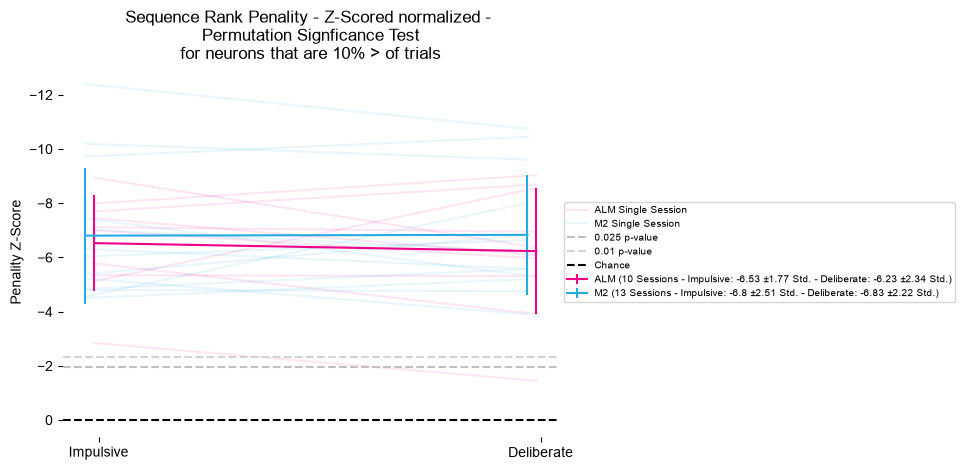

In [38]:
def plotPenalityCost(df, save_figs):

    fig, ax = plt.subplots()
    offset = -0.01
    x_ticks = np.array([1, 2])
    for br, br_df in df.groupby("BrainRegion"):
        br_clr = BRClr[br + "_Bi"]
        printed_label_once = False
        for sess, sess_df in br_df.iterrows():
            ax.plot(x_ticks+offset, [sess_df.impulsive_stat, sess_df.deliberate_stat],
                    color=br_clr, alpha=0.1,
                    label=f"{br} Single Session" if not printed_label_once else None)
            printed_label_once = True

        mean_impulsive = br_df.impulsive_stat.mean()
        mean_deliberate = br_df.deliberate_stat.mean()
        std_impulsive = br_df.impulsive_stat.std()
        std_deliberate = br_df.deliberate_stat.std()
        ax.errorbar(x_ticks+offset, [br_df.impulsive_stat.mean(), br_df.deliberate_stat.mean()],
                    yerr=[br_df.impulsive_stat.std(), br_df.deliberate_stat.std()],
                    color=br_clr,
                    label=(f"{br} ({len(br_df)} Sessions - "
                           f"Impulsive: {mean_impulsive:.3g} ±{std_impulsive:.3g} Std. - "
                           f"Deliberate: {mean_deliberate:.3g} ±{std_deliberate:.3g} Std.)")
        )
        offset += offset*2


    print(f"Sgf. mean impulsive: {df.impulsive_sgf.mean():.2f} - std: {df.impulsive_sgf.std():.2f}")
    print(f"Sgf. mean deliberate: {df.deliberate_sgf.mean():.2f} - std: {df.deliberate_sgf.std():.2f}")
    # ax.axhline(df.impulsive_sgf.mean(), color="r", linestyle="--", label="Sgf. Impulsive")
    # ax.axhline(df.deliberate_sgf.mean(), color="y", linestyle="--", label="Sgf. Deliberate")
    sgf_val = pd.concat([df.impulsive_sgf, df.deliberate_sgf]).mean()
    print(f"Sgf. mean: {sgf_val:.2f}")
    ax.axhline(sgf_val, color="silver", linestyle="--", label="0.025 p-value")
    #
    sgf_v_val = pd.concat([df.impulsive_v_sgf, df.deliberate_v_sgf]).mean()
    print(f"Sgf. v mean: {sgf_v_val:.2f}")
    ax.axhline(sgf_v_val, color="lightgrey", linestyle="--", label="0.01 p-value")

    normalized_str = "- Z-Scored normalized - " if df.normalized.iloc[0] else ""
    test_name = df.test_name.iloc[0]
    prcnt_valid = df.prcnt_valid.iloc[0]
    ax.set_title(f"Sequence Rank Penality {normalized_str}\n"
                 f"{test_name} Signficance Test\n"
                 f"for neurons that are {prcnt_valid}% > of trials")
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(["Impulsive", "Deliberate"])
    # Reverse y-axis
    ax.axhline(0, color="k", linestyle="--", label="Chance")
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.set_ylabel("Penality Z-Score")
    ax.legend(fontsize="x-small", loc="center left", bbox_to_anchor=(1, 0.5))
    ax.spines[["right", "left", "top", "bottom"]].set_visible(False)
    if save_figs:
        save_fp = (f"{fig_save_prefix}/Sequence/penality_sgf_summary_"
                   f"{test_name}{'_normalized' if normalized_str else ''}_"
                   f"{prcnt_valid}_prcnt_valid.svg")
        path = pathlib.Path(save_fp)
        path.parent.mkdir(exist_ok=True)
        plt.savefig(save_fp, bbox_inches='tight')
    plt.show()

#df_stats_res
plotPenalityCost(df_stats_res, save_figs=SAVE_FIGS)

### Seq firing deviation

In [39]:
from .common.clr import BrainRegion as BRClr
import numpy as np
from scipy import stats
import statistics as stdlib_statistics


def _calcDeviation(fast_rank, slow_rank):
    deviation = np.abs((fast_rank - slow_rank)).sum() / len(fast_rank)
    return deviation


def _fastSlowDeviation(df, fast_col, slow_col):
    df = df.copy()
    df[f"{fast_col}_rank"] = df[fast_col].rank(method="dense").values
    df[f"{slow_col}_rank"] = df[slow_col].rank(method="dense").values
    # display(df)
    x, y = df[f"{fast_col}_rank"].values, df[f"{slow_col}_rank"].values
    N_RESAMPLES = 100_000
    # org_deviation = _calcDeviation(x, y)
    # NOT SEEDED: no rng= is passed, so every run draws different permutations
    # and this panel is not reproducible run to run. It should be seeded; seeding
    # would shift the published p-values, so that is a decision, not a cleanup.
    # See docs/repo-audit.md, "The permutation panels are unseeded".
    stats_res = stats.permutation_test((x, y), _calcDeviation,
                                        n_resamples=N_RESAMPLES,
                                        permutation_type="pairings",
                                        alternative="less")

    mean = np.mean(stats_res.null_distribution)
    std = np.std(stats_res.null_distribution)
    norm_dist = stdlib_statistics.NormalDist(mu=mean, sigma=std)

    return stats_res, norm_dist

def _seqOrder2(df_typical, df_impulsive, df_deliberate, prcnt_valid, title,
               clr, save_figs):
    is_good_merge, df = _combDfsSortToRef(df_typical, df_impulsive, df_deliberate,
                                          prcnt_valid, ref_name="typical")
    #seq_dscrps = "All", "Impulsive", "Deliberate"
    if not is_good_merge:
        return

    stats_res_deviation, norm_dist = \
                       _fastSlowDeviation(df, "med_impulsive", "med_deliberate")
    print("sstats_res_deviation.pvalue:", stats_res_deviation.pvalue)
    PLOT = True
    if PLOT or save_figs:
        fig, ax_total = plt.subplots()
        normed_null_dist = norm_dist.zscore(
                                          stats_res_deviation.null_distribution)
        ax_total.hist(normed_null_dist, bins=25, histtype='step', color="k",
                      density=True, label=f"Shuffle ({len(normed_null_dist):,} Permutations)")
        deviation = stats_res_deviation.statistic
        normed_deviation = norm_dist.zscore(deviation)
        ax_total.axvline(normed_deviation, color='k', linestyle='--',
                         label=f"Deviation {deviation:.4g} (z-score={normed_deviation:.4g})\n"
                               f"pval={stats_res_deviation.pvalue:.4f}")
        ax_total.set_xlabel('Rank deviation (z-score)')
        ax_total.set_ylabel('Density')
        ax_total.set_title(
            f"Sequence Deviation Permutation Test - {title} - #Cells: {len(df)}\n"
            f"Min. percent of active trials per condition: {prcnt_valid}%", color=clr, fontsize="small")
        ax_total.legend(fontsize="x-small")
        # Despine
        [ax_total.spines[_dir].set_visible(False) for _dir in ["right", "left", "top"]]

        if save_figs:
            print("saving...")
            plt.savefig(f"{fig_save_prefix}/Sequence/deviation_rank_{title}_"
                        f"{prcnt_valid}_prcnt_active.svg")
            plt.close()
        else:
            plt.show()

    return dict(deviation_stat=stats_res_deviation,
                deviation_normed_dist=norm_dist)


def seqOrder2(df_typical, df_impulsive, df_deliberate, prcnt_valid, save_figs,
              by_sess=False):
    # if not by_sess:
    #     fig, axs = plt.subplots(2, 1, figsize=(15, 25))
    #     axs = iter(axs)
    df_deviations = []

    for br, br_typical_df in df_typical.groupby("BrainRegion"):
        br = BrainRegion(br)
        br_str = str(br).split("_")[0]
        br_clr = BRClr[BrainRegion(br)]
        br_impulsive_df = df_impulsive[df_impulsive.BrainRegion == br]
        br_deliberate_df = df_deliberate[df_deliberate.BrainRegion == br]
        br_penalities = []
        if not by_sess:
            # ax = next(axs)
            deviation = _seqOrder2(br_typical_df, br_impulsive_df, br_deliberate_df,
                                   prcnt_valid, title=br_str, clr=br_clr,
                                   save_figs=save_figs,)
            print(br_str, "deviation:", deviation)
            br_penalities.append(deviation)
        else:
            for sess, sess_typical_df in br_typical_df.groupby("ShortName"):
                title = f"{br_str} - {sess}"
                # fig, ax = plt.subplots(figsize=(15, 12))
                sess_impulsive_df = br_impulsive_df[br_impulsive_df.ShortName == sess]
                sess_deliberate_df = br_deliberate_df[br_deliberate_df.ShortName == sess]
                deviation = _seqOrder2(sess_typical_df, sess_impulsive_df, sess_deliberate_df,
                                       prcnt_valid,  title=title, clr=br_clr,
                                       save_figs=save_figs, )
                print(br_str, sess, "Deviation:", deviation)
                deviation["ShortName"] = sess
                br_penalities.append(deviation)

        df_deviation = pd.DataFrame(br_penalities)
        df_deviation["BrainRegion"] = br_str
        df_deviations.append(df_deviation)

    df_res = pd.concat(df_deviations)
    df_res["test_name"] = "Permutation"
    df_res["prcnt_valid"] = prcnt_valid
    if not by_sess:
        # if save_figs:
        #     plt.savefig(f"{fig_save_prefix}/Sequence/seq_{prcnt_valid}_prcnt_active.svg")
        # plt.show()
        pass
    return df_res


def loopPrctnValidSeqOrder2(df_typical, df_impulsive, df_deliberate,
                           save_figs, by_sess=False):
    for PRCNT_VALID in [10]:
        df_res = seqOrder2(df_typical, df_impulsive, df_deliberate,
                           prcnt_valid=PRCNT_VALID, save_figs=save_figs,
                           by_sess=by_sess)
        return df_res

df_stats_deviation = loopPrctnValidSeqOrder2(#max_firing_all_df,
                                             max_firing_q2_df,
                                             max_firing_q1_df, max_firing_q3_df,
                                             by_sess=True,
                                             save_figs=SAVE_FIGS)

sstats_res_deviation.pvalue: 9.99990000099999e-06
saving...
ALM GP4_23_s6_L50_D250_ALM Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(3.0217391304347827), pvalue=np.float64(9.99990000099999e-06), null_distribution=array([10.41304348,  7.67391304, 10.23913043, ...,  8.02173913,
        9.58695652, 10.19565217], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=9.635515217391305, sigma=0.8698243701627999)}


sstats_res_deviation.pvalue: 9.99990000099999e-06
saving...
ALM GP4_23_s7_L50_D250_ALM Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(5.785714285714286), pvalue=np.float64(9.99990000099999e-06), null_distribution=array([13.75714286, 14.92857143, 12.47142857, ..., 12.81428571,
       14.61428571, 12.7       ], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=13.78271657142857, sigma=1.0588601695252402)}


sstats_res_deviation.pvalue: 9.99990000099999e-06
saving...
ALM GP4_23_s8_L50_D250_ALM Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(3.3333333333333335), pvalue=np.float64(9.99990000099999e-06), null_distribution=array([10.7       , 12.36666667, 11.56666667, ...,  8.83333333,
       12.1       , 10.6       ], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=11.368923333333333, sigma=1.0051895988706696)}


sstats_res_deviation.pvalue: 0.0011899881001189987
saving...
ALM GP4_85_s10_L70_D250_ALM Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(4.068965517241379), pvalue=np.float64(0.0011899881001189987), null_distribution=array([6.48275862, 6.68965517, 5.51724138, ..., 6.68965517, 7.31034483,
       7.51724138], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=6.221707586206896, sigma=0.6951493501319144)}


sstats_res_deviation.pvalue: 9.99990000099999e-06
saving...
ALM GP4_85_s6_L65_D250_ALM Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(3.7777777777777777), pvalue=np.float64(9.99990000099999e-06), null_distribution=array([9.82222222, 9.42222222, 6.97777778, ..., 9.02222222, 7.37777778,
       8.84444444], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=9.24406311111111, sigma=0.8503330663455886)}


...

sstats_res_deviation.pvalue: 0.011259887401125988
saving...
M2 GP4_80_S2_L51_D250_M2m Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(6.947368421052632), pvalue=np.float64(0.011259887401125988), null_distribution=array([ 8.78947368, 10.26315789,  7.84210526, ...,  9.57894737,
        9.        ,  8.36842105], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=9.112002631578948, sigma=0.9227895700400998)}


sstats_res_deviation.pvalue: 0.007009929900700993
saving...
M2 GP4_80_S4_L50_D250_M2m Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(6.694444444444445), pvalue=np.float64(0.007009929900700993), null_distribution=array([ 8.08333333,  8.80555556,  8.58333333, ...,  8.30555556,
       10.63888889,  6.75      ], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=9.07952888888889, sigma=0.9580580127696332)}


sstats_res_deviation.pvalue: 9.99990000099999e-06
saving...
M2 GP4_85_S1_L70_D250_mm2 Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(3.973684210526316), pvalue=np.float64(9.99990000099999e-06), null_distribution=array([7.23684211, 8.02631579, 8.71052632, ..., 8.86842105, 7.5       ,
       7.86842105], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=8.350567894736843, sigma=0.7697720578105395)}


sstats_res_deviation.pvalue: 0.00047999520004799953
saving...
M2 GP4_85_s2_L100_D250_mm2 Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(5.029411764705882), pvalue=np.float64(0.00047999520004799953), null_distribution=array([6.38235294, 6.14705882, 7.5       , ..., 7.97058824, 7.32352941,
       6.02941176], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=7.176047647058824, sigma=0.6482522371648812)}


sstats_res_deviation.pvalue: 9.99990000099999e-06
saving...
M2 GP4_85_s3_L70_D250_mm2 Deviation: {'deviation_stat': PermutationTestResult(statistic=np.float64(3.142857142857143), pvalue=np.float64(9.99990000099999e-06), null_distribution=array([10.50793651, 10.88888889, 11.52380952, ..., 11.23809524,
       10.31746032, 11.9047619 ], shape=(100000,))), 'deviation_normed_dist': NormalDist(mu=10.798415238095238, sigma=0.8595422009163131)}


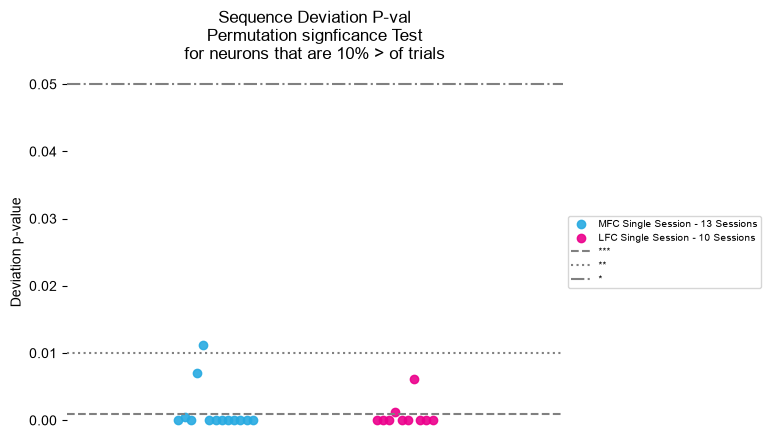

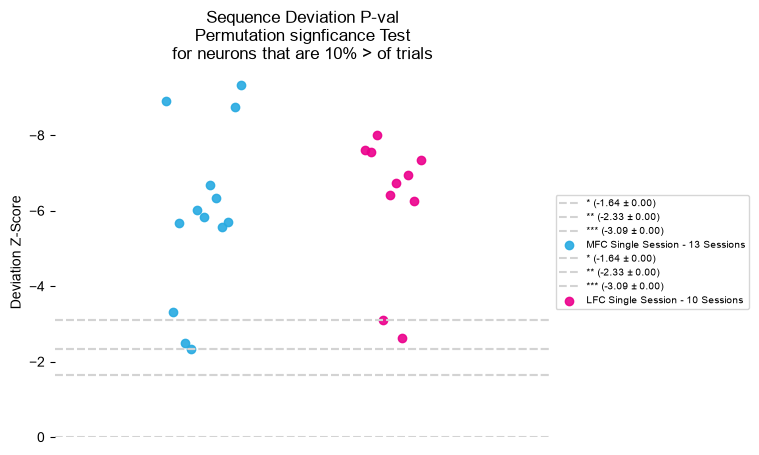

In [40]:
from typing import Literal
def _rowZscore(row, tail : Literal["two-sided", "less", "greater"] = "two-sided"):
    normed_dist = row.deviation_normed_dist
    lower_sgf_zscore = normed_dist.zscore(
                      normed_dist.inv_cdf(.025 if tail == "two-sided" else .05))
    lower_v_sgf_zscore = normed_dist.zscore(normed_dist.inv_cdf(.01))
    lower_vv_sgf_zscore = normed_dist.zscore(normed_dist.inv_cdf(.001))
    # null_distribution_zscore = normed_dist.zscore(
    #                                      row.deviation_stat.null_distribution)
    statistic_zscore = normed_dist.zscore(row.deviation_stat.statistic)
    return (lower_sgf_zscore, lower_v_sgf_zscore, lower_vv_sgf_zscore,
            statistic_zscore)

def plotDeviationAgg(df, plot_pvals, save_fig):

    fig, ax = plt.subplots()
    offset = -0.02
    # x_ticks = np.array([1, 2])
    for br_str in ["M2", "ALM"]:
        br_df = df[df.BrainRegion == br_str]
        br_clr = BRClr[br_str + "_Bi"]
        br_str = "MFC" if br_str == "M2" else "LFC"
        if plot_pvals:
            deviations_pvals = br_df.apply(
                           lambda row: row.deviation_stat.pvalue, axis=1).values
            # deviations_pvals = -np.log10(deviations_pvals)
            for idx, pt in enumerate(deviations_pvals):
                if idx == 0:
                    label = f"{br_str} Single Session - {len(br_df)} Sessions"
                else:
                    label = None
                idx %= 15
                ax.scatter([offset + idx*offset/10],  pt,
                        color=br_clr, alpha=0.9,  label=label)
        else:
            deviations_zscores = br_df.apply(_rowZscore, tail="greater",
                                             axis=1).values
            deviations_zscores = [list(row) for row in deviations_zscores]
            deviations_zscores = pd.DataFrame(deviations_zscores,
                                columns=["sgf", "v_sgf", "vv_sgf", "statistic"])
            ax.axhline(deviations_zscores.sgf.mean(), color="lightgray",
                       linestyle="--", label=f"* ({deviations_zscores.sgf.mean():.2f} ± {deviations_zscores.sgf.sem():.2f})")
            ax.axhline(deviations_zscores.v_sgf.mean(), color="lightgray",
                       linestyle="--", label=f"** ({deviations_zscores.v_sgf.mean():.2f} ± {deviations_zscores.v_sgf.sem():.2f})")
            ax.axhline(deviations_zscores.vv_sgf.mean(), color="lightgray",
                       linestyle="--", label=f"*** ({deviations_zscores.vv_sgf.mean():.2f} ± {deviations_zscores.vv_sgf.sem():.2f})")
            for idx, pt in enumerate(deviations_zscores.statistic):
                if idx == 0:
                    label = f"{br_str} Single Session - {len(br_df)} Sessions"
                else:
                    label = None
                idx %= 15
                ax.scatter([offset + idx*offset/10],  pt,
                            color=br_clr, alpha=0.9,  label=label)
        offset = np.abs(offset)

    prcnt_valid = df.prcnt_valid.iloc[0]
    ax.set_title(f"Sequence Deviation P-val\n"
                 f"Permutation signficance Test\n"
                 f"for neurons that are {prcnt_valid}% > of trials")

    # ax.set_xticklabels(["MFC", "LFC"])
    # Reverse y-axis
    ax.set_xlim(-0.08, 0.08)
    ax.set_xticks([])
    # ax.axhline(0, color="k", linestyle="--")
    if plot_pvals:
        ax.axhline(0.001, color="gray", linestyle="--", label="***")
        ax.axhline(0.01, color="gray", linestyle=":", label="**")
        ax.axhline(0.05, color="gray", linestyle="-.", label="*")
        ax.set_ylabel("Deviation p-value")
    else:
        ax.axhline(0, color="lightgray", linestyle="--")
        ax.set_ylim(top=0)
        # Reverse y-axis
        ax.set_ylim(ax.get_ylim()[::-1])
        ax.set_ylabel("Deviation Z-Score")

    ax.legend(fontsize="x-small", loc="center left", bbox_to_anchor=(1, 0.5))
    ax.spines[["right", "left", "top", "bottom"]].set_visible(False)
    if save_fig:
        extra_str = "pval" if plot_pvals else "zscore"
        save_fp = (f"{fig_save_prefix}/Sequence/deviation_summary_{extra_str}_"
                   f"{prcnt_valid}_prcnt_valid.svg")
        plt.savefig(save_fp, bbox_inches='tight')
    plt.show()

_save_figs = SAVE_FIGS
plotDeviationAgg(df_stats_deviation, plot_pvals=True, save_fig=_save_figs)
plotDeviationAgg(df_stats_deviation, plot_pvals=False, save_fig=_save_figs)

# Preferred vs anti-preferred - new way

In [41]:
def getFiringbin(num_bins):
    print("TODO: Fix ME: ")
    print("num of bins:", num_bins)
    epochs_ranges = normed_sampling_df.iloc[0].epochs_ranges
    max_firing_hist_all, bins_all = maxFiringHist(max_firing_all_df,
                                                  num_bins=num_bins,
                                                  epochs_ranges=epochs_ranges)
    return max_firing_hist_all, bins_all

def _iqrPRCNT(df):
  num_pts = df.max_idxs.apply(len)
  df = df[num_pts > 0]
  max_idx = df.max_idxs.apply(np.amax).max()
  iqe_df = extractIQR(df)
  iqe_df["q1_prcnt"] = 100*iqe_df["q1"]/max_idx
  iqe_df["med_prcnt"] = 100*iqe_df["med"]/max_idx
  iqe_df["q3_prcnt"] = 100*iqe_df["q3"]/max_idx
  return iqe_df[["trace_id", "q1_prcnt", "med_prcnt", "q3_prcnt"]]

neurons_iqr_df_all_trials = _iqrPRCNT(max_firing_all_df)
display(neurons_iqr_df_all_trials)

,trace_id,q1_prcnt,med_prcnt,q3_prcnt
780,GP4_23_s3_L50_D250_M2_7,0.00000,0.0,6.25000
413,GP4_85_s7_L70_D250_ALM_53,0.00000,0.0,3.12500
412,GP4_85_s7_L70_D250_ALM_49,0.00000,0.0,3.12500
408,GP4_85_s7_L70_D250_ALM_41,0.00000,0.0,3.90625
406,GP4_85_s7_L70_D250_ALM_39,0.00000,0.0,6.25000
...,...,...,...,...
1112,GP4_28_S5_L40_D250_M2L_47,84.37500,100.0,100.00000
239,GP4_23_s8_L50_D250_ALM_104,69.53125,100.0,100.00000
243,GP4_23_s8_L50_D250_ALM_114,96.87500,100.0,100.00000
55,GP4_23_s6_L50_D250_ALM_133,96.87500,100.0,100.00000


In [42]:
def expandedSessTrialToActiveNeurons(df):
    res_dict = {"BrainRegion": [], "ShortName": [], "TrialNumber": [],
                "trace_id":[], "long_trace_id": []}
    for _, row in df.iterrows():
        brain_region = row.BrainRegion
        sess = row.ShortName
        long_trace_id = row.trace_id
        trace_id = int(long_trace_id.rsplit("_", 1)[1])
        for active_trial_number in row.active_trial_numbers:
            res_dict["BrainRegion"].append(brain_region)
            res_dict["ShortName"].append(sess)
            res_dict["TrialNumber"].append(active_trial_number)
            res_dict["trace_id"].append(trace_id)
            res_dict["long_trace_id"].append(long_trace_id)
    res_df = pd.DataFrame(res_dict)
    return res_df


#display(max_firing_all_df)#.active_trial_numbers
active_neurons_per_trial_df = expandedSessTrialToActiveNeurons(max_firing_all_df)
active_neurons_per_trial_df

,BrainRegion,ShortName,TrialNumber,trace_id,long_trace_id
0,6,GP4_23_s6_L50_D250_ALM,187,0,GP4_23_s6_L50_D250_ALM_0
1,6,GP4_23_s6_L50_D250_ALM,192,0,GP4_23_s6_L50_D250_ALM_0
2,6,GP4_23_s6_L50_D250_ALM,203,0,GP4_23_s6_L50_D250_ALM_0
3,6,GP4_23_s6_L50_D250_ALM,214,0,GP4_23_s6_L50_D250_ALM_0
4,6,GP4_23_s6_L50_D250_ALM,220,0,GP4_23_s6_L50_D250_ALM_0
...,...,...,...,...,...
92101,15,GP4_85_s3_L70_D250_mm2,251,439,GP4_85_s3_L70_D250_mm2_439
92102,15,GP4_85_s3_L70_D250_mm2,254,439,GP4_85_s3_L70_D250_mm2_439
92103,15,GP4_85_s3_L70_D250_mm2,260,439,GP4_85_s3_L70_D250_mm2_439
92104,15,GP4_85_s3_L70_D250_mm2,283,439,GP4_85_s3_L70_D250_mm2_439


In [43]:
if "quantile_idx" not in normed_sampling_df:
    normed_sampling_df = assignOriginalQuantile(normed_sampling_df)

# Create expanded df

In [44]:
from .twop.expanddf import expandDf
from .twop.genrundata import makeLongTraceID

normalized_expanded_df = expandDf(normed_sampling_df)
print("Expanded df len:", len(normalized_expanded_df))
normalized_expanded_df = makeLongTraceID(normalized_expanded_df)
normalized_expanded_df["IsEasy"] = np.nan
normalized_expanded_df.loc[normalized_expanded_df.DVstr == "Easy", "IsEasy"] = True
normalized_expanded_df.loc[normalized_expanded_df.DVstr == "Hard", "IsEasy"] = False
normalized_expanded_df["PrevIsEasy"] = np.nan
normalized_expanded_df.loc[normalized_expanded_df.PrevDVstr == "Easy", "PrevIsEasy"] = True
normalized_expanded_df.loc[normalized_expanded_df.PrevDVstr == "Hard", "PrevIsEasy"] = False

Running for quantile_idx=1


  0%|          | 0/23 [00:00<?, ?it/s]

Running for quantile_idx=2


  0%|          | 0/23 [00:00<?, ?it/s]

Running for quantile_idx=3


  0%|          | 0/23 [00:00<?, ?it/s]

Expanded df len: 347496


C:\Users\float\AppData\Local\Temp\ipykernel_21620\312015575.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  normalized_expanded_df.loc[normalized_expanded_df.DVstr == "Easy", "IsEasy"] = True
C:\Users\float\AppData\Local\Temp\ipykernel_21620\312015575.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  normalized_expanded_df.loc[normalized_expanded_df.PrevDVstr == "Easy", "PrevIsEasy"] = True


## Balance Change - New Way - PrevChoiceCorrect tuning for prev-correct and prev-incorrect trials

In [45]:
def makeActive(bins_count, max_diring_df, normed_sampling_df):
    neurons_iqr_df = _iqrPRCNT(max_diring_df)
    before, mid, after = normed_sampling_df.iloc[0].epochs_ranges
    bins = [before[0]] + \
            list(np.linspace(mid[0], after[0], bins_count-1, endpoint=True)) + \
            [after[1]+1]
    # print(len(bins), bins)
    bins = np.array(bins)
    max_len = bins[-1]
    second_bin = 100*bins[1]/max_len
    third_bin = 100*bins[2]/max_len
    bin_2nd_before_last_prcnt = 100*bins[-3]/max_len
    bin_before_last_prcnt = 100*bins[-2]/max_len

    active_first_df = neurons_iqr_df.query(f"({second_bin} <= q1_prcnt <= {third_bin} "
                                            f"or {second_bin} <= q3_prcnt <= {third_bin})"
                                            f"and med_prcnt >= {second_bin} and med_prcnt <= {bin_before_last_prcnt}"
                                            )
    active_last_df =  neurons_iqr_df.query(f"({bin_2nd_before_last_prcnt} <= q1_prcnt <= {bin_before_last_prcnt} "
                                            f"or {bin_2nd_before_last_prcnt} <= q3_prcnt <= {bin_before_last_prcnt})"
                                            f"and med_prcnt >= {second_bin} and med_prcnt <= {bin_before_last_prcnt}"
                                            )
    # for bin_idx, (bin_l, bin_r) in enumerate(zip(bins, list(bins[1:])+[500])):
    #     # bin_idxs = [bin_idx-1, bin_idx, bin_idx+1]
    #     bin_l_prcnt, bin_r_prcnt = 100*bin_l/max_len, 100*bin_r/max_len
    #     bin_df = neurons_iqr_df.query(f"({bin_l_prcnt} <= q1_prcnt <= {bin_r_prcnt} or "
    #                                         f"{bin_l_prcnt} <= q3_prcnt <= {bin_r_prcnt})"
    #                                         f"and med_prcnt >= {bin0_r_prcnt} and med_prcnt <= {binlast_l_prcnt}"
    #                                         )
    return active_first_df, active_last_df


active_neurons_sampling_df, active_neurons_movement_df = makeActive(bins_count=BINS_COUNT, max_diring_df=max_firing_all_df, normed_sampling_df=normed_sampling_df)
active_neurons_sampling_q1_df, active_neurons_movement_q1_df = makeActive(bins_count=BINS_COUNT, max_diring_df=max_firing_q1_df, normed_sampling_df=normed_sampling_df)
active_neurons_sampling_q2_df, active_neurons_movement_q2_df = makeActive(bins_count=BINS_COUNT, max_diring_df=max_firing_q2_df, normed_sampling_df=normed_sampling_df)
active_neurons_sampling_q3_df, active_neurons_movement_q3_df = makeActive(bins_count=BINS_COUNT, max_diring_df=max_firing_q3_df, normed_sampling_df=normed_sampling_df)
active_neurons_sampling_q1_df["quantile_idx"] = 1
active_neurons_sampling_q2_df["quantile_idx"] = 2
active_neurons_sampling_q3_df["quantile_idx"] = 3
active_neurons_movement_q1_df["quantile_idx"] = 1
active_neurons_movement_q2_df["quantile_idx"] = 2
active_neurons_movement_q3_df["quantile_idx"] = 3
active_neurons_sampling_quantiles_df = pd.concat([active_neurons_sampling_q1_df, active_neurons_sampling_q2_df, active_neurons_sampling_q3_df])
active_neurons_movement_quantiles_df = pd.concat([active_neurons_movement_q1_df, active_neurons_movement_q2_df, active_neurons_movement_q3_df])

Bins: 8 = [0, np.float64(3.0), np.float64(8.4), np.float64(13.8), np.float64(19.200000000000003), np.float64(24.6), np.float64(30.0), 33]
second: 3 third: 8


C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(trialMeanActivity)


C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(trialMeanActivity)


,BrainRegion,ShortName,TrialNumber,quantile_idx,mean_activity
0,6,GP4_23_s6_L50_D250_ALM,169,1,0.143973
1,6,GP4_23_s6_L50_D250_ALM,171,1,0.384390
2,6,GP4_23_s6_L50_D250_ALM,181,1,0.625863
3,6,GP4_23_s6_L50_D250_ALM,182,1,-0.008612
4,6,GP4_23_s6_L50_D250_ALM,185,1,0.600517
...,...,...,...,...,...
2376,15,GP4_85_s3_L70_D250_mm2,295,3,0.838130
2377,15,GP4_85_s3_L70_D250_mm2,296,3,-0.161965
2378,15,GP4_85_s3_L70_D250_mm2,298,3,1.726527
2379,15,GP4_85_s3_L70_D250_mm2,299,3,1.065506


BrainRegion: 6
q1_means len: 8 8

BrainRegion: 15
q1_means len: 12 12



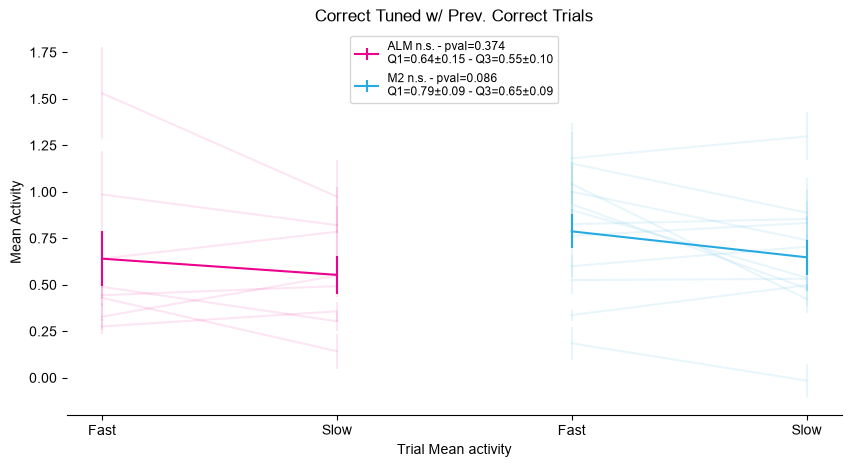

C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(trialMeanActivity)


C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(trialMeanActivity)


,BrainRegion,ShortName,TrialNumber,quantile_idx,0,1,2,3,4,5,6,7,8
0,6,GP4_23_s6_L50_D250_ALM,169,1,0.050807,0.228642,0.228349,0.136991,0.119719,0.105756,0.119003,0.167400,0.214967
1,6,GP4_23_s6_L50_D250_ALM,171,1,0.684825,0.502740,0.367271,0.400435,0.398250,0.384265,0.364130,0.383119,0.376139
2,6,GP4_23_s6_L50_D250_ALM,181,1,0.711070,0.585483,0.514739,0.565458,0.616969,0.681535,0.704263,0.627325,0.559628
3,6,GP4_23_s6_L50_D250_ALM,182,1,-0.021185,-0.075381,-0.071395,-0.008187,-0.004024,-0.003336,-0.013796,-0.010251,-0.012081
4,6,GP4_23_s6_L50_D250_ALM,185,1,0.410573,0.469734,0.499444,0.527685,0.553636,0.600421,0.650566,0.643601,0.627191
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,15,GP4_85_s3_L70_D250_mm2,295,3,1.356862,1.201297,0.721247,0.477579,1.080905,1.388624,1.132561,0.861281,0.087828
2377,15,GP4_85_s3_L70_D250_mm2,296,3,-0.898485,-0.631846,-0.220490,-0.363089,-0.420398,-0.413346,0.011226,0.335878,-0.122060
2378,15,GP4_85_s3_L70_D250_mm2,298,3,1.358148,1.587385,1.752299,2.406775,2.504775,1.305849,1.101899,1.581682,1.458180
2379,15,GP4_85_s3_L70_D250_mm2,299,3,2.182323,2.480246,2.481160,2.046638,1.399074,1.017156,0.598997,0.673319,0.657848


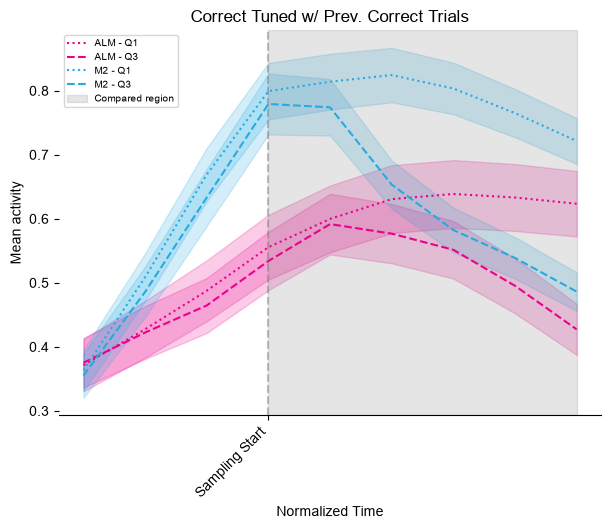

C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior i

,BrainRegion,ShortName,TrialNumber,quantile_idx,mean_activity
0,6,GP4_23_s6_L50_D250_ALM,192,1,2.754375
1,6,GP4_23_s6_L50_D250_ALM,203,1,-0.253792
2,6,GP4_23_s6_L50_D250_ALM,214,1,3.918814
3,6,GP4_23_s6_L50_D250_ALM,236,1,0.122016
4,6,GP4_23_s6_L50_D250_ALM,245,1,-0.049445
...,...,...,...,...,...
632,15,GP4_85_s3_L70_D250_mm2,262,3,0.414956
633,15,GP4_85_s3_L70_D250_mm2,270,3,-0.408718
634,15,GP4_85_s3_L70_D250_mm2,271,3,1.225998
635,15,GP4_85_s3_L70_D250_mm2,274,3,0.782702


BrainRegion: 6
q1_means len: 6 6

BrainRegion: 15
q1_means len: 11 11



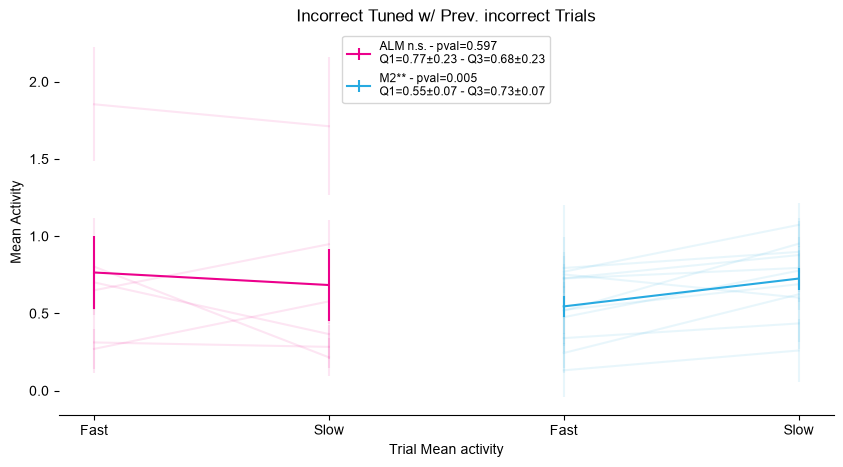

C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).apply(trialMeanActivity)
C:\Users\float\AppData\Local\Temp\ipykernel_21620\1050230578.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior i

,BrainRegion,ShortName,TrialNumber,quantile_idx,0,1,2,3,4,5,6,7,8
0,6,GP4_23_s6_L50_D250_ALM,192,1,1.987622,1.832119,1.851555,2.512997,2.414383,2.631335,2.848286,2.994423,3.124824
1,6,GP4_23_s6_L50_D250_ALM,203,1,0.158212,0.013179,-0.198360,-0.202694,-0.198953,-0.186981,-0.252232,-0.315330,-0.366560
2,6,GP4_23_s6_L50_D250_ALM,214,1,5.004815,4.553965,3.550432,3.658050,3.966774,4.427796,4.419538,3.856762,3.183963
3,6,GP4_23_s6_L50_D250_ALM,236,1,-0.149453,-0.011754,0.135193,0.174928,0.165499,0.135325,0.127517,0.101539,0.027288
4,6,GP4_23_s6_L50_D250_ALM,245,1,0.212321,0.045742,-0.063177,-0.093322,-0.119455,-0.082122,-0.044790,-0.002578,0.045598
...,...,...,...,...,...,...,...,...,...,...,...,...,...
632,15,GP4_85_s3_L70_D250_mm2,262,3,-0.543609,-0.545229,-0.443498,-0.291734,-0.038594,0.260260,0.530575,0.880190,1.149035
633,15,GP4_85_s3_L70_D250_mm2,270,3,-0.391020,-0.260811,-0.164988,-0.306670,-0.505996,-0.466341,-0.348682,-0.345894,-0.478729
634,15,GP4_85_s3_L70_D250_mm2,271,3,1.172755,1.420809,1.490544,1.490757,1.386741,1.185449,1.016634,1.009759,1.266647
635,15,GP4_85_s3_L70_D250_mm2,274,3,2.453279,2.174559,1.985240,1.402874,0.770710,0.819753,0.580082,0.542616,0.580175


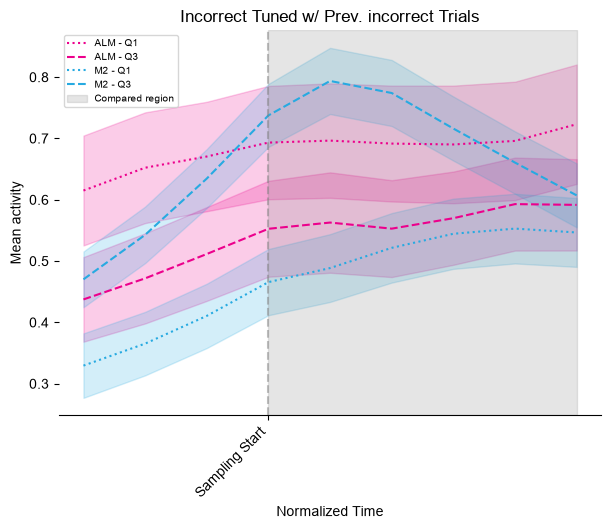

In [46]:
from .common.clr import BrainRegion as BRClr
from scipy import stats

def prevTuning(shortlong_df, normed_sampling_df, normalized_expanded_df,
               active_neurons_sampling_df, bins_count, save_figs):
    sgf_prev_correct = shortlong_df.query(f"data_col == 'PrevChoiceCorrect' and pval <= {PVAL}")
    # display(sgf_prev_correct)
    # display(sgf_prev_correct[["data_col", "prior_data_col", "DVstr"]].value_counts(dropna=False))
    sgf_corr_tuned = sgf_prev_correct[sgf_prev_correct.IsROCLeftTuend == True]
    sgf_incorr_tuned = sgf_prev_correct[sgf_prev_correct.IsROCLeftTuend == False]
    del sgf_prev_correct # Don't reuse by mistake
    # display(sgf_corr_tuned)
    # display(sgf_incorr_tuned)
    # display(active_neurons_sampling_df)
    sgf_corr_tuned = sgf_corr_tuned[sgf_corr_tuned.long_trace_id.isin(active_neurons_sampling_df.trace_id)]
    sgf_incorr_tuned = sgf_incorr_tuned[sgf_incorr_tuned.long_trace_id.isin(active_neurons_sampling_df.trace_id)]
    # display(sgf_corr_tuned)
    # display(sgf_incorr_tuned)

    corr_prev_trials = normalized_expanded_df[normalized_expanded_df.PrevChoiceCorrect == True]
    corr_prev_trials = corr_prev_trials[corr_prev_trials.long_trace_id.isin(sgf_corr_tuned.long_trace_id)]
    incorr_prev_trials = normalized_expanded_df[normalized_expanded_df.PrevChoiceCorrect == False]
    incorr_prev_trials = incorr_prev_trials[incorr_prev_trials.long_trace_id.isin(sgf_incorr_tuned.long_trace_id)]
    # display(corr_prev_trials)
    before, mid, after = normed_sampling_df.iloc[0].epochs_ranges
    bins = [before[0]] + \
            list(np.linspace(mid[0], after[0], bins_count-1, endpoint=True)) + \
            [after[1]+1]
    print("Bins:", len(bins), "=", bins)
    bins = np.array(bins)
    # First bin after sampling start, first bin is animal moving to poke
    second, third = int(round(bins[1])), int(round(bins[2]))
    print("second:", second, "third:", third)
    # second, third = 0, third
    _compareQuantiles(corr_prev_trials, second, third, "Correct Tuned w/ Prev. Correct Trials", save_figs=save_figs)
    _plotMeanActivity(corr_prev_trials, second, third, "Correct Tuned w/ Prev. Correct Trials", save_figs=save_figs)
    _compareQuantiles(incorr_prev_trials, second, third, "Incorrect Tuned w/ Prev. incorrect Trials", save_figs=save_figs)
    _plotMeanActivity(incorr_prev_trials, second, third, "Incorrect Tuned w/ Prev. incorrect Trials", save_figs=save_figs)

def _getTrialMeanActivity(df, raw_start_idx, raw_end_idx, as_single_mean_val):
    '''Get the mean activity of all the (already filtered) neurons within a
    trial '''
    def trialMeanActivity(trial_grp_by):
        mean_trace = trial_grp_by.Raw.loc[:, raw_start_idx:raw_end_idx].mean()
        if as_single_mean_val:
            mean_trace = mean_trace.mean()
        return mean_trace
    df = df.groupby(["BrainRegion", "ShortName", "TrialNumber", "quantile_idx"],
                   ).apply(trialMeanActivity)
    return df

def _plotMeanActivity(df, raw_start_idx, raw_end_idx, title, save_figs):
    q1_df = df[df.quantile_idx == 1]
    q3_df = df[df.quantile_idx == 3]
    # For plotting purposes, start the trace from 0
    q1_means = _getTrialMeanActivity(q1_df, 0, raw_end_idx,
                                     as_single_mean_val=False)
    q3_means = _getTrialMeanActivity(q3_df, 0, raw_end_idx,
                                     as_single_mean_val=False)
    means_df = pd.concat([q1_means, q3_means])
    means_df = means_df.reset_index()
    # means_df = means_df.rename(columns={0:"mean_activity"})
    display(means_df)
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    for br, br_df in means_df.groupby("BrainRegion"):
        clr = BRClr[BrainRegion(br)]
        br_str = str(BrainRegion(br)).split("_")[0]
        for q_idx, ls  in zip([1, 3], [":", "--"]):
            q_df = br_df[br_df.quantile_idx == q_idx]
            # We want to extract only raw-data columns (having names: 0->8)
            q_df = q_df.iloc[:, q_df.columns.map(str).str.isnumeric()]
            # display(q_df)
            mean = q_df.mean()
            sem = q_df.sem()
            # print(br, "Mean:", mean, "SEM:", sem)
            x = np.arange(len(mean))
            ax.plot(x, mean, label=f"{br_str} - Q{q_idx}", color=clr,
                    linestyle=ls)
            ax.fill_between(x, mean-sem, mean+sem, alpha=0.2, color=clr)

    ax.axvspan(raw_start_idx, raw_end_idx, color="gray", alpha=0.2,
               label="Compared region")
    ax.axvline(x=raw_start_idx, color="gray", linestyle="--", alpha=0.5)
    [ax.spines[_dir].set_visible(False) for _dir in ["right", "top", "left"]]
    ax.set_title(title)
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel("Mean activity")
    ax.set_xticks([raw_start_idx])
    ax.set_xticklabels(["Sampling Start"], rotation=45, ha="right")
    ax.legend(fontsize="x-small")
    if save_figs:
        title_save = title.replace("/", "_").replace(".", "")
        plt.savefig(f"{fig_save_prefix}/RT_Stats/PrevChoiceCorrect/trace_{title_save}.svg",
                    bbox_inches='tight')
    plt.show()


def _compareQuantiles(prev_trials_df, raw_start_idx, raw_end_idx, title,
                      save_figs):
    q1_df = prev_trials_df[prev_trials_df.quantile_idx == 1]
    q3_df = prev_trials_df[prev_trials_df.quantile_idx == 3]
    # def trialMeanActivity(df):
    #     return df.Raw.loc[:, raw_start_idx:raw_end_idx].mean().mean()

    # q1_means = q1_df.groupby(["BrainRegion", "ShortName", "TrialNumber", "quantile_idx"],
    #                          as_index=False).apply(trialMeanActivity)
    # q3_means = q3_df.groupby(["BrainRegion", "ShortName", "TrialNumber", "quantile_idx"],
    #                           as_index=False).apply(trialMeanActivity)
    q1_means = _getTrialMeanActivity(q1_df, raw_start_idx, raw_end_idx,
                                     as_single_mean_val=True)
    q3_means = _getTrialMeanActivity(q3_df, raw_start_idx, raw_end_idx,
                                     as_single_mean_val=True)
    means_df = pd.concat([q1_means, q3_means])
    means_df = means_df.reset_index()
    means_df = means_df.rename(columns={0:"mean_activity"})
    display(means_df)

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    import seaborn as sns
    # offset = -0.2
    # br_labels_li = []
    # br_clr_li = []
    OLD = False
    q_x_pos = np.array([1, 2])
    x_offset, X_STEP = 0, 2
    for br, br_df in means_df.groupby("BrainRegion"):
        print("BrainRegion:", br)
        br_clr = BRClr[BrainRegion(br)]
        br_str = str(BrainRegion(br)).split("_")[0]
        # ax.scatter([1+offset]*len(q1), q1.mean_activity, marker=".", label="Q1", color=br_clr)
        # ax.scatter([2+offset]*len(q3), q3.mean_activity, marker=".", label="Q3", color=br_clr)
        # ax.hist(q1.mean_activity, bins=np.arange(-0.2, 5, 0.2), label="Q1", color=br_clr, histtype="step", linestyle="--")
        # ax.hist(q3.mean_activity, bins=np.arange(-0.2, 5, 0.2), label="Q1", color=br_clr, histtype="step")
        if OLD:
            q1 = br_df[br_df.quantile_idx == 1]
            q3 = br_df[br_df.quantile_idx == 3]
            sns.kdeplot(q1.mean_activity, ax=ax, color=br_clr, label="Fast", linestyle=":")#, bins=np.arange(-0.2, 5, 0.2))
            sns.kdeplot(q3.mean_activity, ax=ax, color=br_clr, label="Slow", linestyle="--")#, bins=np.arange(-0.2, 5, 0.2))
            print(br_str, "Len q1:", len(q1), "- Len q3:", len(q3))
            # stats_res = stats.ttest_ind(q1.mean_activity, q3.mean_activity)
            stats_res = stats.mannwhitneyu(q1.mean_activity, q3.mean_activity)
            mean_mean_q1, mean_mean_q3 = (q1.mean_activity.mean(),
                                          q3.mean_activity.mean())
            sem_mean_q1, sem_mean_q3 = (q1.mean_activity.sem(),
                                        q3.mean_activity.sem())
        else:
            q1_means_li, q3_means_li = [], []
            for sess, sess_df in br_df.groupby("ShortName"):
                q1 = sess_df[sess_df.quantile_idx == 1]
                q3 = sess_df[sess_df.quantile_idx == 3]
                q1_mean, q1_sem = q1.mean_activity.mean(), q1.mean_activity.sem()
                q3_mean, q3_sem = q3.mean_activity.mean(), q3.mean_activity.sem()
                ax.errorbar(q_x_pos + x_offset, [q1_mean, q3_mean],
                            yerr=[q1_sem, q3_sem], color=br_clr, alpha=0.1)
                q1_means_li.append(q1_mean)
                q3_means_li.append(q3_mean)
            del q1, q3 # Don't use again by mistake
            q1_means, q3_means = pd.Series(q1_means_li), pd.Series(q3_means_li)
            print("q1_means len:", len(q1_means), len(q3_means))
            print()
            stats_res = stats.ttest_rel(q1_means, q3_means)
            mean_mean_q1, mean_mean_q3 = q1_means.mean(), q3_means.mean()
            sem_mean_q1, sem_mean_q3 = q1_means.sem(), q3_means.sem()
            pval = stats_res.pvalue
            stars = (" n.s." if pval > 0.05 else
                     "*"     if pval > 0.01 else
                     "**"    if pval > 0.001 else
                     "***")
            # print(br_str, pval, stars)
            label = (f"{br_str}{stars} - pval={pval:.3f}\n"
                     f"Q1={mean_mean_q1:.2f}±{sem_mean_q1:.2f} - "
                     f"Q3={mean_mean_q3:.2f}±{sem_mean_q3:.2f}")
            ax.errorbar(q_x_pos + x_offset, [mean_mean_q1, mean_mean_q3],
                        yerr=[sem_mean_q1, sem_mean_q3], color=br_clr,
                        label=label)
        x_offset += X_STEP

    ax.set_xlabel("Trial Mean activity")
    if OLD:
        ax.set_ylabel("KDE")
    else:
        ax.set_ylabel("Mean Activity")
    ax.set_title(title)
    # handles = [plt.Line2D([0], [0], color="gray", ls=":"),
    #            plt.Line2D([0], [0], color="gray", ls="--"),
    #            plt.Line2D([0], [0], color=br_clr_li[0], ls="-"),
    #            plt.Line2D([0], [0], color=br_clr_li[1], ls="-"),
    # ]
    ax.legend(#handles=handles,
            #   labels=["Fast", "Slow",
            #           br_labels_li[0], br_labels_li[1]],
              loc="upper center", fontsize="small")
    ax.set_xticks(list(q_x_pos) + list(X_STEP + q_x_pos))
    ax.set_xticklabels(["Fast", "Slow", "Fast", "Slow"])
    [ax.spines[_dir].set_visible(False) for _dir in ["right", "top", "left"]]
    if save_figs:
        title_save = title.replace("/", "_").replace(".", "")
        path = pathlib.Path(
               f"{fig_save_prefix}/RT_Stats/PrevChoiceCorrect/{title_save}.svg")
        path.parent.parent.mkdir(exist_ok=True)
        path.parent.mkdir(exist_ok=True)
        plt.savefig(path)
    plt.show()

prevTuning(run_data_unnormalized[0].shortlong_df,
           normed_sampling_df=normed_sampling_df,
           # normed_sampling_df=normed_sampling,
           normalized_expanded_df=normalized_expanded_df,
           active_neurons_sampling_df=active_neurons_sampling_df,
           bins_count=BINS_COUNT, save_figs=SAVE_FIGS)

In [47]:
from .twop.balancechange import balanceChange

# TODO: Re-do it again but fix the side
balance_data_col = "ChoiceLeft"
# balance_data_col = "PrevChoiceLeft"
max_count = 3
balance_df = balanceChange(run_data_unnormalized[0].shortlong_df,
                           normalized_expanded_df=normalized_expanded_df,
                           active_neurons_df=active_neurons_sampling_df,
                           bins_count=BINS_COUNT, data_col=balance_data_col,
                           max_count=max_count, pval=PVAL)

PrevOutcomeCount
 3    40822
 1    17643
-1    15738
 2    13583
-2     5047
-3     2316
 0      381
Name: count, dtype: int64
8 [0, np.float64(3.0), np.float64(8.4), np.float64(13.8), np.float64(19.200000000000003), np.float64(24.6), np.float64(30.0), 33]
second: 3 third: 8


PrevOutcomeCount
-2    98
-1    98
 1    98
 2    98
 3    98
-3    94
Name: count, dtype: int64
Trace GP4_23_s6_L50_D250_ALM_0 is not increasing
Trace GP4_23_s6_L50_D250_ALM_67 is not increasing
Trace GP4_23_s6_L50_D250_ALM_71 is not increasing
Trace GP4_23_s7_L50_D250_ALM_108 is not increasing
Trace GP4_23_s7_L50_D250_ALM_168 is not increasing
Trace GP4_23_s7_L50_D250_ALM_184 is not increasing
Trace GP4_23_s7_L50_D250_ALM_197 is not increasing
Trace GP4_23_s7_L50_D250_ALM_20 is not increasing
Trace GP4_23_s7_L50_D250_ALM_26 is not increasing
Trace GP4_23_s7_L50_D250_ALM_33 is not increasing
Trace GP4_23_s7_L50_D250_ALM_38 is not increasing
Trace GP4_23_s7_L50_D250_ALM_43 is not increasing
Trace GP4_23_s7_L50_D250_ALM_7 is not increasing
Trace GP4_23_s7_L50_D250_ALM_80 is not increasing
Trace GP4_23_s8_L50_D250_ALM_126 is not increasing
Trace GP4_23_s8_L50_D250_ALM_185 is not increasing
Trace GP4_23_s8_L50_D250_ALM_20 is not increasing
Trace GP4_23_s8_L50_D250_ALM_206 is not increasin

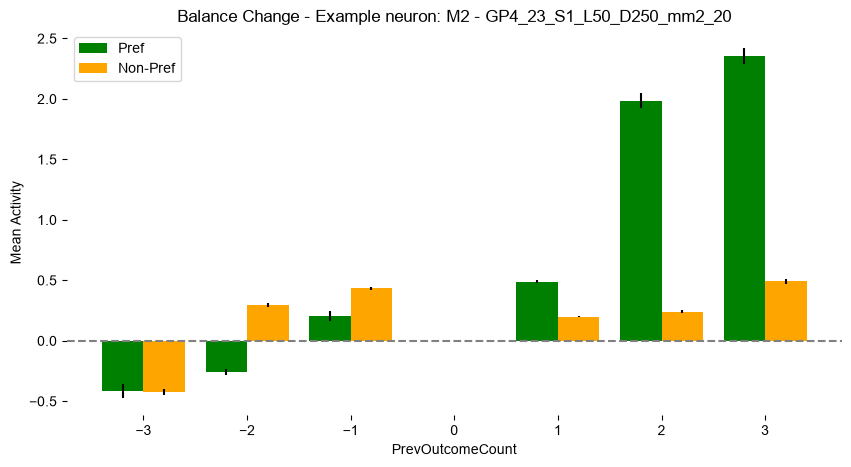

Trace GP4_23_S1_L50_D250_mm2_211 is not increasing
Trace GP4_23_S1_L50_D250_mm2_213 is not increasing
Trace GP4_23_S1_L50_D250_mm2_217 is not increasing


Trace GP4_23_S1_L50_D250_mm2_23 is not increasing
Trace GP4_23_S1_L50_D250_mm2_25 is not increasing
Trace GP4_23_S1_L50_D250_mm2_275 is not increasing
Trace GP4_23_S1_L50_D250_mm2_414 is not increasing
Trace GP4_23_S1_L50_D250_mm2_416 is not increasing
Trace GP4_23_S1_L50_D250_mm2_437 is not increasing
Trace GP4_23_S1_L50_D250_mm2_45 is not increasing
Trace GP4_23_S1_L50_D250_mm2_48 is not increasing
Trace GP4_23_S1_L50_D250_mm2_58 is not increasing
Trace GP4_23_S1_L50_D250_mm2_753 is not increasing
Trace GP4_23_S1_L50_D250_mm2_819 is not increasing
Trace GP4_23_S1_L50_D250_mm2_827 is not increasing
Trace GP4_23_S1_L50_D250_mm2_86 is not increasing
Trace GP4_23_S1_L50_D250_mm2_869 is not increasing
Trace GP4_23_S1_L50_D250_mm2_96 is not increasing
Trace GP4_23_S1_L50_D250_mm2_98 is not increasing
Trace GP4_23_s3_L50_D250_M2_156 is not increasing
Trace GP4_23_s3_L50_D250_M2_160 is not increasing
Trace GP4_23_s3_L50_D250_M2_173 is not increasing
Trace GP4_23_s3_L50_D250_M2_194 is not inc

In [48]:
from .twop.balancechange import plotBalanceChangeSingleNeuron

plotBalanceChangeSingleNeuron(balance_df, save_figs=SAVE_FIGS,
                              fig_save_prefix=fig_save_prefix)

## Reward Rate

In [49]:
def processTrace(trace_df, data_col=None, data_col_pref=None,
                 shuffle=False, track_raw=True):
    if data_col is not None:
        assert data_col_pref is not None
    trace_res_dict = {"PrevOutcomeCount":[],
                      # Other valus that will be added by addOutcomeGroup()
                      }

    def addOrUpdateField(prefix, key, val):
        final_key = f"{prefix}{key}"
        if final_key not in trace_res_dict:
            trace_res_dict[final_key] = []
        trace_res_dict[final_key].append(val)

    def addOutcomeGroup(outcome_group_df, prefix, populate_nans=False):
        if not populate_nans:
            outcome_group_df = outcome_group_df
            outcome_max = outcome_group_df.Raw.max(axis=1)
            max_mean = outcome_max.mean()
            max_median = outcome_max.median()
            max_sem = outcome_max.sem()
            if track_raw:
                raw_mean = outcome_group_df.Raw.mean(axis=0)
                raw_sem = outcome_group_df.Raw.sem(axis=0)
            num_trials = len(outcome_group_df)
            # print("Outcome:", outcome)
            # display(outcome_group_df.Raw)
            # display(outcome_max)
            assert len(outcome_max) == num_trials
        else:
            max_mean = np.nan
            max_median = np.nan
            max_sem = np.nan
            raw_mean = np.nan
            raw_sem = np.nan
            num_trials = np.nan

        addOrUpdateField(prefix, "MaxMean", max_mean)
        addOrUpdateField(prefix, "MaxMedian", max_median)
        addOrUpdateField(prefix, "MaxSEM", max_sem)
        if track_raw:
            addOrUpdateField(prefix, "RawMean", raw_mean)
            addOrUpdateField(prefix, "RawSEM", raw_sem)
        addOrUpdateField(prefix, "NumTrials", num_trials)

    if shuffle:
        trace_df = trace_df.copy()
        trace_df["PrevOutcomeCount"] = trace_df.PrevOutcomeCount.sample(frac=1).values

    for outcome, outcome_df in trace_df.groupby("PrevOutcomeCount"):
        trace_res_dict["PrevOutcomeCount"].append(outcome)
        if data_col is not None:
            pref_df = outcome_df[outcome_df[data_col] == data_col_pref]
            non_pref_df = outcome_df[outcome_df[data_col] != data_col_pref]
            addOutcomeGroup(outcome_df, "All", populate_nans=True)
            addOutcomeGroup(pref_df, "Pref")
            addOutcomeGroup(non_pref_df, "NonPref")
        else:
            addOutcomeGroup(outcome_df, "All")
            addOutcomeGroup(outcome_df, "Pref", populate_nans=True)
            addOutcomeGroup(outcome_df, "NonPref", populate_nans=True)

    return trace_res_dict


def makeBalanceDfForAll(short_long_df, expanded_df, shuffle=False,
                        only_all=False):
    track_raw = not shuffle
    short_long_df = short_long_df[short_long_df.prior_data_col.isnull()]
    short_long_df = short_long_df[short_long_df.DVstr.isnull()]
    short_long_df = short_long_df[short_long_df.pval <= PVAL]

    # display(short_long_df.data_col.value_counts())
    # display(expanded_df.PrevOutcomeCount.value_counts())
    expanded_df = expanded_df.copy()
    expanded_df.loc[expanded_df.PrevOutcomeCount < -MAX_OUTCOME, "PrevOutcomeCount"] = -MAX_OUTCOME
    expanded_df.loc[expanded_df.PrevOutcomeCount >  MAX_OUTCOME, "PrevOutcomeCount"] = MAX_OUTCOME
    # display(expanded_df.PrevOutcomeCount.value_counts())

    res_dict = {"BrainRegion":[],
                "ShortName":[],
                "long_trace_id":[],
                "data_col":[],
                "PrevOutcomeCount":[],
                "is_left_tuned":[],
                "epochs_ranges":[],
                "epochs_names":[],
                # Other valus that will be added by processTrace()
    }

    def invokeProcessTrace(br, sess, trace_id, expanded_trace_df, data_col,
                           is_left_tuned):
        trace_dict = processTrace(expanded_trace_df, data_col,
                                  data_col_pref=is_left_tuned,
                                  shuffle=shuffle, track_raw=track_raw)
        for key, val in trace_dict.items():
            if key not in res_dict:
                res_dict[key] = []
            res_dict[key] += val

        len_res = len(trace_dict["PrevOutcomeCount"])
        res_dict["BrainRegion"] += [br]*len_res
        res_dict["ShortName"] += [sess]*len_res
        res_dict["long_trace_id"] += [trace_id]*len_res
        res_dict["data_col"] += [data_col]*len_res
        res_dict["is_left_tuned"] += [is_left_tuned]*len_res
        if len(expanded_trace_df):
            epochs_ranges = expanded_trace_df.epochs_ranges.iloc[0]
            epochs_names = expanded_trace_df.epochs_names.iloc[0]
        else:
            epochs_ranges, epochs_names = np.nan, np.nan
        res_dict["epochs_ranges"] += [epochs_ranges]*len_res
        res_dict["epochs_names"] += [epochs_names]*len_res

    # Run for all traces
    if not shuffle: print("All traces")
    for br, expanded_br_df in expanded_df.groupby("BrainRegion"):
        for sess, sess_df in expanded_br_df.groupby("ShortName"):
            for trace_id, trace_df in sess_df.groupby("long_trace_id"):
                invokeProcessTrace(br, sess=sess,
                                   trace_id=trace_id,
                                   expanded_trace_df=trace_df,
                                   data_col=None,
                                   is_left_tuned=None)

    if not only_all:
        for data_col, sgf_data_col_df in short_long_df.groupby("data_col"):
            if not shuffle: print("Data col:", data_col)
            for br, br_df in sgf_data_col_df.groupby("BrainRegion"):
                if not shuffle: print("   BrainRegion:", br)
                for sess, sess_df in br_df.groupby("ShortName"):
                    for _idx, trace_row in sess_df.iterrows():
                        # display(trace_row)
                        trace_id = trace_row.long_trace_id
                        expanded_trace_df = expanded_df[expanded_df.long_trace_id == trace_id]
                        is_left_tuned = trace_row.IsROCLeftTuend
                        invokeProcessTrace(br, sess=sess, trace_id=trace_id,
                                           expanded_trace_df=expanded_trace_df,
                                           data_col=data_col,
                                           is_left_tuned=is_left_tuned)

    return pd.DataFrame(res_dict)

# The structure of this df is annoying. A trace exists as either a data col or
# not. For data col, it exists for pref/non-pref but not for all. For all, it
# exists only for all.
MAX_OUTCOME = 3
balance_df_all = makeBalanceDfForAll(run_data_unnormalized[0].shortlong_df,
                                     expanded_df=normalized_expanded_df,
                                     only_all=False)

All traces


Data col: ChoiceLeft
   BrainRegion: 6


   BrainRegion: 15


Data col: IsEasy
   BrainRegion: 6


   BrainRegion: 15


...

   BrainRegion: 15


Data col: PrevChoiceLeft
   BrainRegion: 6


   BrainRegion: 15


Data col: PrevIsEasy
   BrainRegion: 6


   BrainRegion: 15


In [50]:
from .twop.dataload import dataPath
# Cells 71-76 build 1,000-iteration shuffle nulls: over 6 hours, none of it
# saved under data/. Their only consumer, printStats in cell 77, has
# shuffle_stats_df commented out. Set True to rebuild them anyway.
RUN_UNUSED_SHUFFLES = False

from tqdm.auto import tqdm
from pathlib import Path

def shuffleOnlyAll(short_long_df, expanded_df, num_shuffles, save_fp):
    save_fp = Path(save_fp)
    if save_fp.exists():
        print("File already exists:", save_fp)
        with open(save_fp, 'rb') as f:
            try:
                df_li = pickle.load(f)
            except:
                print("Error loading pickle file. Recreating it.")
                df_li = []
        start_idx = len(df_li)
    else:
        df_li = []
        start_idx = 0
    change_happened = False
    for idx in tqdm(range(start_idx, num_shuffles)):
        change_happened = True
        # print("Shuffle:", idx)
        shuffled_df = makeBalanceDfForAll(short_long_df, expanded_df,
                                           shuffle=True, only_all=True)
        shuffled_df["ShuffleIdx"] = idx
        df_li.append(shuffled_df)
        if idx % 10 == 9:
            print("Saving intermediate result:", idx)
            with open(save_fp, 'wb') as f:
                pickle.dump(df_li, f)
    if change_happened:
        print("Saving final result")
        with open(save_fp, 'wb') as f:
            pickle.dump(df_li, f)
    return pd.concat(df_li)

if RUN_UNUSED_SHUFFLES:
    shuffle_fp = dataPath("balance_df_all_shuffled_only_all.pkl")
    balance_df_all_shuffled_only_all = shuffleOnlyAll(run_data_unnormalized[0].shortlong_df,
                                                      expanded_df=normalized_expanded_df,
                                                      num_shuffles=1_000,
                                                      save_fp=shuffle_fp)


In [51]:
from .twop.dataload import dataPath
from tqdm.auto import tqdm

def makeBalanceDfForAllShuffled(short_long_df, expanded_df, num_shuffles):
    dfs_li = []
    for i in tqdm(range(num_shuffles), desc="Shuffling"):
        balance_df = makeBalanceDfForAll(short_long_df, expanded_df, shuffle=True)
        balance_df["ShuffleIdx"] = i
        dfs_li.append(balance_df)
    return pd.concat(dfs_li).reset_index(drop=True)

if RUN_UNUSED_SHUFFLES:
    _FP = dataPath("balance_df_all_shuffled.pkl")
    if os.path.exists(_FP):
        print("Loading balance_df_all_shuffled")
        with open(_FP, 'rb') as f:
            balance_df_all_shuffled = pickle.load(f)
    else:
        balance_df_all_shuffled = makeBalanceDfForAllShuffled(run_data_unnormalized[0].shortlong_df,
                                                            expanded_df=normalized_expanded_df, num_shuffles=1_000)
        with open(_FP, 'wb') as f:
            pickle.dump(balance_df_all_shuffled, f)


In [52]:
if RUN_UNUSED_SHUFFLES:
    balance_df_all_shuffled = pd.concat([balance_df_all_shuffled,
                                         balance_df_all_shuffled_only_all])


In [53]:
if RUN_UNUSED_SHUFFLES:
    balance_df_all_shuffled["ShortName"] = balance_df_all_shuffled.long_trace_id.str.rsplit("_", n=1).str[0]
    balance_df_all_shuffled


In [54]:
# One panel of this loop is published (Figure 6C), but the example's ID is
# not recorded -- so a paper-only run skips the loop rather than
# writing every neuron. Pin the ID to bring the panel back.
def _plotTraceBalance(br_str, trace_id, trace_df, data_col, plot, save_figs):
    plot_all_cols = False
    if data_col == "All":
        color_all = "gray"
        plot_all_cols = True
    elif data_col == "ChoiceLeft":
        color_pref = "green"
        color_non_pref = "orange"
    elif data_col == "PrevChoiceLeft":
        color_pref = "yellow"
        color_non_pref = "purple"
    elif data_col == "PrevChoiceCorrect":
        color_pref = "magenta"
        color_non_pref = "cyan"
    else:
        color_pref = "gray"
        color_non_pref = "darkgray"

    fig, all_axs = plt.subplots(1, 1 + MAX_OUTCOME*2,  figsize=(25, 3))
    ax_bar, *ax_raws = all_axs
    prev_outcome_counts = np.concatenate([np.arange(-MAX_OUTCOME, 0),
                                          np.arange(1, MAX_OUTCOME+1)])
    assert len(prev_outcome_counts) == len(ax_raws)

    if plot_all_cols:
        ax_bar.bar(trace_df.PrevOutcomeCount, trace_df.AllMaxMean,
                   yerr=trace_df.AllMaxSEM, width=0.8, color=color_all, label="All")
    else:
        ax_bar.bar(trace_df.PrevOutcomeCount - 0.2, trace_df.PrefMaxMean,
                   yerr=trace_df.PrefMaxSEM, width=0.4, color=color_pref, label="Pref")
        ax_bar.bar(trace_df.PrevOutcomeCount + 0.2, trace_df.NonPrefMaxMean,
                   yerr=trace_df.NonPrefMaxSEM, width=0.4, color=color_non_pref, label="Non-Pref")
    ax_bar.set_xlabel("PrevOutcomeCount")
    ax_bar.set_ylabel("Max Activity")
    # ax_bar.set_title(f"Balance Change - {br_str} - {trace_id} - {data_col}")
    ax_bar.legend()
    ax_bar.axhline(0, ls="--", c="gray")
    ax_bar.set_xticks(prev_outcome_counts)

    len_raw_col = "AllRawMean" if plot_all_cols else "PrefRawMean"
    len_raw = len(trace_df[len_raw_col].iloc[0])
    x = np.arange(len_raw)


    def plotRaws(prev_outcome_count, ax_raw, used_df, color, prefix):
        used_df = used_df[used_df.PrevOutcomeCount == prev_outcome_count]
        assert len(used_df) <= 1, f"Expected 1 row for PrevOutcomeCount={prev_outcome_count}, got {len(used_df)}"
        if len(used_df) == 0:
            return
        row = used_df.iloc[0]
        len_used_df = len(used_df)

        num_trials = row[f"{prefix}NumTrials"]
        label = f"{prefix} - PrevCount={row.PrevOutcomeCount} - #Trials={num_trials}"
        ax_raw.plot(x, row[f"{prefix}RawMean"], color=color,
                    label=label)
        y_upper = row[f"{prefix}RawMean"] + row[f"{prefix}RawSEM"]
        y_lower = row[f"{prefix}RawMean"] - row[f"{prefix}RawSEM"]
        ax_raw.fill_between(x, y_lower, y_upper, alpha=0.1, color=color)
        return y_lower.min(), y_upper.max()

    epochs_ranges = trace_df.epochs_ranges[trace_df.epochs_ranges.notnull()]
    epochs_ranges = set(tuple(_rng) for _rng in epochs_ranges)
    assert len(epochs_ranges) == 1, "Expected all epochs_ranges to be the same"
    epochs_ranges = epochs_ranges.pop()
    epochs_names = trace_df.epochs_names[trace_df.epochs_names.notnull()].iloc[0]
    x_ticks = []
    x_labels = []
    for (epoch_name, (_start, end)) in zip(epochs_names[1:], epochs_ranges[:-1]):
        x_ticks.append(end)
        x_labels.append(epoch_name)

    y_min, y_max = np.inf, -np.inf
    y_lims2 = None
    for prev_outcome_count, ax_raw in zip(prev_outcome_counts, ax_raws):
        if plot_all_cols:
            all_df = trace_df[trace_df.AllMaxMean.notnull()]
            # print("All:", len(all_df))
            y_lims = plotRaws(prev_outcome_count, ax_raw, all_df, color_all, "All")
        else:
            pref_df = trace_df[trace_df.PrefMaxMean.notnull()]
            # print("Len pref:", len(pref_df))
            y_lims = plotRaws(prev_outcome_count, ax_raw, pref_df, color_pref, "Pref")
            non_pref_df = trace_df[trace_df.NonPrefMaxMean.notnull()]
            # print("Len non pref:", len(non_pref_df))
            y_lims2 = plotRaws(prev_outcome_count, ax_raw, non_pref_df, color_non_pref, "NonPref")
        if y_lims is not None:
            y_min = min(y_min, y_lims[0])
            y_max = max(y_max, y_lims[1])
            y_lims = None
        if y_lims2 is not None:
            y_min = min(y_min, y_lims2[0])
            y_max = max(y_max, y_lims2[1])
            y_lims2 = None
        for x_tick in x_ticks:
            ax_raw.axvline(x_tick, ls="--", color="gray", alpha=0.7)
        ax_raw.set_xticks(x_ticks)
        ax_raw.set_xticklabels(x_labels, rotation=45, ha="right")
        ax_raw.set_xlabel("Normalized Time")
        ax_raw.set_ylabel("Mean Activity")
        title_str = "Correct" if prev_outcome_count > 0 else "Incorrect"
        ax_raw.set_title(f"{abs(prev_outcome_count)} {title_str} Trials")
        ax_raw.legend(fontsize="xx-small")
    for ax_raw in ax_raws:
        ax_raw.set_ylim(y_min*1.1, y_max*1.1)
    fig.suptitle(f"Balance Change - {br_str} - {trace_id} - {data_col}",
                 y=1.05)
    for ax in all_axs:
        ax.spines[["right", "top", "left", "bottom"]].set_visible(False)
    if save_figs:
        save_path = pathlib.Path(
                        f"{fig_save_prefix}/RewardRate/IncNeuron/"
                        f"BalanceChangeCurChoiceEx_{trace_id}_{data_col}.svg")
        save_path.parent.parent.mkdir(exist_ok=True)
        save_path.parent.mkdir(exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    if plot:
        plt.show()
    else:
        plt.close()

def plotIncrementingChange(balance_df_all, #br_totals,
                           sess_totals,
                           plot, save_figs):
    balance_df_all = balance_df_all[balance_df_all.PrevOutcomeCount != 0]
    # set_inc_neurons = set()
    inc_by_data_col_br = {"BrainRegion":[], "ShortName":[], "trace_id":[],
                          "sess_total_neurons":[], #"set_unique":[]
                          "data_col":[],
                          }
    for data_col, data_df in balance_df_all.groupby("data_col", dropna=False):
        if not isinstance(data_col, str) and np.isnan(data_col):
            data_col = "All"
        for sess, sess_total_neurons in sess_totals.items():
                # sess_total_neurons = sess_totals[sess]
                sess_df = data_df[data_df.ShortName == sess]
                if len(sess_df) == 0:
                    # Handle special case, where we need to count the total
                    sess_df = balance_df_all[balance_df_all.ShortName == sess]
                    br = sess_df.BrainRegion.iloc[0]
                    br_str = str(BrainRegion(br)).split("_")[0]
                    inc_by_data_col_br["BrainRegion"].append(br_str)
                    inc_by_data_col_br["ShortName"].append(sess)
                    inc_by_data_col_br["trace_id"].append(np.nan)
                    inc_by_data_col_br["data_col"].append(data_col)
                    inc_by_data_col_br["sess_total_neurons"].append(sess_total_neurons)
                    continue
                br = sess_df.BrainRegion.iloc[0]
                br_str = str(BrainRegion(br)).split("_")[0]
                for trace_id, trace_df in sess_df.groupby("long_trace_id"):
                    trace_df = trace_df.sort_values("PrevOutcomeCount")
                    CHECK_INCREMENT = True
                    if CHECK_INCREMENT:
                        # Check if the preferred activity is increasing
                        if data_col == "All":
                            pref_max = trace_df.AllMaxMean
                        else:
                            pref_max = trace_df.PrefMaxMean

                        is_increasing = pref_max.diff().dropna().gt(0).all()
                        is_decreasing = False #pref_max.diff().dropna().lt(0).all()
                        # TODO: IF it's all, check if it's increasing or decreasing
                        if not is_increasing and not is_decreasing:
                            # print(f"Trace {trace_id} is not increasing")
                            continue
                        # set_inc_neurons.add(trace_id)
                        # # inc_by_data_col_br[data_col][br_str]["inc"] += 1
                        # inc_by_data_col_br[data_col][br_str]["set"].add(trace_id)
                        # # print("Pref Max:", pref_max)
                        inc_by_data_col_br["BrainRegion"].append(br_str)
                        inc_by_data_col_br["ShortName"].append(sess)
                        inc_by_data_col_br["trace_id"].append(trace_id)
                        inc_by_data_col_br["data_col"].append(data_col)
                        inc_by_data_col_br["sess_total_neurons"].append(sess_total_neurons)
                    if not plot and not save_figs:
                        continue
                    _plotTraceBalance(br_str, trace_id, trace_df, data_col,
                                    plot, save_figs)
                    # break

    inc_by_data_col_df = pd.DataFrame(inc_by_data_col_br)
    # display(inc_by_data_col_df)
    return _getStats(inc_by_data_col_df, sess_totals)

def _getStats(inc_by_data_col_df, sess_totals):
    stats_dict = {"data_col":[],
                  "BrainRegion":[],
                  "ShortName":[],
                  "total":[],
                  "inc":[],
                  "prcnt":[],
                  }

    def processDictItems(br, sess, data_col, total, inc):
        prcnt = (inc / total) * 100
        stats_dict["BrainRegion"].append(br)
        stats_dict["ShortName"].append(sess)
        stats_dict["data_col"].append(data_col)
        stats_dict["total"].append(total)
        stats_dict["inc"].append(inc)
        stats_dict["prcnt"].append(prcnt)

    sess_to_br = {sess:sess_df.BrainRegion.iloc[0]
                  for sess, sess_df in inc_by_data_col_df.groupby("ShortName")}

    for sess, br in sess_to_br.items():
        sess_total = sess_totals[sess]
        sess_df = inc_by_data_col_df[inc_by_data_col_df.ShortName == sess]
        if len(sess_df) != 0:
            sess_inc = sess_df.trace_id.nunique()
        else:
            sess_inc = 0
        processDictItems("Global", sess, "Global", sess_total, sess_inc)
        processDictItems(br, sess, "Global", sess_total, sess_inc)



    # for data_col, data_col_dict in inc_by_data_col_br.items():
    for data_col, data_col_df in inc_by_data_col_df.groupby("data_col"):
        for sess, br in sess_to_br.items():
            sess_total = sess_totals[sess]
            sess_df = data_col_df[data_col_df.ShortName == sess]
            if len(sess_df) != 0:
                sess_inc = sess_df.trace_id.nunique()
            else:
                sess_inc = 0
            processDictItems("Global", sess, data_col, sess_total, sess_inc)
            processDictItems(br, sess, data_col, sess_total, sess_inc)


    stats_df = pd.DataFrame(stats_dict)
    # display(stats_df)
    return stats_df

# TODO: IF it's 'ALL', check if it's increasing or decreasing
# _br_totals = {br:br_df.long_trace_id.nunique() for br, br_df in normalized_expanded_df.groupby("BrainRegion")}
_sess_totals = {sess:sess_df.long_trace_id.nunique()
                for sess, sess_df in normalized_expanded_df.groupby("ShortName")}
stats_df = plotIncrementingChange(balance_df_all, #br_totals=_br_totals,
                                  sess_totals=_sess_totals,
                                  plot=False, save_figs=(SAVE_FIGS and not PAPER_FIGURES_ONLY))
stats_df

C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


...

C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


C:\Users\float\AppData\Local\Temp\ipykernel_21620\2601036509.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raw.legend(fontsize="xx-small")


,data_col,BrainRegion,ShortName,total,inc,prcnt
0,Global,Global,GP4_23_S1_L50_D250_mm2,165,16,9.696970
1,Global,M2,GP4_23_S1_L50_D250_mm2,165,16,9.696970
2,Global,Global,GP4_23_s3_L50_D250_M2,122,5,4.098361
3,Global,M2,GP4_23_s3_L50_D250_M2,122,5,4.098361
4,Global,Global,GP4_23_s6_L50_D250_ALM,77,11,14.285714
...,...,...,...,...,...,...
317,PrevIsEasy,ALM,GP4_85_s9_L70_D250_ALM,62,1,1.612903
318,PrevIsEasy,Global,gp4_81_S5_L50_D250_ALM,42,1,2.380952
319,PrevIsEasy,ALM,gp4_81_S5_L50_D250_ALM,42,1,2.380952
320,PrevIsEasy,Global,gp4_81_S8_L65_D250_ALM,42,0,0.000000


In [55]:
from .twop.dataload import dataPath
from tqdm.auto import tqdm
def incrementingChangeShuffle(shuffle_df):
    stats_df_li = []
    for shuffle_idx, shuffle_df in tqdm(shuffle_df.groupby("ShuffleIdx")):
        stats_df = plotIncrementingChange(shuffle_df,
                                          #br_totals=_br_totals,
                                          sess_totals=_sess_totals,
                                          plot=False, save_figs=False)
        stats_df["ShuffleIdx"] = shuffle_idx
        stats_df_li.append(stats_df)
    return pd.concat(stats_df_li).reset_index(drop=True)

if RUN_UNUSED_SHUFFLES:
    _FP = dataPath("stats_df_shuffled.pkl")
    if os.path.exists(_FP):
        print("Loading stats_df_shuffled")
        with open(_FP, 'rb') as f:
            stats_df_shuffled = pickle.load(f)
    else:
        print("Generating new stats_df_shuffled")
        stats_df_shuffled = incrementingChangeShuffle(balance_df_all_shuffled)
        with open(_FP, 'wb') as f:
            pickle.dump(stats_df_shuffled, f)


In [56]:
import statistics as stdlib_statistics
import scipy.stats as stats
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import norm

def _getShuffleStr(br, data_col, prcnt_real_mean, total, shuffle_stats_df, num_shuffles):

    shuffle_rows = shuffle_stats_df[(shuffle_stats_df.BrainRegion == br) &
                                    (shuffle_stats_df.data_col == data_col)]
    # TODO: FIX THIS
    shuffle_res = shuffle_rows.groupby("ShuffleIdx").apply(_computeBRData)
    if not len(shuffle_res):
        return " - TEMP>>>> No shuffle rows", None, None
    assert len(shuffle_res) == num_shuffles, f"Len shuffle rows: {len(shuffle_res)}"
    display(shuffle_rows[shuffle_rows.ShuffleIdx == 0])
    shuffle_res = shuffle_res.reset_index(drop=True)
    shuffle_res = shuffle_res.apply(pd.Series)
    inc_pooled_means, total_pooled_means, prcnt_mean_means, prcnt_sem_means = \
        shuffle_res[0].values, shuffle_res[1].values, shuffle_res[2].values, shuffle_res[3].values

    inc_mean, inc_std = inc_pooled_means.mean(), inc_pooled_means.std()
    total_mean, total_std = total_pooled_means.mean(), total_pooled_means.std()
    prcnt_mean, prcnt_std = prcnt_mean_means.mean(), prcnt_mean_means.std()
    assert np.isclose(total_mean, total), f"Total mean: {total_mean}, total: {total}"

    _str = (f" | Shuffle {inc_mean:.2f} ± {inc_std:.2f} / {total}"
            f" ({prcnt_mean:.2f}±{prcnt_std:.2f})")

    # Compute z-score and p-value using normal distribution
    mean = prcnt_mean
    std = prcnt_std
    if np.isclose(std, 0):
        return (f" - TEMP>>>> zero std in shuffle: len shuffle: {len(shuffle_res)}",
                None, None)

    z_score = (prcnt_real_mean - mean) / std
    pval = 2 * norm.sf(abs(z_score))  # Two-tailed p-value

    # Significance level
    if pval < 0.01:
        pval_str = "***"
    elif pval < 0.05:
        pval_str = "**"
    elif pval < 0.1:
        pval_str = "*"
    else:
        pval_str = "n.s."

    _str += f" - Percent mean zscore: {z_score:.2f} {pval_str}"

    return _str, pval, pval_str


def _computeBRData(br_df):
    inc_pooled = br_df.inc.sum()
    total_pooled = br_df.total.sum()
    prcnt_mean = br_df.prcnt.mean()
    prcnt_sem = br_df.prcnt.sem()
    return inc_pooled, total_pooled, prcnt_mean, prcnt_sem

def printStats(stats_df, shuffle_stats_df=None, save_figs=False):
    if shuffle_stats_df is not None:
        num_shuffles = shuffle_stats_df.ShuffleIdx.nunique()
        print(f"Num shuffles: {num_shuffles:,}")
    def _printStats(data_col, br, br_df, print_br=True):
        header_str = br if print_br else br_df.data_col.iloc[0]
        inc_pooled, total_pooled, prcnt_mean, prcnt_sem = _computeBRData(br_df)
        print(f"    {header_str}: {inc_pooled}/{total_pooled} ({prcnt_mean:.2f}%) ± {prcnt_sem:.2f}", end="")

        if shuffle_stats_df is not None:
            shuffle_str, pval, pval_str = _getShuffleStr(br, data_col, prcnt_mean, total_pooled,
                                                         shuffle_stats_df,
                                                         num_shuffles)
            print(shuffle_str, end="")
        else:
            pval = -1 #None
            pval_str = ""

        print()
        if data_col != "Global":
            return

        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        label_shuffle = (f"\nShuffle pval={pval:.3f} {pval_str}" if shuffle_stats_df is not None else
                         "")
        ax.pie([prcnt_mean, 100 - prcnt_mean],
               labels=[f"{prcnt_mean:.2f}% ± {prcnt_sem:.2f}{label_shuffle}",
                       None],
               colors=["#64C7C2", "gray"], startangle=90, counterclock=False,
               explode=[0.1, 0], labeldistance=.8,
               textprops={"ha": "left"})
        ax.axis("equal")
        if data_col == "Global":
            data_col = "Across all data cols + non-sgf"
        ax.set_title(f"{br} - Reward Rate Neurons - {data_col}")
        ax.spines[["right", "top", "left", "bottom"]].set_visible(False)
        if save_figs:
            title_save = f"{br} data_col={data_col} "
            plt.savefig(f"{fig_save_prefix}/RewardRate_Pie_{title_save}.svg")
        plt.show()


    # Start with global
    # print("Global")
    # for data_col, data_col_df in stats_df[stats_df.BrainRegion == "Global"].groupby("data_col"):
    #     _printStats(data_col, "Global", data_col_df, print_br=False)

    for br, br_df in stats_df[stats_df.BrainRegion != "Global"].groupby("BrainRegion"):
        print(br)
        for data_col, data_col_df in br_df.groupby("data_col"):
            _printStats(data_col, br, data_col_df, print_br=False)


printStats(stats_df, shuffle_stats_df=None, #shuffle_stats_df=stats_df_shuffled,
           save_figs=False)

ALM
    All: 8/609 (1.34%) ± 0.56
    ChoiceLeft: 4/609 (0.93%) ± 0.55
    Global: 57/609 (9.79%) ± 2.09


    IsEasy: 2/609 (0.26%) ± 0.26
    PrevChoiceCorrect: 40/609 (6.84%) ± 1.40
    PrevChoiceLeft: 10/609 (1.67%) ± 0.48
    PrevIsEasy: 4/609 (0.66%) ± 0.34
M2
    All: 2/837 (0.30%) ± 0.24
    ChoiceLeft: 1/837 (0.05%) ± 0.05
    Global: 106/837 (15.25%) ± 3.87


    IsEasy: 0/837 (0.00%) ± 0.00
    PrevChoiceCorrect: 86/837 (12.51%) ± 3.65
    PrevChoiceLeft: 25/837 (3.07%) ± 1.03
    PrevIsEasy: 2/837 (0.31%) ± 0.31


# Cityscape Figure

In [57]:
import pandas as pd

_data_col = "ChoiceLeft"
def nonQuantiledStats(non_q_df):
  non_q_df = non_q_df[non_q_df.data_col == _data_col]
  non_q_df = non_q_df[non_q_df.DVstr.isnull()]
  non_q_df = non_q_df[non_q_df.pval <= PVAL]
  non_q_df = non_q_df.drop_duplicates(["long_trace_id"])
  return non_q_df


## Current-Trial Left-vs-Right

In [58]:
from .twop.plottuning import samplingSlowVsFast, TrajectoryTuningPlot
# Treat warnings as errors
import warnings
# warnings.filterwarnings("error")
# Re-enable warnings
warnings.filterwarnings("default")




sep_side = False
def plotTrajectory(as_weight, weight_only_first_last, plot_region_trace,
                   plot_single_pts, plot_linear_fit=False,
                   combine_strategies=False, split_difficulties=False,
                   save_fig=False):
    # display(stats_df)
    combine_brain_regions = False
    # combine_sides = True
    stats_df = nonQuantiledStats(run_data_unnormalized[0].shortlong_df)
    dv_str_list = [None] if not split_difficulties else ["Easy", "Med", "Hard"]
    for dv_str in dv_str_list:
      for choice_outcome, choice_descrp in [(None, "both correct and incorrect"),
                                            #(True, "Correct"),
                                            #(False, "Incorrect"),
                                            ]:
        for prev_choice_outcome, prev_choice_descrp in [(None, ""),
                                                        #(True, "previous correct trials"),
                                                        #(False, "previous incorrect trials"),
                                                        ]:
          for combine_sides in [True,
                                #False
                                ]:

          # label = f"Choice for Only Active Movement Where Choices are {choice_descrp}"
            label = f"Hist Choice ZScored Where Choices are {choice_descrp}"
            sub_norm_expanded_df = normalized_expanded_df#norm_expanded_df
            if choice_outcome is not None:
              sub_norm_expanded_df = sub_norm_expanded_df[sub_norm_expanded_df.ChoiceCorrect == choice_outcome]
            label += " sides combined" if combine_sides else " sides separated"
            # sub_norm_expanded_df = sub_norm_expanded_df[norm_expanded_df.calcStimulusTime <= 3]
            if dv_str in ["Easy", "Med", "Hard"]:
              label = f"{label} for only {dv_str} trials"
              sub_norm_expanded_df = sub_norm_expanded_df[sub_norm_expanded_df.DVstr == dv_str]
            else:
              label = f"{label} for all difficulties"
            #
            if prev_choice_outcome is not None:
              label = f"{label} for {prev_choice_descrp}"
              sub_norm_expanded_df = sub_norm_expanded_df[sub_norm_expanded_df.PrevChoiceCorrect == prev_choice_outcome]
            # label = "Same Len - " + label
            skip_qidx2 = True
            #y_lim = (-20, 130) if as_weight else (-0.2, 1.5)
            y_lim = (-50, 200) if as_weight else (None, None)
            combine_in_single_plot = as_weight and weight_only_first_last
            if as_weight and weight_only_first_last and not combine_sides:
              combine_in_single_plot = False # This breaks, fix it later

            tuning_plotter = TrajectoryTuningPlot(method="mean",
                                                  combine_in_single_plot=combine_in_single_plot,
                                                  skip_qidx2=skip_qidx2,
                                                  combine_sides=combine_sides,
                                                  combine_brain_regions=combine_brain_regions,
                                                  plot_all=combine_strategies,
                                                  plt_is_no_quantiles=combine_strategies,
                                                  plot_non_sgf=plot_region_trace,
                                                  # y_lims=(-0.01, 50),
                                                  #y_lims=(50, 150),
                                                  y_lims=y_lim,
                                                  label=label, plot_sem=True,
                                                  bins_count=BINS_COUNT,
                                                  neuronFiringBinFn=neurons_iqr_df_all_trials,
                                                  as_weight=as_weight,
                                                  plot_weight_only_first_last=weight_only_first_last,
                                                  plt_single_pts=plot_single_pts,
                                                  plt_linear_fit=plot_linear_fit)
            extra_kwargs = dict(iter_col=None) if combine_strategies else dict()
            samplingSlowVsFast(stats_df=stats_df.copy(),
                                src_activitiy_df=sub_norm_expanded_df.copy(),
                                tuning_plotter=tuning_plotter,
                                sep_brain_region=not combine_brain_regions,
                                sep_side=not combine_sides,
                                left_tune_col="IsROCLeftTuend", pval=PVAL,
                                skip_qidx2=skip_qidx2,
                                data_col=_data_col,
                                sep_2_groups_col=_data_col,
                                fig_save_prefix=fig_save_prefix,
                                save_fig=save_fig,
                                **extra_kwargs)


is_left_choice_tuned
NaN    84040
1.0    16200
0.0    15675
Name: count, dtype: int64

is_left_choice_tuned
NaN    83999
1.0    16174
0.0    15663
Name: count, dtype: int64

is_left_choice_tuned
NaN    83927
1.0    16170
0.0    15648
Name: count, dtype: int64

Len preferred_dir_df: 4109 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 3798 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Col idx: 0 Choice dir: None last_dir: -1
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

Len preferred_dir_df: 3406 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 3986 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Col idx: 1 Choice dir: None last_dir: None
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

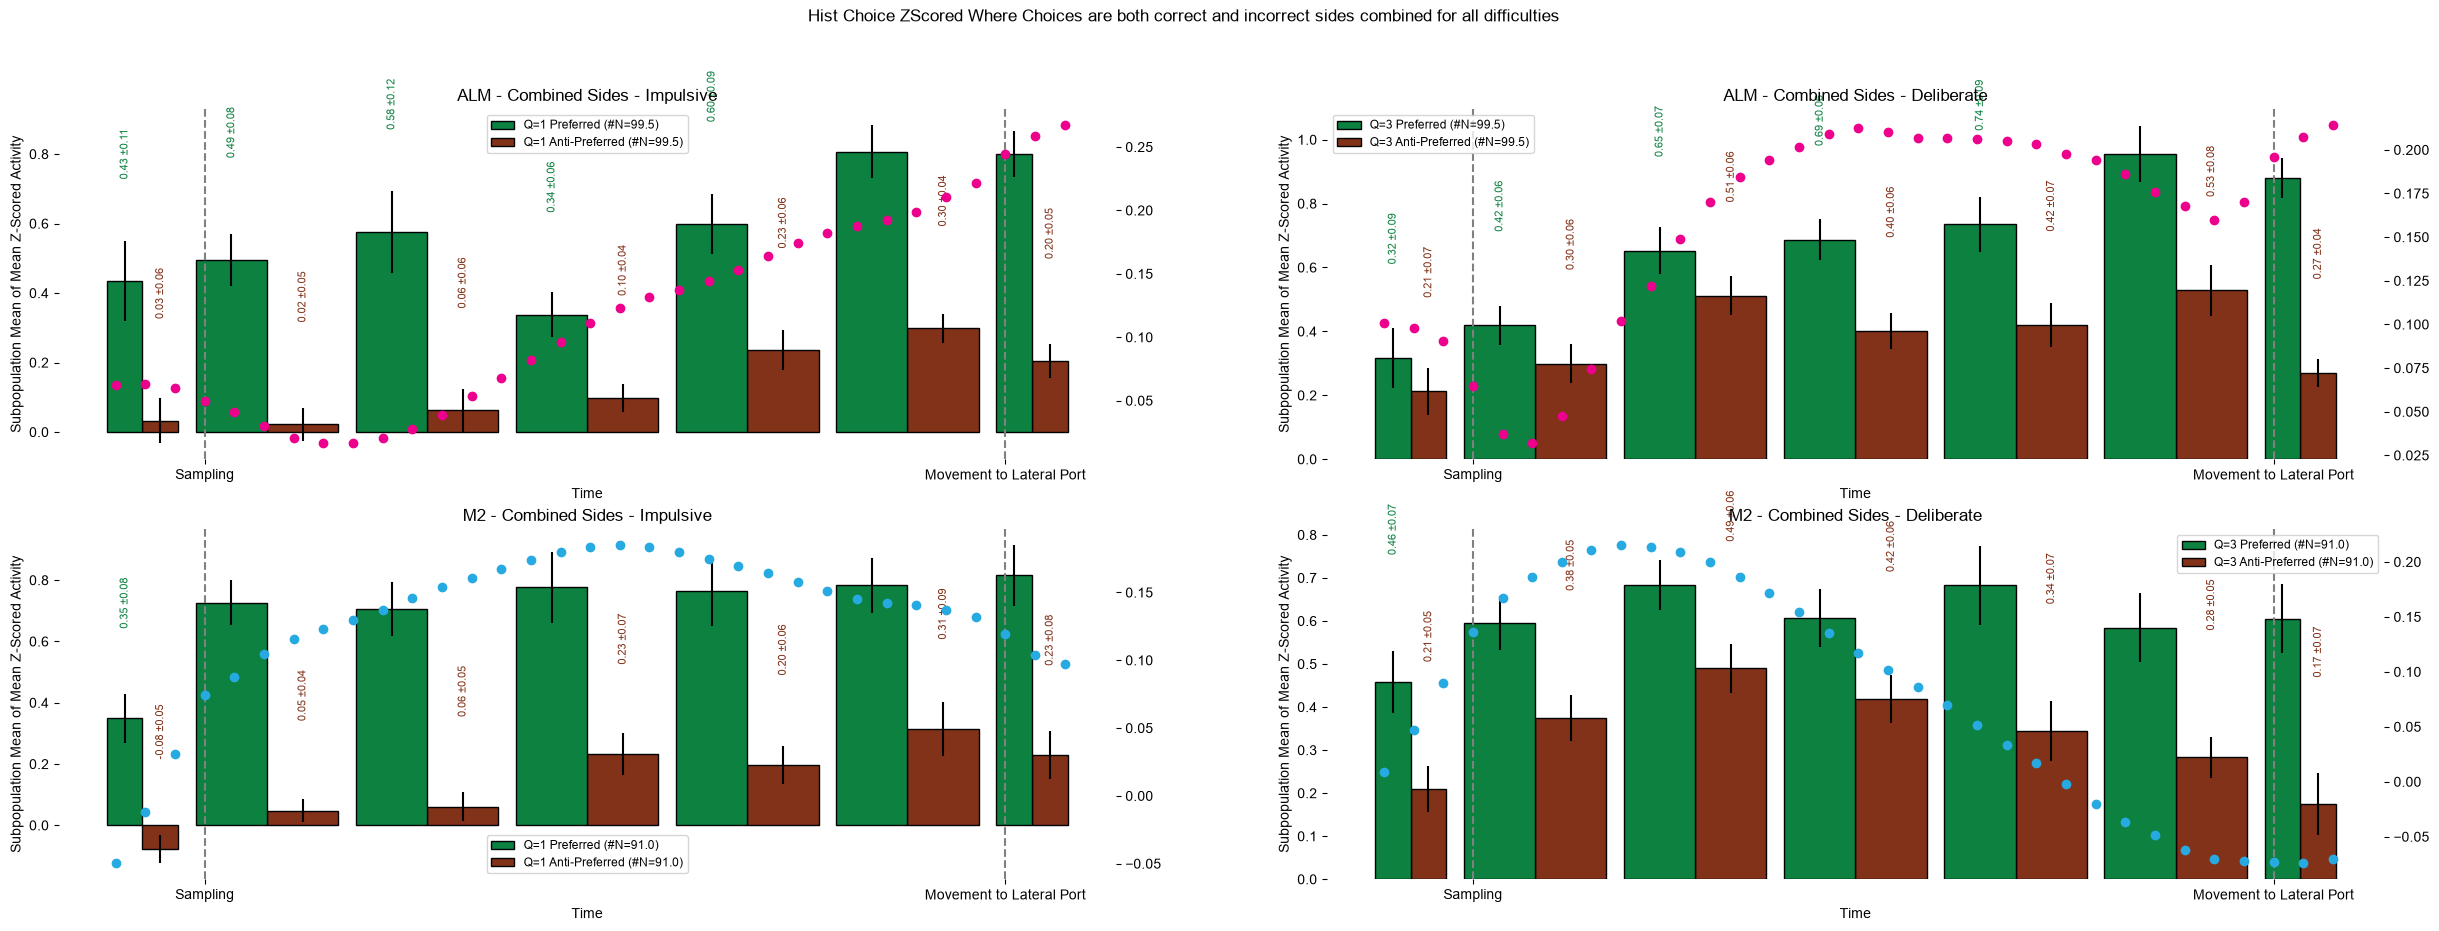

In [59]:
plotTrajectory(as_weight=False, weight_only_first_last=False, plot_region_trace=True,
               plot_single_pts=False, plot_linear_fit=False, save_fig=SAVE_FIGS)

### Fig. 5F

is_left_choice_tuned
NaN    84040
1.0    16200
0.0    15675
Name: count, dtype: int64

is_left_choice_tuned
NaN    83999
1.0    16174
0.0    15663
Name: count, dtype: int64

is_left_choice_tuned
NaN    83927
1.0    16170
0.0    15648
Name: count, dtype: int64

Len preferred_dir_df: 4109 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 3798 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

Len preferred_dir_df: 3406 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 3986 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

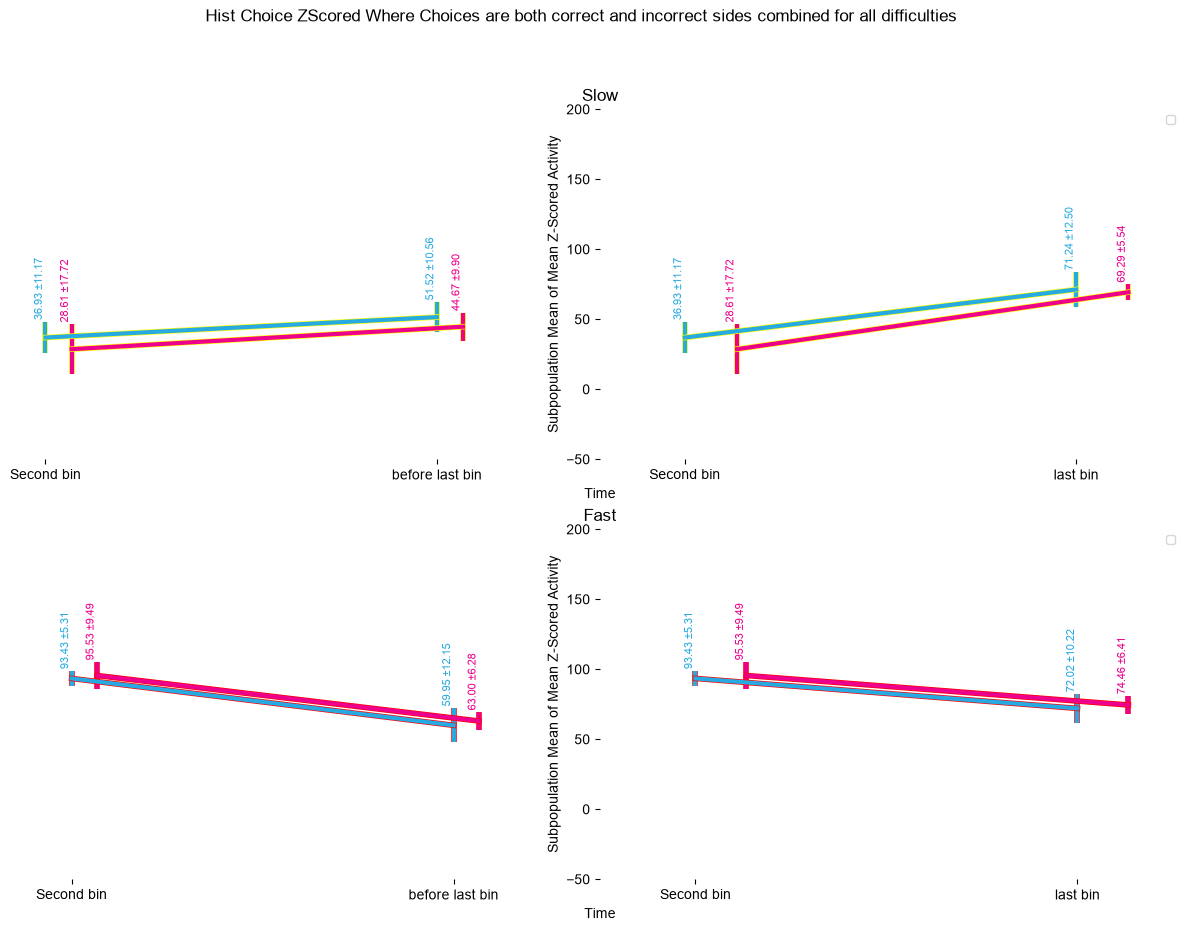

In [60]:
plotTrajectory(as_weight=True, weight_only_first_last=True, plot_single_pts=False,
               # Here these are irrelevant
               plot_region_trace=False,
               plot_linear_fit=False,
               #
               save_fig=SAVE_FIGS)

### Fig. S8F

is_left_choice_tuned
NaN    84040
1.0    16200
0.0    15675
Name: count, dtype: int64

is_left_choice_tuned
NaN    83999
1.0    16174
0.0    15663
Name: count, dtype: int64

is_left_choice_tuned
NaN    83927
1.0    16170
0.0    15648
Name: count, dtype: int64

Len preferred_dir_df: 4109 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 3798 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

Len preferred_dir_df: 3406 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 3986 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

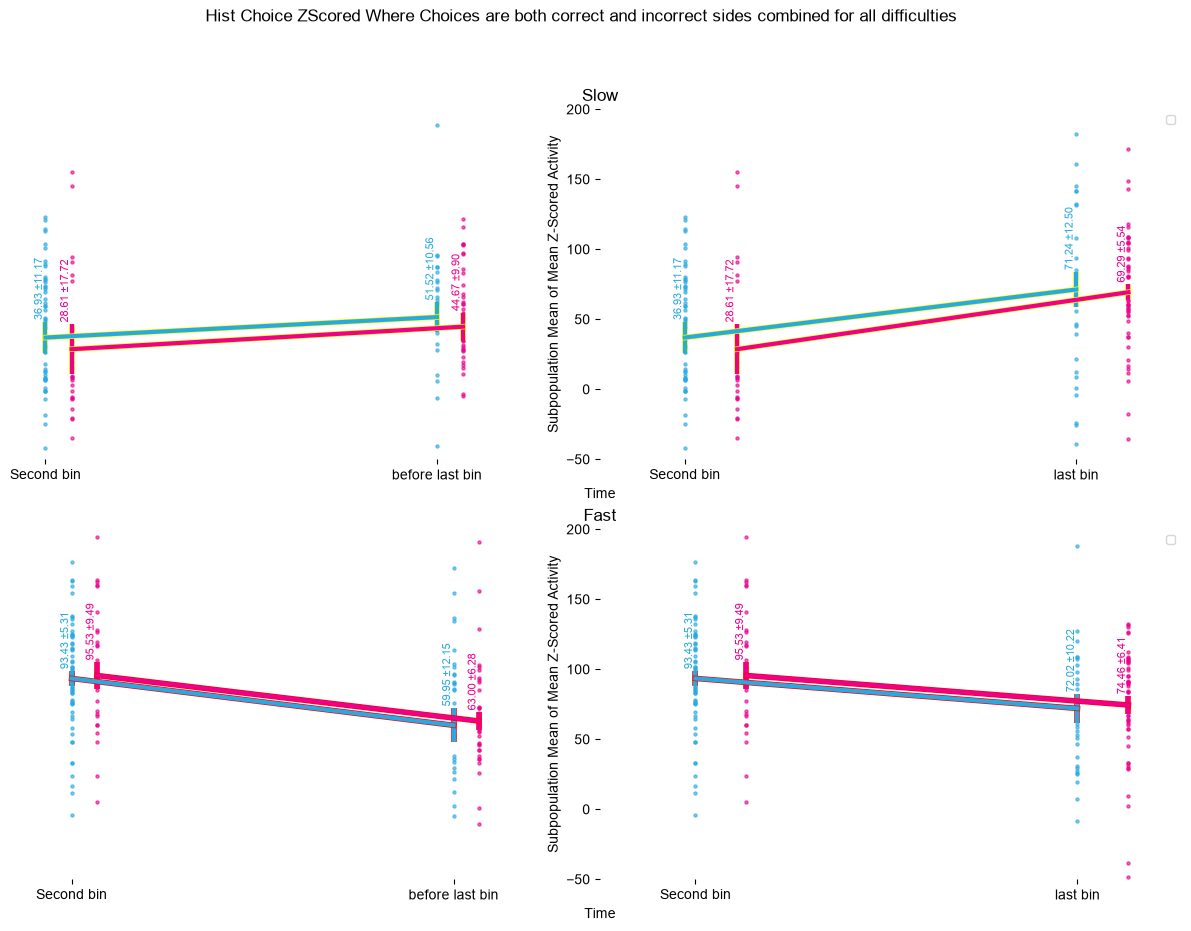

In [61]:
plotTrajectory(as_weight=True, weight_only_first_last=True, plot_single_pts=True,
               # Here these are irrelevant
               plot_region_trace=False,
               plot_linear_fit=False,
               #
               save_fig=SAVE_FIGS)

### Fig. S8E

is_left_choice_tuned
NaN    84040
1.0    16200
0.0    15675
Name: count, dtype: int64

is_left_choice_tuned
NaN    83999
1.0    16174
0.0    15663
Name: count, dtype: int64

is_left_choice_tuned
NaN    83927
1.0    16170
0.0    15648
Name: count, dtype: int64

Len preferred_dir_df: 4109 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 3798 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Col idx: 0 Choice dir: None last_dir: -1
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

Len preferred_dir_df: 3406 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 3986 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Col idx: 1 Choice dir: None last_dir: None
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

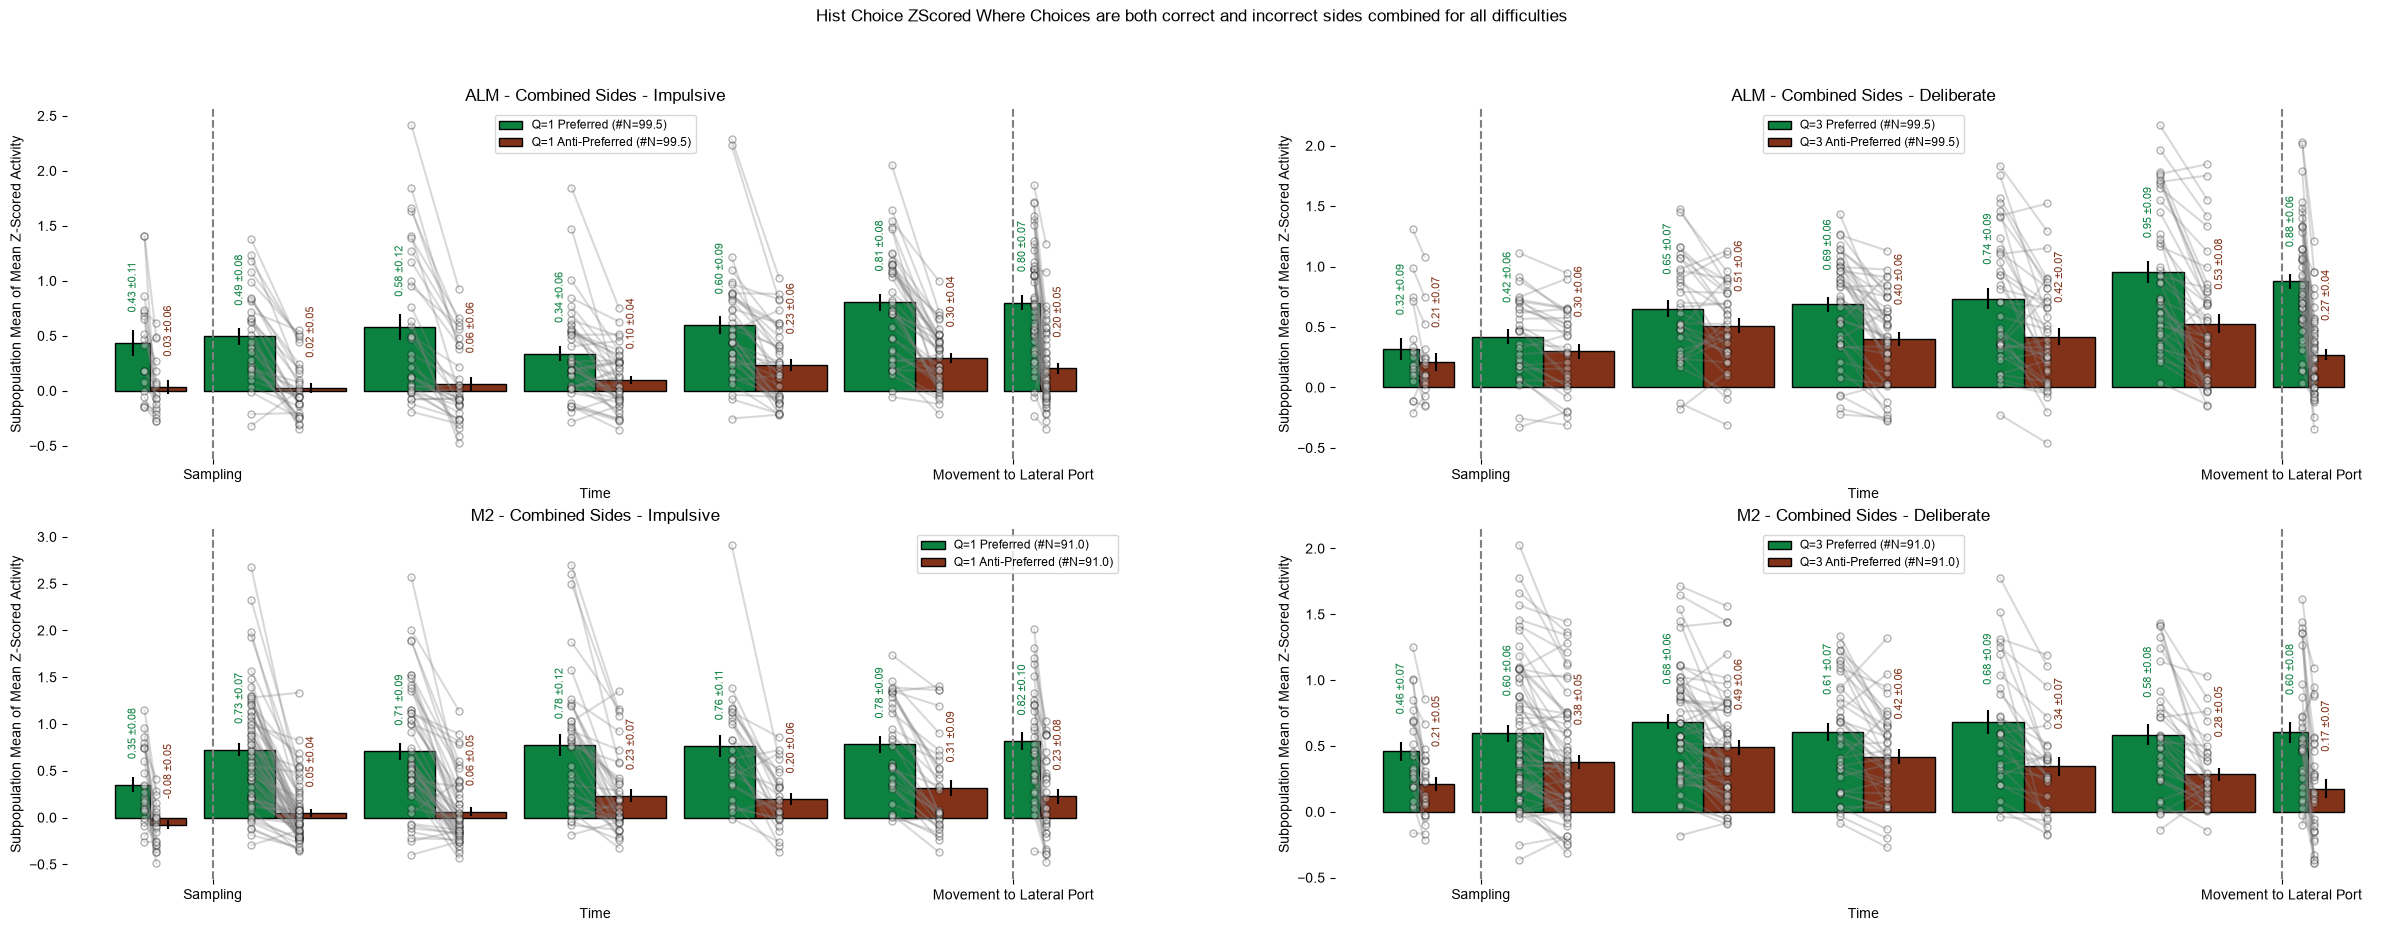

In [62]:
plotTrajectory(plot_single_pts=True, as_weight=False, weight_only_first_last=False,
               plot_region_trace=False, plot_linear_fit=False,  save_fig=SAVE_FIGS)

### Fig. S8H

is_left_choice_tuned
NaN    84040
1.0    16200
0.0    15675
Name: count, dtype: int64

is_left_choice_tuned
NaN    83999
1.0    16174
0.0    15663
Name: count, dtype: int64

is_left_choice_tuned
NaN    83927
1.0    16170
0.0    15648
Name: count, dtype: int64

Len preferred_dir_df: 4109 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 3798 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Col idx: 0 Choice dir: None last_dir: -1
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

Len preferred_dir_df: 3406 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 3986 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Col idx: 1 Choice dir: None last_dir: None
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

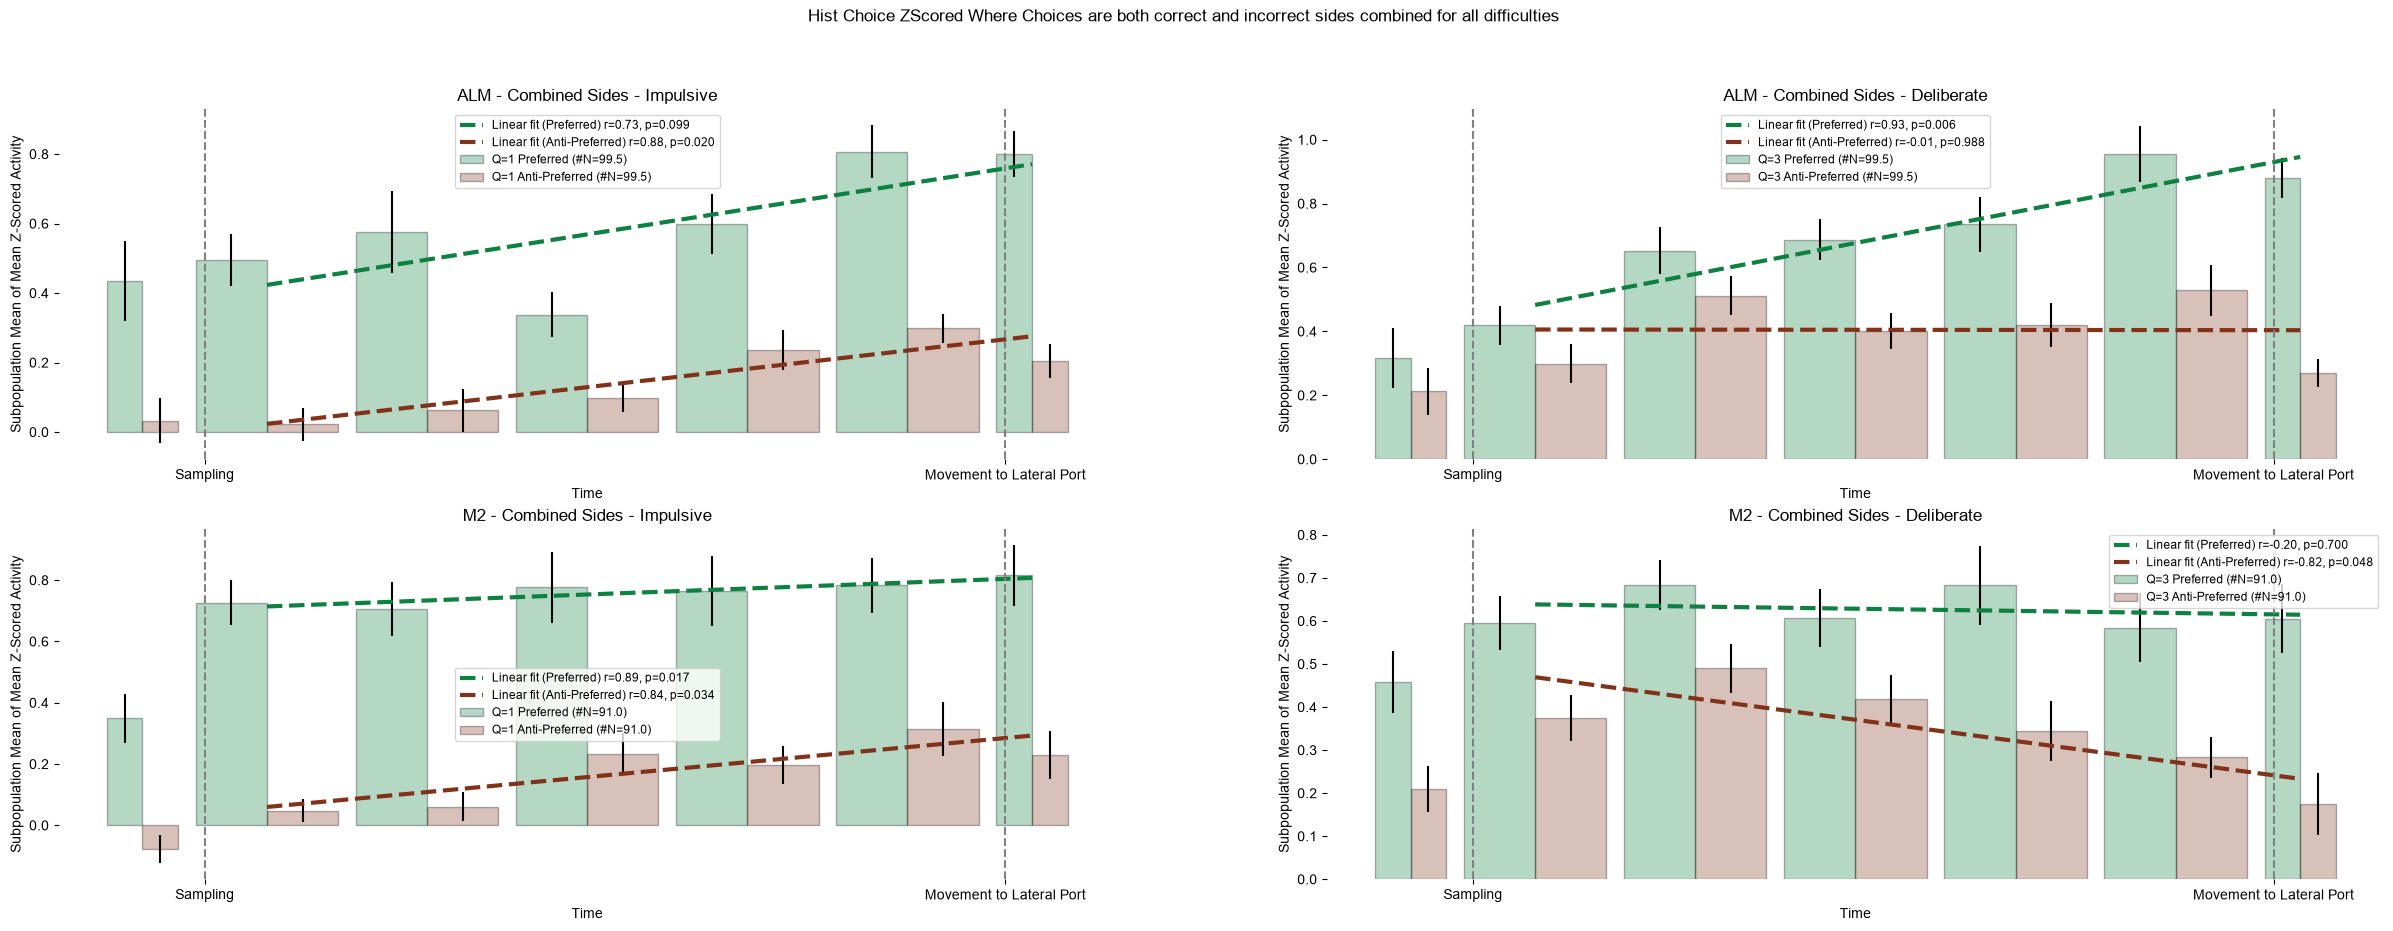

In [63]:
plotTrajectory(plot_linear_fit=True, plot_single_pts=False, as_weight=False,
               weight_only_first_last=False, plot_region_trace=False, save_fig=SAVE_FIGS)

### Fig. S8J

is_left_choice_tuned
NaN    35585
1.0     7149
0.0     6823
Name: count, dtype: int64

is_left_choice_tuned
NaN    35369
1.0     7106
0.0     6824
Name: count, dtype: int64

is_left_choice_tuned
NaN    35434
1.0     7130
0.0     6807
Name: count, dtype: int64

Len preferred_dir_df: 1760 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 1672 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Col idx: 0 Choice dir: None last_dir: -1
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

Len preferred_dir_df: 1567 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 1659 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Col idx: 1 Choice dir: None last_dir: None
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

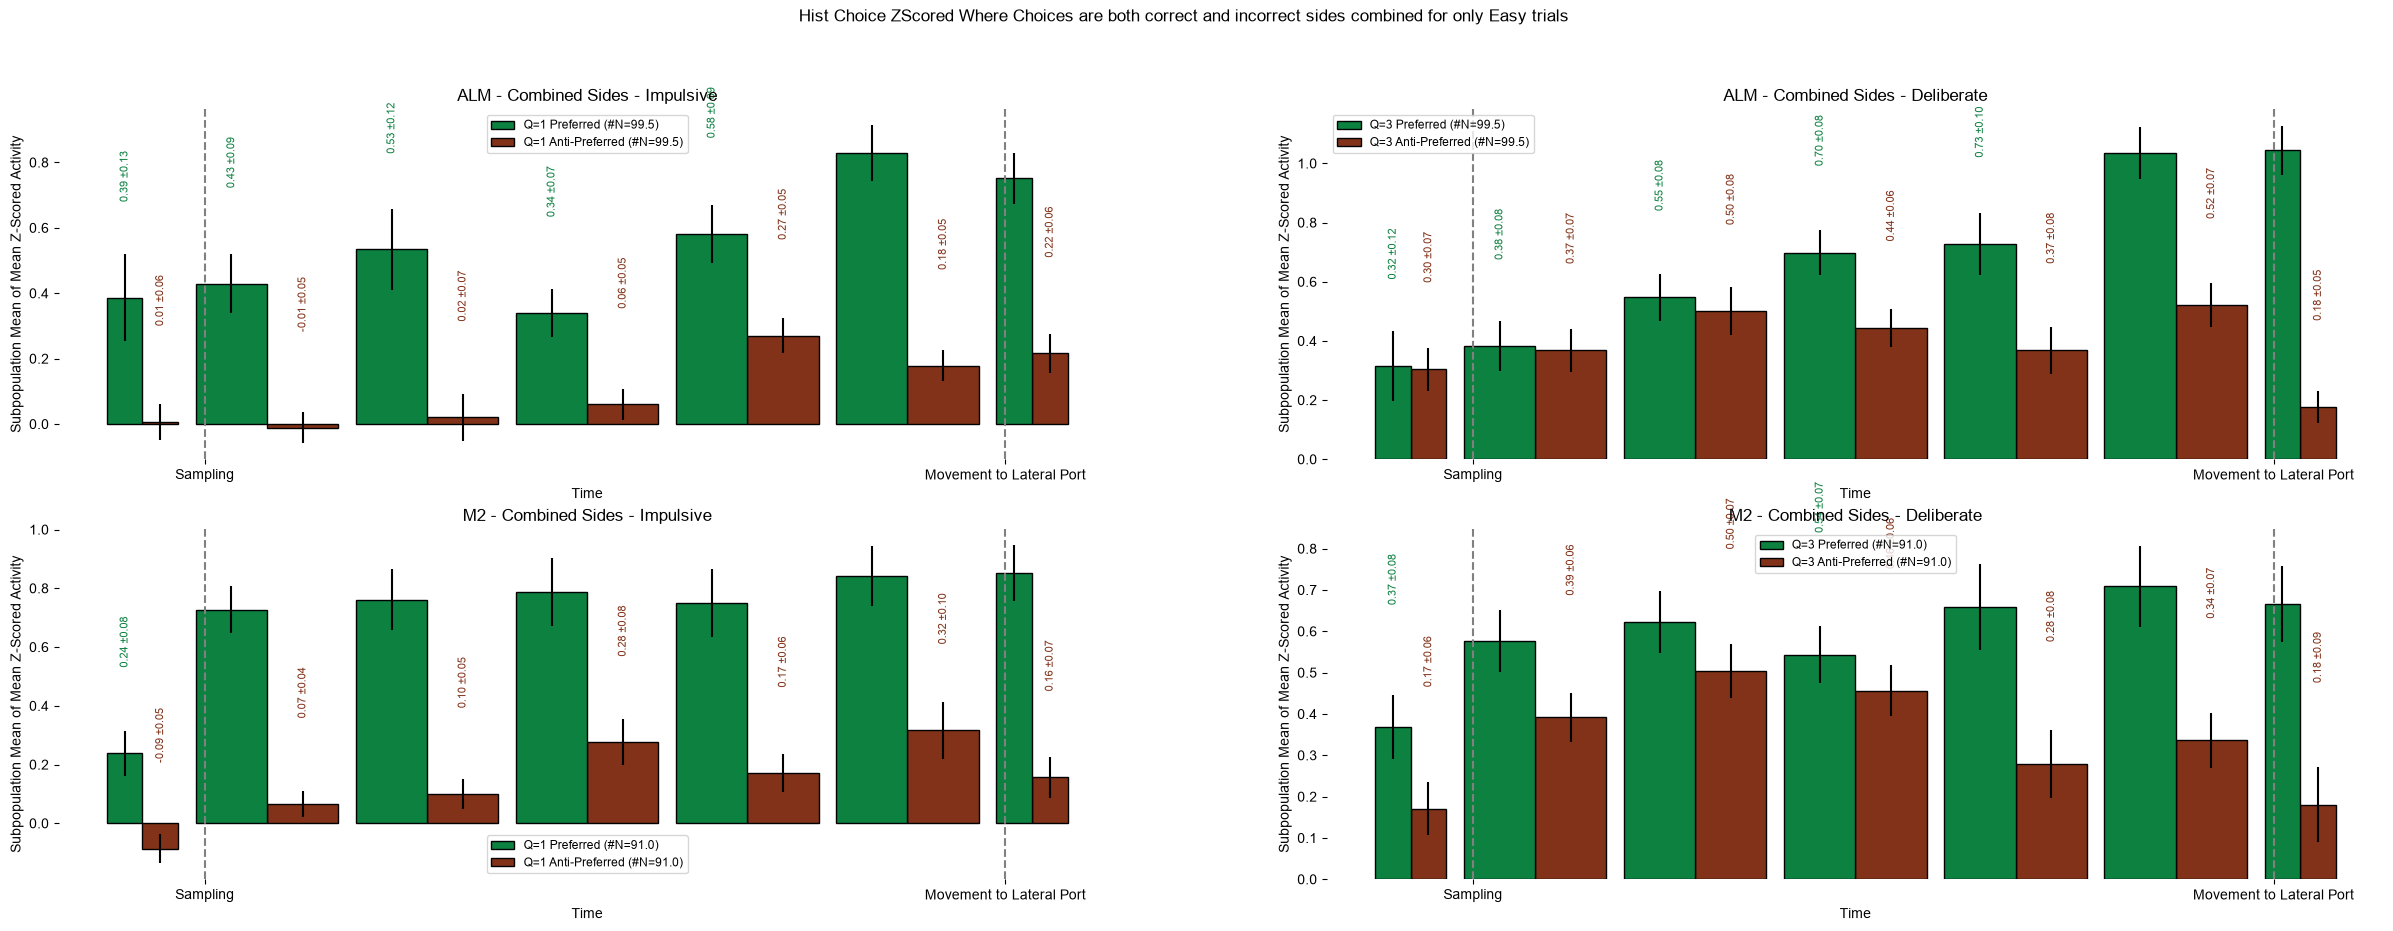

is_left_choice_tuned
NaN    28719
1.0     5377
0.0     5358
Name: count, dtype: int64

is_left_choice_tuned
NaN    28953
1.0     5415
0.0     5369
Name: count, dtype: int64

is_left_choice_tuned
NaN    28645
1.0     5382
0.0     5365
Name: count, dtype: int64

Len preferred_dir_df: 1300 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 1426 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Col idx: 0 Choice dir: None last_dir: -1
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

Len preferred_dir_df: 1066 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 1451 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Col idx: 1 Choice dir: None last_dir: None
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

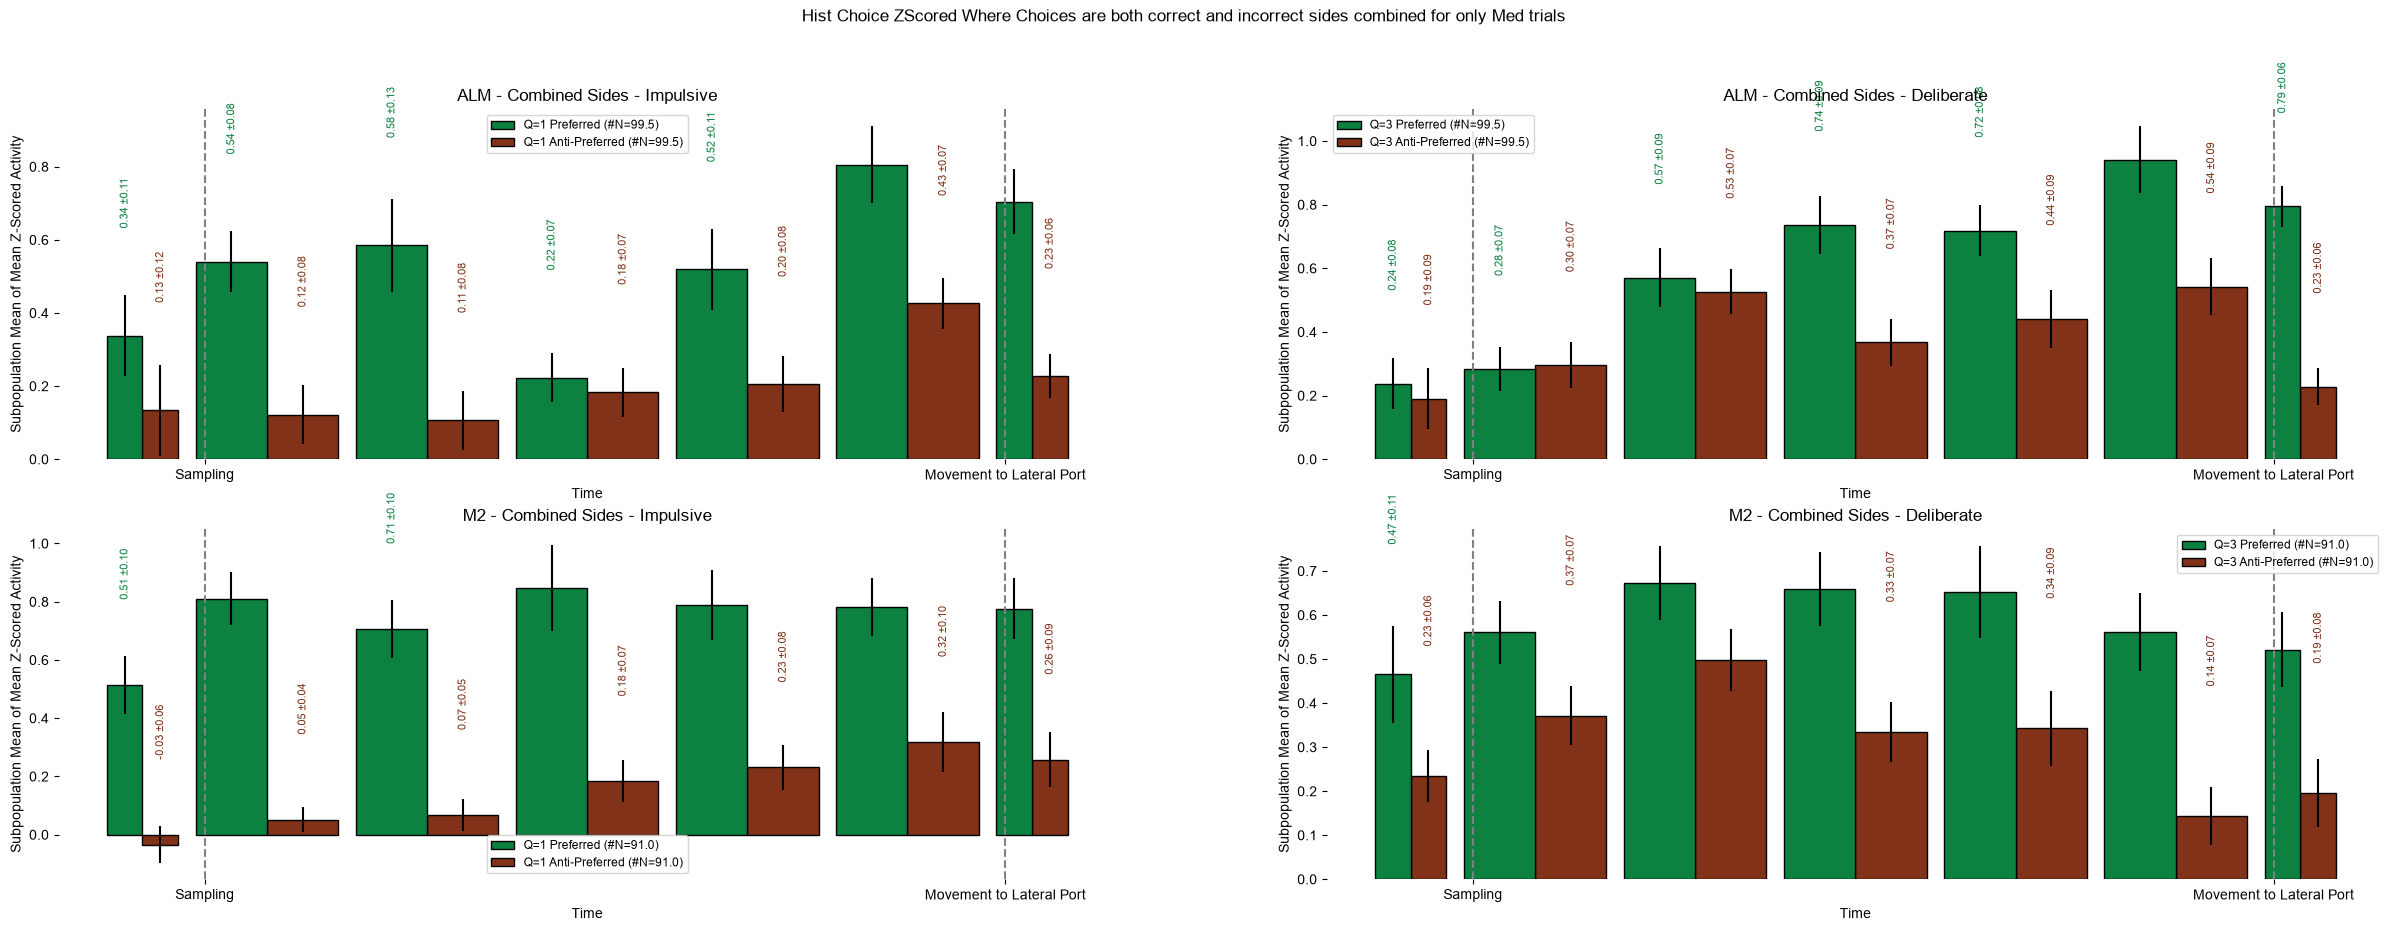

is_left_choice_tuned
NaN    19736
1.0     3674
0.0     3494
Name: count, dtype: int64

is_left_choice_tuned
NaN    19677
1.0     3653
0.0     3470
Name: count, dtype: int64

is_left_choice_tuned
NaN    19848
1.0     3658
0.0     3476
Name: count, dtype: int64

Len preferred_dir_df: 1049 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 700 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Col idx: 0 Choice dir: None last_dir: -1
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

Len preferred_dir_df: 773 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 876 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Col idx: 1 Choice dir: None last_dir: None
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

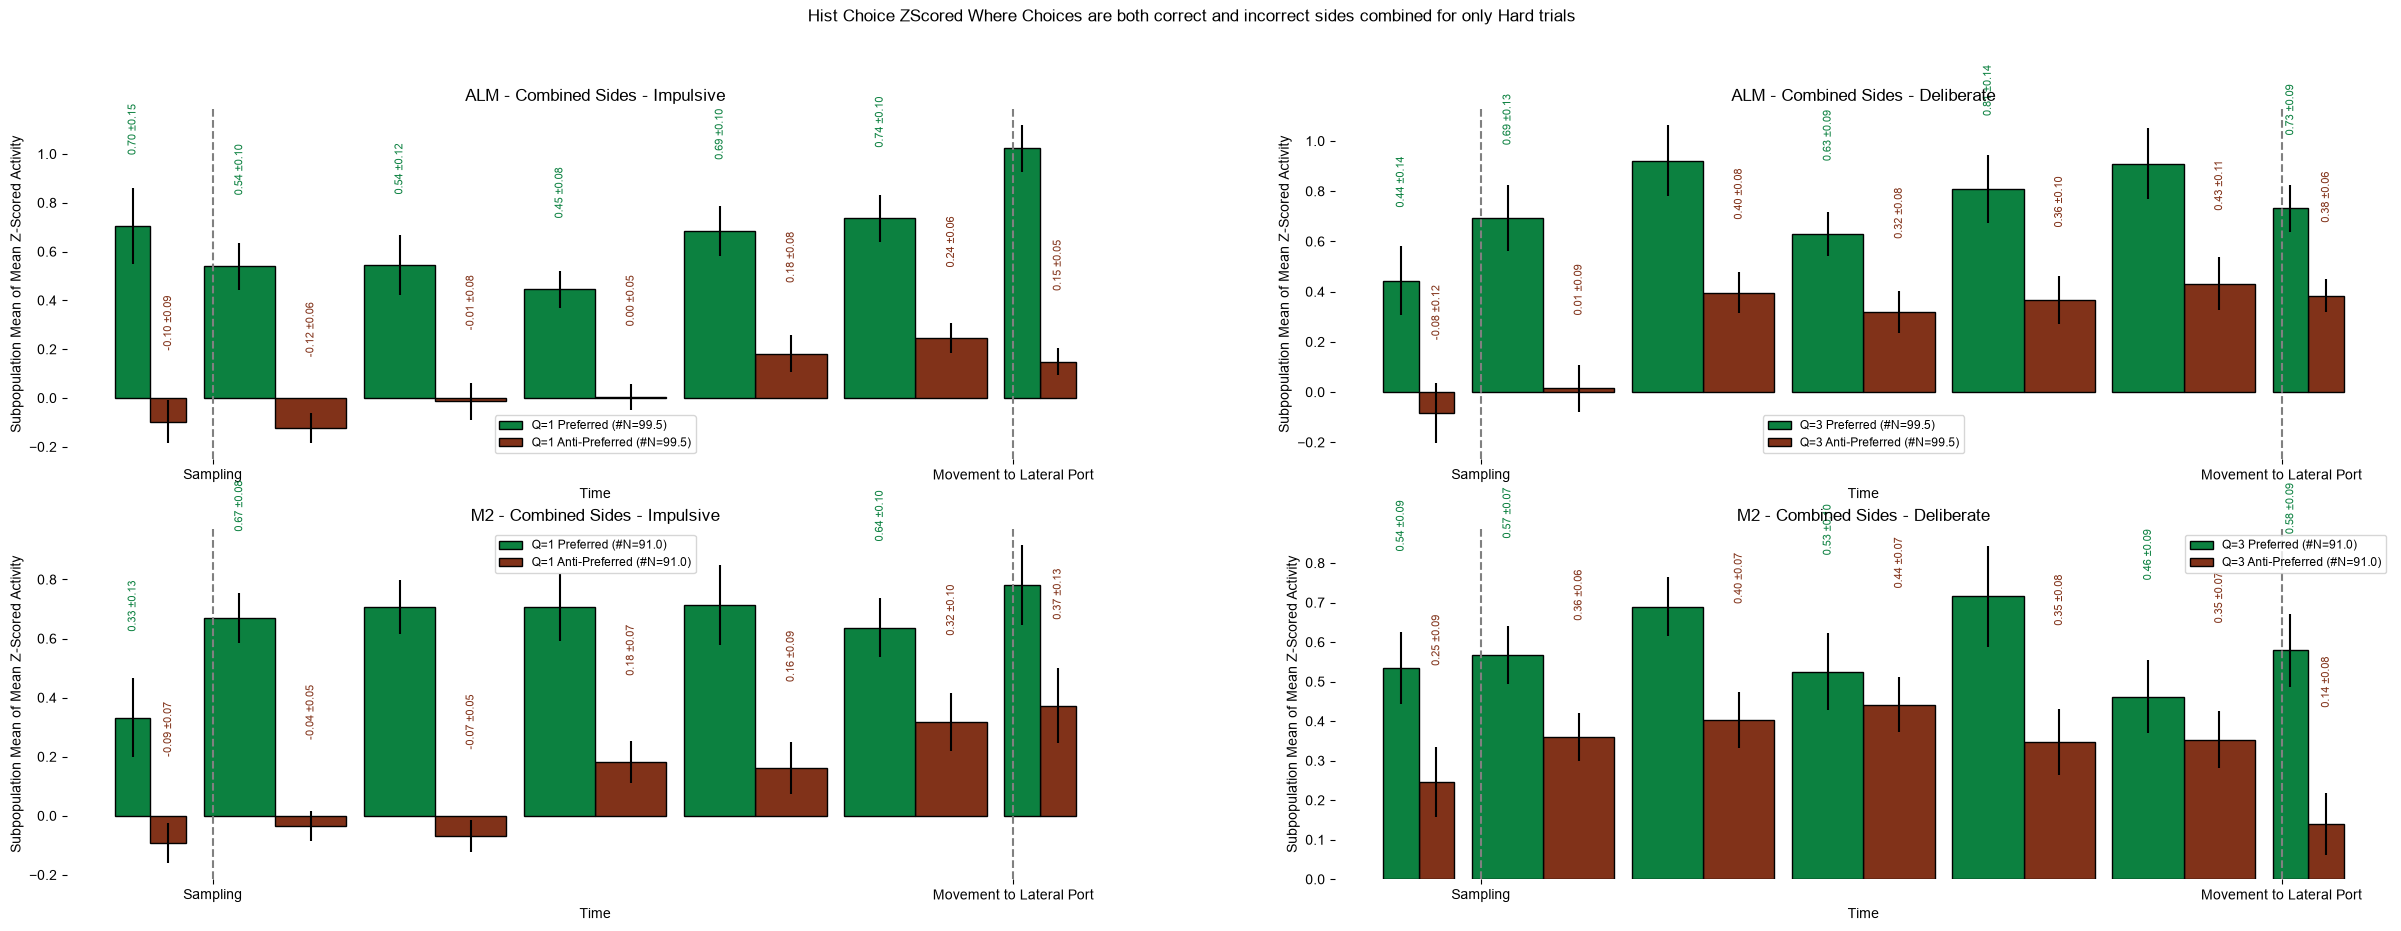

In [64]:
plotTrajectory(split_difficulties=True,
               plot_single_pts=False, as_weight=False, weight_only_first_last=False,
               plot_region_trace=False, plot_linear_fit=False, save_fig=SAVE_FIGS)

### Fig. S8??

is_left_choice_tuned
NaN    84040
1.0    16200
0.0    15675
Name: count, dtype: int64

is_left_choice_tuned
NaN    83999
1.0    16174
0.0    15663
Name: count, dtype: int64

is_left_choice_tuned
NaN    83927
1.0    16170
0.0    15648
Name: count, dtype: int64

Len preferred_dir_df: 4109 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 120
Len preferred_dir_df: 3798 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 79
Col idx: 0 Choice dir: None last_dir: -1
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  before, mid, after = all_df.iloc[0].epochs_ranges[0]
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

Len preferred_dir_df: 3406 for choice_dir: 1.0 For sour split: ChoiceLeft uniq traces: 77
Len preferred_dir_df: 3986 for choice_dir: 0.0 For sour split: ChoiceLeft uniq traces: 105
Col idx: 1 Choice dir: None last_dir: None
Rounded to: [ 0.   3.   8.4 13.8 19.2 24.6 30.  33. ]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:339: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:301: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  as_index=False).apply(meanNeuronTrials)
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\twop\plottuning.py:664: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

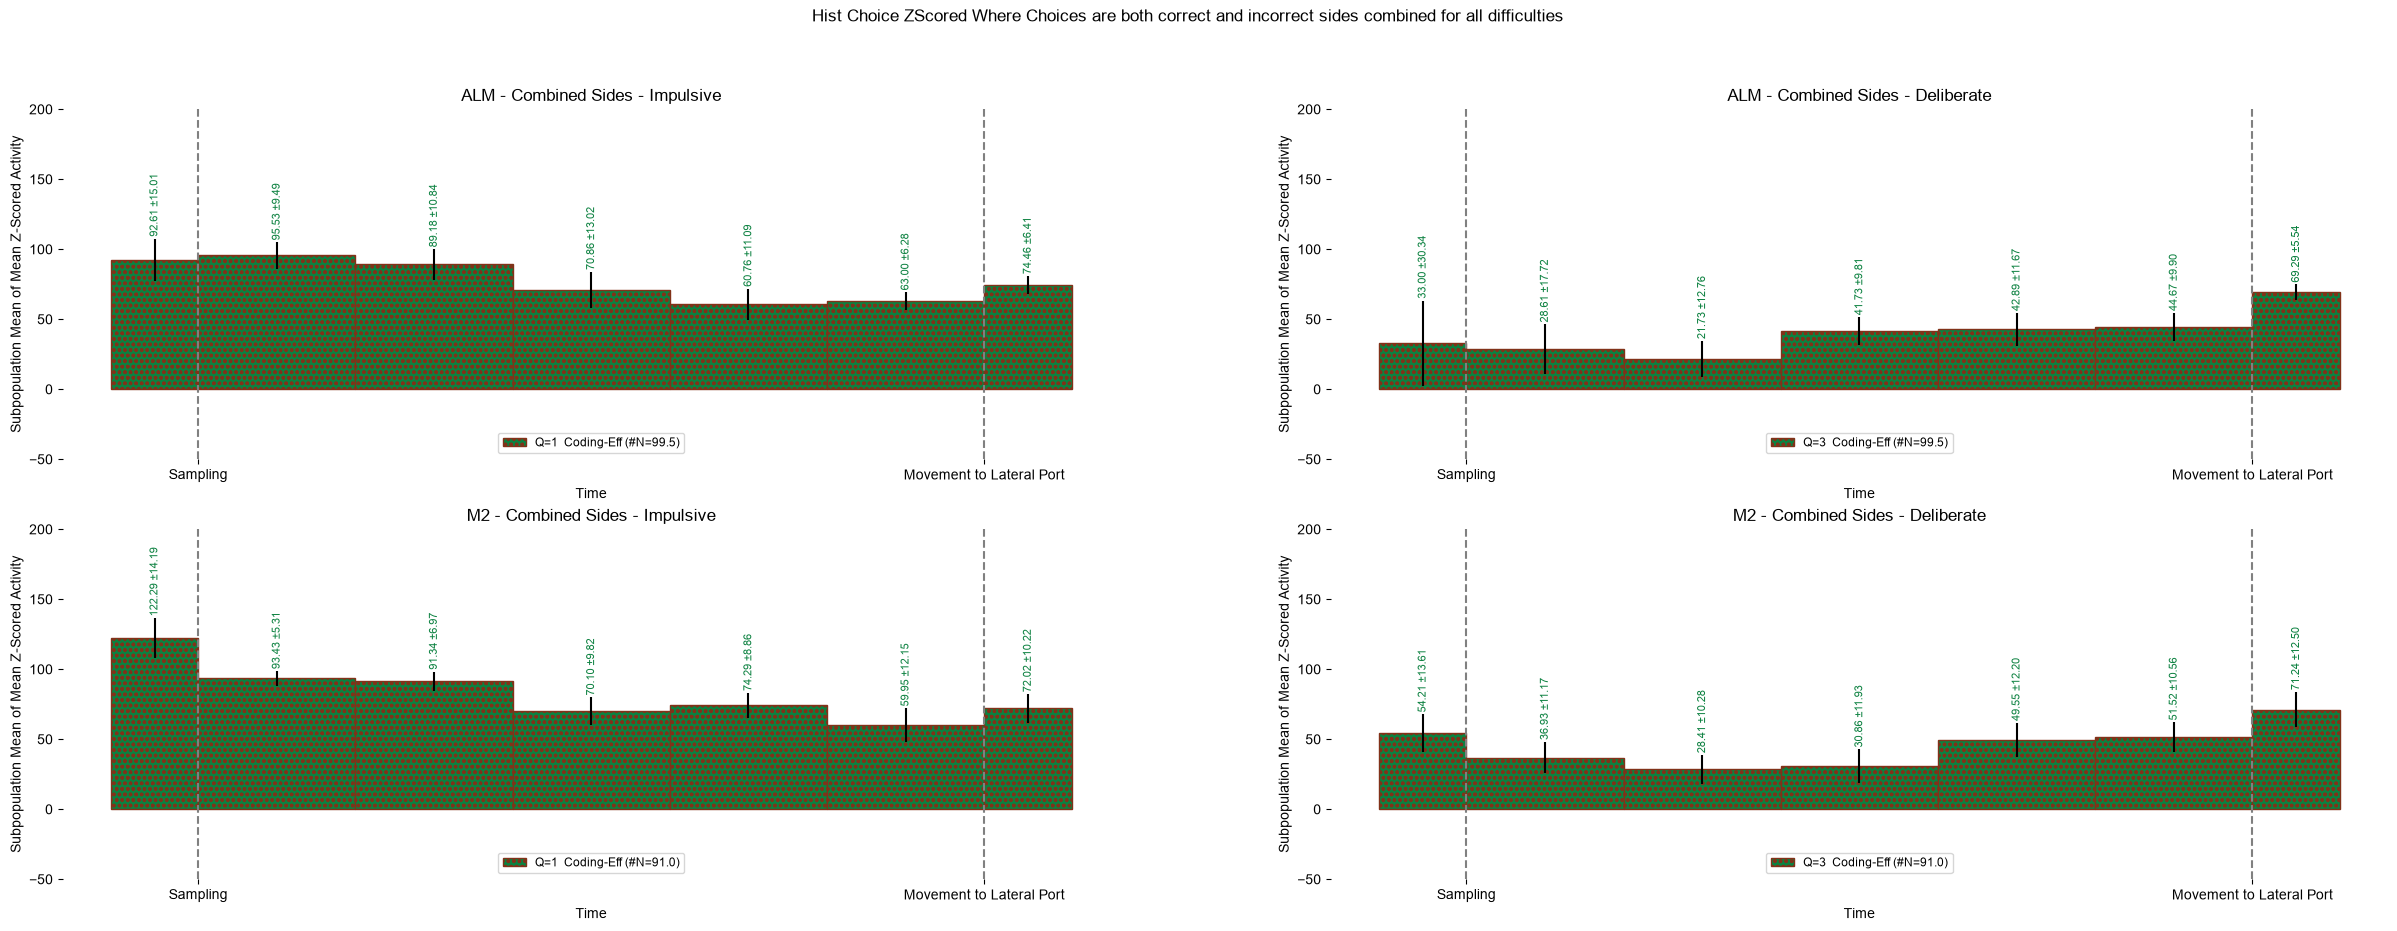

In [65]:
plotTrajectory(as_weight=True, weight_only_first_last=False,  plot_region_trace=False,
               plot_linear_fit=False, plot_single_pts=False, save_fig=SAVE_FIGS)

# Movement time neurons

## Movement-time neurons: MFC vs LFC

A neuron's firing position is the **median** of its per-trial peak samples
(`max_idxs`, built in the `# Sequence Extracation` section). The sampling-aligned
traces carry `epochs_ranges = [(0, 2), (3, 29), (30, 32)]` =
`['-0.1s Sampling', 'Sampling', 'Movement to Lateral Port']`, and with
`BINS_COUNT = 7` the bins are `[pre-sampling] + 5 x [sampling] + [movement]`, so
the **last (7th) bin `(30, 33]` is the movement epoch** and the **6th bin
`(24.6, 30]` is where movement is initiated** - the last ~0.18 s of sampling
before the animal leaves the centre port, which is exactly the window
`makeActive` selects its own "movement" set on. Each method below is a
*criterion* x *window* pair:

- **`last_bin`** - median peak in the last bin (movement only). `maxFiringHist`
  bins with `pd.cut`, whose intervals are left-open, so a median sitting exactly
  on the onset sample (30) counts as the last *sampling* bin.
- **`last_two_bins`** - median peak in the last **two** bins, i.e. movement
  initiation **or** movement. A superset of `last_bin`.
- **`movement_epoch`** - median peak `>=` the movement onset. The same question
  read straight off `epochs_ranges`, the way `_setupAxs` / `makeActive` do;
  it differs from `last_bin` only for the medians exactly on sample 30.
- **`iqr_q1`** - stricter, and built the way `makeActive` picks its neuron sets:
  the **q1** of the per-trial peaks is `>=` the onset, i.e. the neuron peaks
  after movement start in >=75% of its active trials, not merely in the median
  trial.

`METHOD_SPECS` also registers `initiation_onset` and `iqr_q1_two_bins` (the
threshold and q1 criteria on the two-bin window); pass them via `methods=` to
run those too.

Each criterion is reported twice: over **all** neurons, and restricted to the
neurons that are *also* significantly choice-selective (`getSgfNeurons`,
`data_col="ChoiceLeft"`, no prior, `pval <= PVAL`) - still as a percentage of
**all** neurons, so the two numbers are directly comparable. (Choice-selectivity
on its own, with no movement restriction, is not repeated here - it is the
number the `# Sgf. Neurons Pie Charts` section already plots; it stays in the
per-session table as `n_choice` / `prcnt_choice` because it feeds the
intersection.) Percentages are
**mean +/- SEM over sessions** (the session is the independent unit, as in the
pie-chart / Venn sections), each session's denominator being all of its neurons.
MFC vs LFC runs a **normality test first**: Shapiro-Wilk on each region's
per-session values (the two regions are independent samples of *different*
sessions, so there are no paired differences to test). If both look normal the
comparison is a **two-sample t-test**, with Levene's test picking Student
(equal variances) vs Welch; otherwise it falls back to **Mann-Whitney U**, the
notebook's `defaultStatsTestFn`. Both p-values are always reported
(`ttest_pval`, `mwu_pval`), with `test` / `statistic` / `pval` carrying the one
the gate selected.

Because sessions are **nested in a handful of animals** (MFC 5 animals / 13
sessions, LFC only **3** animals / 10 sessions, with an intra-class correlation
of 0.35-0.64), a session-level test can be carried by repeated sessions of one
animal. The last cell therefore re-tests every comparison with a **hierarchical
bootstrap** (resample animals -> that animal's sessions -> the neurons within
each session, 10k times) and reports the bootstrap SE, the 95% CI of the
MFC-LFC difference and a direct-probability p. Read a result as solid only when
both agree. All the code lives in `twop/movementneurons.py`.

In [66]:
from .twop import movementneurons as mn

# Global flag for this section: True writes the figures under fig_save_prefix.

def runMovementNeurons(max_firing_df, normed_sampling_df, shortlong_df):
    """Per-session movement-neuron counts + the MFC-vs-LFC summary table."""
    # Choice-selective = sgf. for the current-trial direction, no prior, at PVAL.
    choice_sgf_ids = getSgfNeurons(shortlong_df, data_col="ChoiceLeft")
    sess_df = mn.perSessionCountsAllMethods(
        max_firing_df, epoch_ranges=normed_sampling_df.iloc[0].epochs_ranges,
        choice_sgf_ids=choice_sgf_ids, bins_count=BINS_COUNT)
    # prcnt_choice (choice-selectivity with NO movement restriction) is left out:
    # it is the same per-session mean +/- SEM that the "Sgf. Neurons Pie Charts"
    # section already plots. It stays in sess_df as n_choice / prcnt_choice.
    summary_df = mn.regionSummary(sess_df,
                                  metrics=(mn.METRIC_MOVEMENT,
                                           mn.METRIC_MOVEMENT_CHOICE,
                                           mn.METRIC_CHOICE_OF_MOVEMENT))
    print(mn.formatSummary(summary_df, bins_count=BINS_COUNT))
    return sess_df, summary_df

movement_sess_df, movement_summary_df = runMovementNeurons(
    max_firing_all_df, normed_sampling_df,
    run_data_unnormalized[0].shortlong_df)
display(movement_summary_df.round(2))

Movement-time neurons (% of all neurons)  [median peak during movement bin]
    MFC: 3.39% +/- 0.81% SEM  (13 sessions, 25/837 neurons)
    LFC: 6.43% +/- 2.05% SEM  (10 sessions, 46/609 neurons)
    Normality (Shapiro-Wilk): MFC p=0.354, LFC p=0.0936 -> normal, t-test usable
    MFC vs LFC: t-test (Welch) stat=-1.38, p=0.193 (MannWhitneyU p=0.332 for reference)
Movement-time AND choice-selective neurons (% of all neurons)  [median peak during movement bin]
    MFC: 1.75% +/- 0.56% SEM  (13 sessions, 13/837 neurons)
    LFC: 3.11% +/- 1.09% SEM  (10 sessions, 21/609 neurons)
    Normality (Shapiro-Wilk): MFC p=0.00933, LFC p=0.0727 -> not normal, t-test not usable
    MFC vs LFC: MannWhitneyU stat=54, p=0.502 (t-test p=0.252 for reference)
Choice-selective neurons (% of movement-time neurons)  [median peak during movement bin]
    MFC: 55.33% +/- 13.29% SEM  (10 sessions, 13/25 neurons)
    LFC: 45.82% +/- 12.22% SEM  (7 sessions, 21/46 neurons)
    Normality (Shapiro-Wilk): MFC p=0.04

,method,metric,MFC_n_sessions,MFC_mean,MFC_sem,MFC_n,MFC_total,LFC_n_sessions,LFC_mean,LFC_sem,...,MFC_shapiro_pval,LFC_shapiro_W,LFC_shapiro_pval,is_normal,levene_pval,test,statistic,pval,ttest_pval,mwu_pval
0,last_bin,prcnt_movement,13,3.39,0.81,25,837,10,6.43,2.05,...,0.35,0.87,0.09,True,0.02,t-test (Welch),-1.38,0.19,0.19,0.33
1,last_bin,prcnt_movement_choice,13,1.75,0.56,13,837,10,3.11,1.09,...,0.01,0.86,0.07,False,0.09,MannWhitneyU,54.00,0.50,0.25,0.50
2,last_bin,prcnt_choice_of_movement,10,55.33,13.29,13,25,7,45.82,12.22,...,0.05,0.94,0.68,False,0.26,MannWhitneyU,38.00,0.80,0.62,0.80
3,last_two_bins,prcnt_movement,13,15.91,1.58,127,837,10,24.12,3.61,...,0.05,0.99,0.99,False,0.05,MannWhitneyU,34.00,0.06,0.03,0.06
4,last_two_bins,prcnt_movement_choice,13,5.10,1.02,38,837,10,11.85,1.50,...,0.75,0.96,0.82,True,0.49,t-test (Student),-3.84,0.00,0.00,0.00
5,last_two_bins,prcnt_choice_of_movement,13,32.26,5.70,38,127,10,56.44,7.68,...,0.67,0.91,0.29,True,0.45,t-test (Student),-2.59,0.02,0.02,0.03
6,movement_epoch,prcnt_movement,13,5.56,0.93,43,837,10,9.45,3.58,...,0.70,0.83,0.04,False,0.02,MannWhitneyU,57.50,0.66,0.32,0.66
7,movement_epoch,prcnt_movement_choice,13,2.28,0.71,17,837,10,4.07,1.46,...,0.01,0.85,0.06,False,0.13,MannWhitneyU,54.00,0.50,0.25,0.50
8,movement_epoch,prcnt_choice_of_movement,11,43.48,11.73,17,43,7,44.44,11.83,...,0.14,0.97,0.86,True,0.22,t-test (Student),-0.05,0.96,0.96,0.96
9,iqr_q1,prcnt_movement,13,0.63,0.25,5,837,10,3.11,1.16,...,0.00,0.82,0.02,False,0.01,MannWhitneyU,39.00,0.09,0.06,0.09


In [67]:
# The raw per-session counts behind the percentages (one row per session x
# criterion). n_neurons is the denominator of every prcnt_* except
# prcnt_choice_of_movement, which is out of that session's movement neurons.
display(movement_sess_df.sort_values(["method", "BrainRegion", "ShortName"]))

,method,BrainRegion,ShortName,animal,n_neurons,n_movement,n_choice,n_movement_choice,prcnt_movement,prcnt_movement_choice,prcnt_choice,prcnt_choice_of_movement
69,iqr_q1,LFC,GP4_23_s6_L50_D250_ALM,GP4_23,77,7,14,1,9.090909,1.298701,18.181818,14.285714
70,iqr_q1,LFC,GP4_23_s7_L50_D250_ALM,GP4_23,106,3,39,2,2.830189,1.886792,36.792453,66.666667
71,iqr_q1,LFC,GP4_23_s8_L50_D250_ALM,GP4_23,94,3,44,2,3.191489,2.127660,46.808511,66.666667
72,iqr_q1,LFC,GP4_85_s10_L70_D250_ALM,GP4_85,38,0,16,0,0.000000,0.000000,42.105263,NaN
73,iqr_q1,LFC,GP4_85_s6_L65_D250_ALM,GP4_85,60,1,21,1,1.666667,1.666667,35.000000,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
64,movement_epoch,MFC,GP4_80_S2_L51_D250_M2m,GP4_80,54,4,5,3,7.407407,5.555556,9.259259,75.000000
65,movement_epoch,MFC,GP4_80_S4_L50_D250_M2m,GP4_80,45,5,10,3,11.111111,6.666667,22.222222,60.000000
66,movement_epoch,MFC,GP4_85_S1_L70_D250_mm2,GP4_85,50,3,5,2,6.000000,4.000000,10.000000,66.666667
67,movement_epoch,MFC,GP4_85_s2_L100_D250_mm2,GP4_85,50,0,10,0,0.000000,0.000000,20.000000,NaN


In [68]:
# Two figures, both on the initiation + movement window (the last two bins):
#   1. every neuron peaking in that window,
#   2. the same restricted to the significantly choice-selective ones.
# MFC vs LFC bars, mean +/- SEM over sessions, one dot per session, and the
# p-value of the normality-gated test. mn.plotMethodsComparison(...) is still
# available if you ever want the other criteria side by side.
for _metric in [mn.METRIC_MOVEMENT, mn.METRIC_MOVEMENT_CHOICE]:
    mn.plotRegionBars(movement_sess_df, metric=_metric,
                      method=mn.METHOD_LAST_TWO_BINS, bins_count=BINS_COUNT,
                      save_figs=SAVE_FIGS,
                      fig_save_prefix=fig_save_prefix)

In [69]:
# Sessions are nested in animals (LFC = 3 animals for 10 sessions), so the
# session-level SEM/test above can be carried by one animal's repeated sessions.
# Re-test by resampling animals -> sessions -> neurons. A comparison that is
# significant per-session but not here is pseudo-replication, not an effect.
N_BOOT = 10_000  # lower while iterating; 10k for the reported numbers

movement_boot_df = mn.bootstrapSummary(
    movement_sess_df,
    metrics=(mn.METRIC_MOVEMENT, mn.METRIC_MOVEMENT_CHOICE,
             mn.METRIC_CHOICE_OF_MOVEMENT),
    n_boot=N_BOOT)
print(mn.formatBootstrap(movement_boot_df, bins_count=BINS_COUNT))
display(movement_boot_df.round(3))

Movement-time neurons (% of all neurons)  [median peak during movement bin]
    MFC: 3.39% +/- 1.25 boot-SE  95% CI [1.48, 6.35]  (5 animals)
    LFC: 6.43% +/- 3.53 boot-SE  95% CI [1.43, 14.62]  (3 animals)
    MFC-LFC: -3.50 95% CI [-11.41, +2.72]  p_boot=0.3614 (n.s.)
Movement-time AND choice-selective neurons (% of all neurons)  [median peak during movement bin]
    MFC: 1.75% +/- 0.82 boot-SE  95% CI [0.36, 3.53]  (5 animals)
    LFC: 3.11% +/- 1.97 boot-SE  95% CI [0.56, 8.06]  (3 animals)
    MFC-LFC: -1.72 95% CI [-6.58, +1.73]  p_boot=0.4280 (n.s.)
Choice-selective neurons (% of movement-time neurons)  [median peak during movement bin]
    MFC: 55.33% +/- 16.66 boot-SE  95% CI [20.04, 85.19]  (5 animals)
    LFC: 45.82% +/- 16.33 boot-SE  95% CI [19.05, 83.83]  (3 animals)
    MFC-LFC: +5.72 95% CI [-41.98, +49.04]  p_boot=0.7732 (n.s.)
Movement-initiation + movement neurons (% of all neurons)  [median peak during initiation or movement bin]
    MFC: 15.91% +/- 2.83 boot-SE  

,method,metric,n_boot,MFC_n_animals,MFC_mean,MFC_boot_se,MFC_ci_lo,MFC_ci_hi,LFC_n_animals,LFC_mean,LFC_boot_se,LFC_ci_lo,LFC_ci_hi,diff_mean,diff_ci_lo,diff_ci_hi,pval_boot
0,last_bin,prcnt_movement,10000,5,3.390,1.247,1.477,6.353,3,6.431,3.533,1.434,14.617,-3.500,-11.412,2.715,0.361
1,last_bin,prcnt_movement_choice,10000,5,1.755,0.820,0.364,3.533,3,3.108,1.974,0.556,8.062,-1.722,-6.582,1.729,0.428
2,last_bin,prcnt_choice_of_movement,10000,5,55.333,16.665,20.039,85.187,3,45.819,16.329,19.048,83.832,5.723,-41.984,49.042,0.773
3,last_two_bins,prcnt_movement,10000,5,15.909,2.828,11.192,22.557,3,24.119,4.953,15.949,35.519,-8.629,-20.568,1.946,0.112
4,last_two_bins,prcnt_movement_choice,10000,5,5.104,1.519,2.035,8.031,3,11.845,2.108,8.134,16.405,-6.881,-12.333,-1.968,0.008
5,last_two_bins,prcnt_choice_of_movement,10000,5,32.265,8.047,15.018,46.736,3,56.443,10.884,35.010,76.433,-24.122,-50.462,2.058,0.075
6,movement_epoch,prcnt_movement,10000,5,5.559,1.441,3.252,8.892,3,9.447,5.732,1.778,23.852,-4.783,-18.444,4.397,0.443
7,movement_epoch,prcnt_movement_choice,10000,5,2.285,1.047,0.564,4.647,3,4.070,2.501,0.883,10.417,-2.211,-8.459,2.209,0.420
8,movement_epoch,prcnt_choice_of_movement,10000,5,43.485,13.461,15.382,67.966,3,44.444,14.588,20.917,78.981,-4.600,-45.162,31.865,0.836
9,iqr_q1,prcnt_movement,10000,5,0.633,0.498,0.000,1.847,3,3.106,2.120,0.397,8.333,-2.824,-7.748,0.443,0.126


# Extract sampling and feedback tuned neurons 

In [70]:
from .twop.tunedneurons import extractTracesPreferences

sampling_pref_df = extractTracesPreferences(run_data_unnormalized[0].shortlong_df,
                                            pval_threshold=PVAL)
feedback_pref_df = extractTracesPreferences(run_data_feedback[0].shortlong_df,
                                            pval_threshold=PVAL)

Before:
trace_id 1446, ShortName 1446, BrainRegion 1446, ChoiceLeft 1446, IsEasy 1446, PrevChoiceLeft 1446, PrevIsEasy 1446, PrevChoiceCorrect 1446, 
After:
trace_id 1446, ShortName 1446, BrainRegion 1446, ChoiceLeft 1446, IsEasy 1446, PrevChoiceLeft 1446, PrevIsEasy 1446, PrevChoiceCorrect 1446, 


Before:
trace_id 1443, ShortName 1443, BrainRegion 1443, ChoiceLeft 1443, IsEasy 1443, PrevChoiceLeft 1443, PrevIsEasy 1443, PrevChoiceCorrect 1443, 
After:
trace_id 1443, ShortName 1443, BrainRegion 1443, ChoiceLeft 1443, IsEasy 1443, PrevChoiceLeft 1443, PrevIsEasy 1443, PrevChoiceCorrect 1443, 


# Sampling & Feedback Venn Diagarams

Brain Region: Both areas, Priors Tuning: 61.9% ± 3.1%, Current Tuning: 3.9% ± 0.7%, Both Tuned: 25.6% ± 2.4%, No Tuning: 8.6% ± 1.2%
Sizes of combined priors:  87.54153867479143  current:  29.486300905880046  max_combined_ratio:  1.1245846132520856


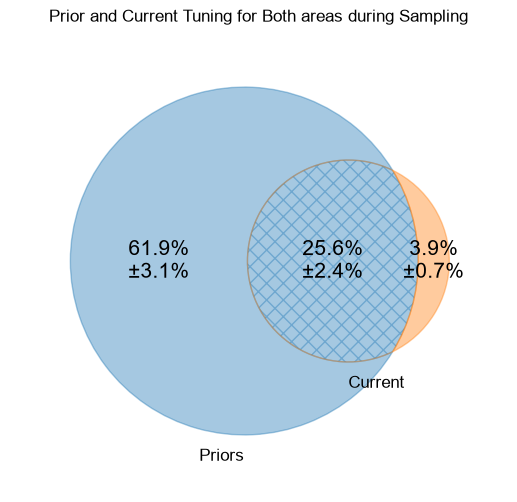

Brain Region: ALM, Priors Tuning: 51.9% ± 4.0%, Current Tuning: 5.9% ± 1.0%, Both Tuned: 32.2% ± 3.6%, No Tuning: 10.0% ± 1.7%
Sizes of combined priors:  84.02653719870462  current:  38.09871685256265  max_combined_ratio:  1.159734628012954


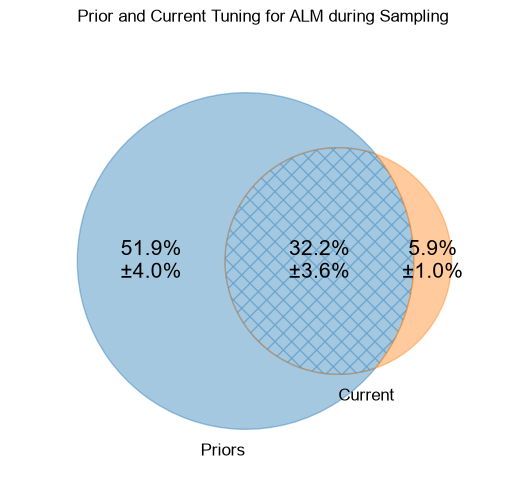

Brain Region: M2, Priors Tuning: 69.7% ± 3.1%, Current Tuning: 2.3% ± 0.7%, Both Tuned: 20.5% ± 2.6%, No Tuning: 7.4% ± 1.6%
Sizes of combined priors:  90.24538596408892  current:  22.86136556227803  max_combined_ratio:  1.097546140359111


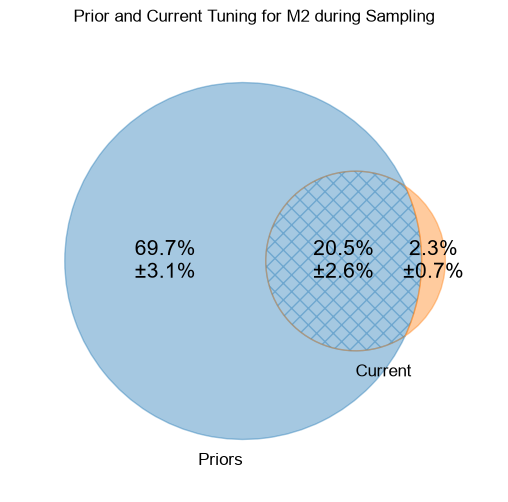

Brain Region: Both areas, Priors Tuning: 21.3% ± 2.2%, Current Tuning: 25.4% ± 1.9%, Both Tuned: 41.4% ± 2.4%, No Tuning: 11.9% ± 1.2%
Sizes of combined priors:  62.67570792243411  current:  66.78320875698053  max_combined_ratio:  1.3321679124301946


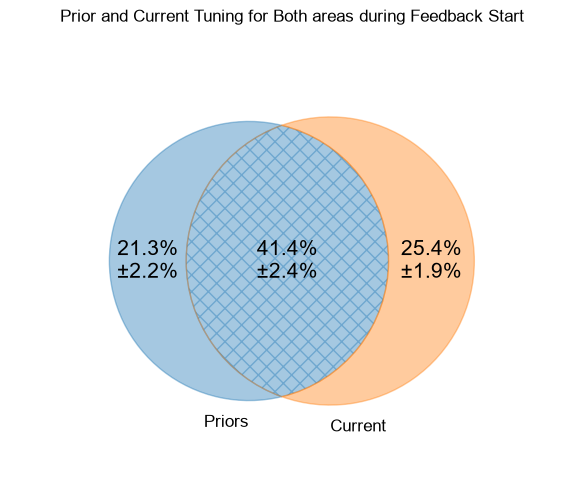

Brain Region: ALM, Priors Tuning: 22.3% ± 4.1%, Current Tuning: 25.3% ± 3.6%, Both Tuned: 38.2% ± 2.4%, No Tuning: 14.3% ± 1.3%
Sizes of combined priors:  60.44467442862203  current:  63.41858517401493  max_combined_ratio:  1.3658141482598507


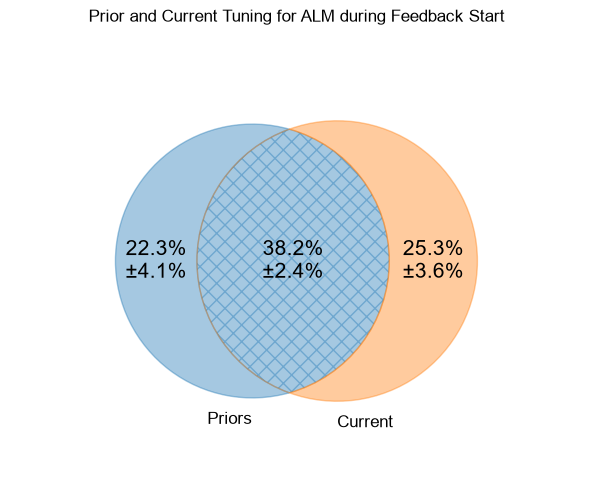

Brain Region: M2, Priors Tuning: 20.5% ± 2.4%, Current Tuning: 25.5% ± 2.2%, Both Tuned: 43.9% ± 3.8%, No Tuning: 10.1% ± 1.7%
Sizes of combined priors:  64.39188753305878  current:  69.37138074387714  max_combined_ratio:  1.3062861925612286


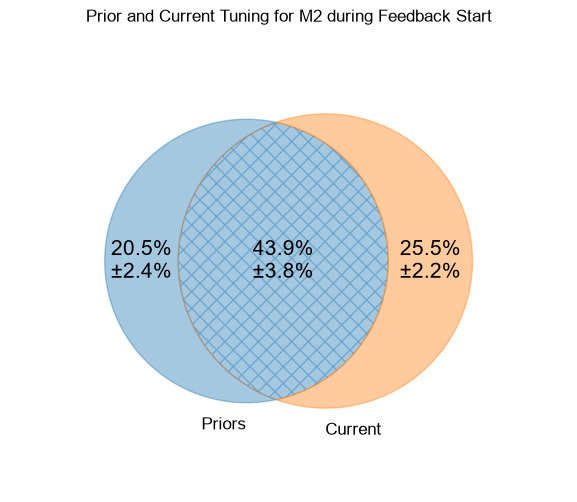

In [71]:
from .twop.priorcurtuning import plotPriorCurrentTuning

sampling_tuning = plotPriorCurrentTuning(sampling_pref_df, epoch_str="Sampling",
                                         save_figs=SAVE_FIGS, fig_save_prefix=fig_save_prefix)
feedback_tuning = plotPriorCurrentTuning(feedback_pref_df, epoch_str="Feedback Start",
                                         save_figs=SAVE_FIGS, fig_save_prefix=fig_save_prefix)